#Problem Overview

> Businesses or companies can fall prey to default if they are not able to keep up their debt obligations. Defaults will lead to a lower credit rating for the company which in turn reduces its chances of getting credit in the future and may have to pay higher interest on existing debts as well as any new obligations. From an investor's point of view, he would want to invest in a company if it is capable of handling its financial obligations, can grow quickly, and is able to manage the growth scale.

>A balance sheet is a financial statement of a company that provides a snapshot of what a company owns, owes, and the amount invested by the shareholders. Thus, it is an important tool that helps evaluate the performance of a business.

>Data that is available includes information from the financial statement of the companies for the previous year.

>Dependent variable - No need to create any new variable, as the 'Default' variable is already provided in the dataset, which can be considered as the dependent variable.

>Test Train Split- Split the data into train and test datasets in the ratio of 67:33 and use a random state of 42 (random_state=42). Model building is to be done on the train dataset and model validation is to be done on the test dataset.

In [1]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)
# setting the precision of floating numbers to 5 decimal points
pd.set_option("display.float_format", lambda x: "%.5f" % x)

# Library to split data
from sklearn.model_selection import train_test_split

# To build model for prediction
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from sklearn.ensemble import RandomForestClassifier

# To tune different models
from sklearn.model_selection import GridSearchCV


# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    make_scorer,
)



import warnings
warnings.filterwarnings("ignore")

from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter("ignore", ConvergenceWarning)

#Data Overview

In [2]:
# mounting google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data = pd.read_excel('/content/drive/MyDrive/Deakin University/Financial Risk Analytics/Project/CompData-1.xlsx')

In [4]:
data.head()

,Co_Code,Co_Name,_Operating_Expense_Rate,_Research_and_development_expense_rate,_Cash_flow_rate,_Interest_bearing_debt_interest_rate,_Tax_rate_A,_Cash_Flow_Per_Share,_Per_Share_Net_profit_before_tax_Yuan_,_Realized_Sales_Gross_Profit_Growth_Rate,_Operating_Profit_Growth_Rate,_Continuous_Net_Profit_Growth_Rate,_Total_Asset_Growth_Rate,_Net_Value_Growth_Rate,_Total_Asset_Return_Growth_Rate_Ratio,_Cash_Reinvestment_perc,_Current_Ratio,_Quick_Ratio,_Interest_Expense_Ratio,_Total_debt_to_Total_net_worth,_Long_term_fund_suitability_ratio_A,_Net_profit_before_tax_to_Paid_in_capital,_Total_Asset_Turnover,_Accounts_Receivable_Turnover,_Average_Collection_Days,_Inventory_Turnover_Rate_times,_Fixed_Assets_Turnover_Frequency,_Net_Worth_Turnover_Rate_times,_Operating_profit_per_person,_Allocation_rate_per_person,_Quick_Assets_to_Total_Assets,_Cash_to_Total_Assets,_Quick_Assets_to_Current_Liability,_Cash_to_Current_Liability,_Operating_Funds_to_Liability,_Inventory_to_Working_Capital,_Inventory_to_Current_Liability,_Long_term_Liability_to_Current_Assets,_Retained_Earnings_to_Total_Assets,_Total_income_to_Total_expense,_Total_expense_to_Assets,_Current_Asset_Turnover_Rate,_Quick_Asset_Turnover_Rate,_Cash_Turnover_Rate,_Fixed_Assets_to_Assets,_Cash_Flow_to_Total_Assets,_Cash_Flow_to_Liability,_CFO_to_Assets,_Cash_Flow_to_Equity,_Current_Liability_to_Current_Assets,_Liability_Assets_Flag,_Total_assets_to_GNP_price,_No_credit_Interval,_Degree_of_Financial_Leverage_DFL,_Interest_Coverage_Ratio_Interest_expense_to_EBIT,_Net_Income_Flag,_Equity_to_Liability,Default
0,16974,Hind.Cables,8820000000.00000,0.00000,0.46205,0.00035,0.00142,0.32256,0.19447,0.02207,0.84802,0.21759,7500000000.00000,0.00044,0.26390,0.36914,0.00832,0.00025,0.63151,0.02601,0.00577,0.19286,0.05397,0.01400,0.00045,707000000.00000,0.00030,0.02984,0.61169,0.13949,0.17644,0.02563,0.00151,0.00068,0.34239,0.27843,0.01794,0.00306,0.93763,0.00269,0.00706,0.00073,0.00014,5470000000.00000,0.09427,0.63267,0.45807,0.57687,0.31090,0.03491,0,0.02880,0.62093,0.02693,0.56574,1,0.01534,0
1,21214,Tata Tele. Mah.,9380000000.00000,4230000000.00000,0.46012,0.00072,0.00000,0.31552,0.16163,0.02190,0.83965,0.21736,6750000000.00000,0.00040,0.26371,0.37268,0.00694,0.00479,0.62806,0.00681,0.00523,0.16068,0.05697,0.00031,0.02064,0.00028,8850000000.00000,0.01839,0.38663,0.02280,0.40204,0.00453,0.00658,0.00022,0.33748,0.27722,0.00127,0.00481,0.92625,0.00204,0.01544,0.00030,0.00030,882000000.00000,0.35189,0.64297,0.45928,0.55152,0.31457,0.04165,0,0.00619,0.62251,0.02630,0.56074,1,0.02944,1
2,14852,ABG Shipyard,3800000000.00000,815000000.00000,0.44989,0.00050,0.00000,0.29985,0.17255,0.02219,0.84820,0.21757,9680000000.00000,0.00045,0.26409,0.34886,0.00867,0.00591,0.63169,0.00410,0.00514,0.17155,0.15442,0.00104,0.00605,0.00017,0.00015,0.02984,0.39326,0.01236,0.31892,0.00824,0.00609,0.00046,0.30699,0.27747,0.00701,0.00000,0.93315,0.00232,0.00977,0.00013,941000000.00000,679000000.00000,0.46328,0.64449,0.45970,0.46305,0.31478,0.03356,0,0.00109,0.62375,0.02728,0.56674,1,0.04172,0
3,2439,GTL,6440000000.00000,0.00000,0.46273,0.00059,0.00931,0.31983,0.17474,0.02764,0.84839,0.21766,7520000000.00000,0.00045,0.26477,0.37988,0.01775,0.00174,0.63259,0.00785,0.01196,0.17216,0.10195,0.00541,0.00117,1340000000.00000,0.00183,0.02839,0.43978,0.00905,0.13709,0.05351,0.00244,0.00279,0.34350,0.27763,0.03987,0.00447,0.92804,0.00233,0.01361,0.00040,5310000000.00000,6020000000.00000,0.02643,0.65683,0.46186,0.57721,0.31697,0.01653,0,0.00375,0.62296,0.02699,0.56595,1,0.02696,0
4,23505,Bharati Defence,3680000000.00000,0.00000,0.46312,0.00078,0.40024,0.32510,0.17655,0.02207,0.84799,0.21759,7120000000.00000,0.00045,0.26397,0.38961,0.00843,0.00397,0.63268,0.01367,0.00582,0.17560,0.16342,0.00081,0.00778,0.00013,0.00083,0.05226,0.39277,0.00207,0.73919,0.08233,0.00727,0.00238,0.34580,0.27724,0.00334,0.00000,0.93442,0.00231,0.01049,0.00021,0.00019,5670000000.00000,0.10330,0.65655,0.46124,0.59404,0.31773,0.03450,0,0.00659,0.62442,0.02750,0.5671

**Observatoins**

> The data was loaded properly.

In [5]:
# Making a copy of the data
df = data.copy()

In [6]:
# Function to perform the data overview: shape, info, describe, missing vakues, duplicates, head and tail

from IPython.display import display, HTML
def display_dataframe_info(data_display, df_name="Your Dataframe Name", title="Dataframe Information"):
    """
    Displays detailed information about a dataframe using IPython.display and formatting.

    Args:
        data_display: The Pandas DataFrame to analyze.
        title (optional): A title for the displayed information.
        df_name (optional): The name of the dataframe to display after the title.

    Returns:
        None
    """
    display(HTML(f"<h1 style='font-weight: bold'>{title} for {df_name}</h1>"))

    # Display shape, info and description

    display(HTML(f"<p style='font-weight: bold'>Shape:</p>"))
    display(data_display.shape)
    display(HTML(f"<p style='font-weight: bold'>Information:</p>"))
    display(data_display.info())
    display(HTML(f"<p style='font-weight: bold'>Description:</p>"))
    #pd.options.display.float_format = '{:.2f}'.format
    display(data_display.describe().T)

    # Display head and tail

    display(HTML(f"<p style='font-weight: bold'>Head (First 5 rows):</p>"))
    display(data_display.head())
    display(HTML(f"<p style='font-weight: bold'>Tail (Last 5 rows):</p>"))
    display(data_display.tail())

    # Display duplicates

    duplicate_count = data_display.duplicated().sum()
    display(HTML(f"<p style='font-weight: bold'>Duplicates:</p>"))
    display(f"Number of duplicate rows: {duplicate_count}")

    # Optionally show specific duplicates

    if duplicate_count > 0:
        display(HTML(f"<p style='font-weight: bold'>Duplicate Rows:</p>"))
        display(data_display[data_display.duplicated()])

    # Display missing values

    display(HTML(f"<p style='font-weight: bold'>Missing Values:</p>"))
    missing_values_df = data_display.isnull().sum().reset_index(name="Count")
    missing_values_df["Percentage"] = (
        missing_values_df["Count"] / data_display.shape[0]
    ) * 100
    top_missing_values = missing_values_df.nlargest(10, "Count").rename(
        columns={"index": "Column Name"}
    )
    display(top_missing_values)


In [7]:
display_dataframe_info(df,"", "Company Credit Risk Assessment")

(2058, 58)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2058 entries, 0 to 2057
Data columns (total 58 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Co_Code                                            2058 non-null   int64  
 1   Co_Name                                            2058 non-null   object 
 2   _Operating_Expense_Rate                            2058 non-null   float64
 3   _Research_and_development_expense_rate             2058 non-null   float64
 4   _Cash_flow_rate                                    2058 non-null   float64
 5   _Interest_bearing_debt_interest_rate               2058 non-null   float64
 6   _Tax_rate_A                                        2058 non-null   float64
 7   _Cash_Flow_Per_Share                               1891 non-null   float64
 8   _Per_Share_Net_profit_before_tax_Yuan_             2058 non-null   float64
 9   _Realize

None

,count,mean,std,min,25%,50%,75%,max
Co_Code,2058.00000,17572.11322,21892.88652,4.00000,3674.00000,6240.00000,24280.75000,72493.00000
_Operating_Expense_Rate,2058.00000,2052388835.76336,3252623690.28941,0.00010,0.00016,0.00033,4110000000.00000,9980000000.00000
_Research_and_development_expense_rate,2058.00000,1208634256.55984,2144568158.08090,0.00000,0.00000,0.00020,1550000000.00000,9980000000.00000
_Cash_flow_rate,2058.00000,0.46524,0.02266,0.00000,0.46010,0.46344,0.46807,1.00000
_Interest_bearing_debt_interest_rate,2058.00000,11130223.51910,90425949.04449,0.00000,0.00028,0.00045,0.00066,990000000.00000
_Tax_rate_A,2058.00000,0.11478,0.15245,0.00000,0.00000,0.03710,0.21619,0.99970
_Cash_Flow_Per_Share,1891.00000,0.31999,0.01530,0.16945,0.31499,0.32065,0.32592,0.46223
_Per_Share_Net_profit_before_tax_Yuan_,2058.00000,0.17697,0.03016,0.00000,0.16660,0.17564,0.18589,0.79235
_Realized_Sales_Gross_Profit_Growth_Rate,2058.00000,0.02276,0.02170,0.00428,0.02206,0.02210,0.02215,1.00000
_Operating_Profit_Growth_Rate,2058.00000,0.84811,0.00459,0.73643,0.84797,0.84804,0.84811,1.00000


,Co_Code,Co_Name,_Operating_Expense_Rate,_Research_and_development_expense_rate,_Cash_flow_rate,_Interest_bearing_debt_interest_rate,_Tax_rate_A,_Cash_Flow_Per_Share,_Per_Share_Net_profit_before_tax_Yuan_,_Realized_Sales_Gross_Profit_Growth_Rate,_Operating_Profit_Growth_Rate,_Continuous_Net_Profit_Growth_Rate,_Total_Asset_Growth_Rate,_Net_Value_Growth_Rate,_Total_Asset_Return_Growth_Rate_Ratio,_Cash_Reinvestment_perc,_Current_Ratio,_Quick_Ratio,_Interest_Expense_Ratio,_Total_debt_to_Total_net_worth,_Long_term_fund_suitability_ratio_A,_Net_profit_before_tax_to_Paid_in_capital,_Total_Asset_Turnover,_Accounts_Receivable_Turnover,_Average_Collection_Days,_Inventory_Turnover_Rate_times,_Fixed_Assets_Turnover_Frequency,_Net_Worth_Turnover_Rate_times,_Operating_profit_per_person,_Allocation_rate_per_person,_Quick_Assets_to_Total_Assets,_Cash_to_Total_Assets,_Quick_Assets_to_Current_Liability,_Cash_to_Current_Liability,_Operating_Funds_to_Liability,_Inventory_to_Working_Capital,_Inventory_to_Current_Liability,_Long_term_Liability_to_Current_Assets,_Retained_Earnings_to_Total_Assets,_Total_income_to_Total_expense,_Total_expense_to_Assets,_Current_Asset_Turnover_Rate,_Quick_Asset_Turnover_Rate,_Cash_Turnover_Rate,_Fixed_Assets_to_Assets,_Cash_Flow_to_Total_Assets,_Cash_Flow_to_Liability,_CFO_to_Assets,_Cash_Flow_to_Equity,_Current_Liability_to_Current_Assets,_Liability_Assets_Flag,_Total_assets_to_GNP_price,_No_credit_Interval,_Degree_of_Financial_Leverage_DFL,_Interest_Coverage_Ratio_Interest_expense_to_EBIT,_Net_Income_Flag,_Equity_to_Liability,Default
0,16974,Hind.Cables,8820000000.00000,0.00000,0.46205,0.00035,0.00142,0.32256,0.19447,0.02207,0.84802,0.21759,7500000000.00000,0.00044,0.26390,0.36914,0.00832,0.00025,0.63151,0.02601,0.00577,0.19286,0.05397,0.01400,0.00045,707000000.00000,0.00030,0.02984,0.61169,0.13949,0.17644,0.02563,0.00151,0.00068,0.34239,0.27843,0.01794,0.00306,0.93763,0.00269,0.00706,0.00073,0.00014,5470000000.00000,0.09427,0.63267,0.45807,0.57687,0.31090,0.03491,0,0.02880,0.62093,0.02693,0.56574,1,0.01534,0
1,21214,Tata Tele. Mah.,9380000000.00000,4230000000.00000,0.46012,0.00072,0.00000,0.31552,0.16163,0.02190,0.83965,0.21736,6750000000.00000,0.00040,0.26371,0.37268,0.00694,0.00479,0.62806,0.00681,0.00523,0.16068,0.05697,0.00031,0.02064,0.00028,8850000000.00000,0.01839,0.38663,0.02280,0.40204,0.00453,0.00658,0.00022,0.33748,0.27722,0.00127,0.00481,0.92625,0.00204,0.01544,0.00030,0.00030,882000000.00000,0.35189,0.64297,0.45928,0.55152,0.31457,0.04165,0,0.00619,0.62251,0.02630,0.56074,1,0.02944,1
2,14852,ABG Shipyard,3800000000.00000,815000000.00000,0.44989,0.00050,0.00000,0.29985,0.17255,0.02219,0.84820,0.21757,9680000000.00000,0.00045,0.26409,0.34886,0.00867,0.00591,0.63169,0.00410,0.00514,0.17155,0.15442,0.00104,0.00605,0.00017,0.00015,0.02984,0.39326,0.01236,0.31892,0.00824,0.00609,0.00046,0.30699,0.27747,0.00701,0.00000,0.93315,0.00232,0.00977,0.00013,941000000.00000,679000000.00000,0.46328,0.64449,0.45970,0.46305,0.31478,0.03356,0,0.00109,0.62375,0.02728,0.56674,1,0.04172,0
3,2439,GTL,6440000000.00000,0.00000,0.46273,0.00059,0.00931,0.31983,0.17474,0.02764,0.84839,0.21766,7520000000.00000,0.00045,0.26477,0.37988,0.01775,0.00174,0.63259,0.00785,0.01196,0.17216,0.10195,0.00541,0.00117,1340000000.00000,0.00183,0.02839,0.43978,0.00905,0.13709,0.05351,0.00244,0.00279,0.34350,0.27763,0.03987,0.00447,0.92804,0.00233,0.01361,0.00040,5310000000.00000,6020000000.00000,0.02643,0.65683,0.46186,0.57721,0.31697,0.01653,0,0.00375,0.62296,0.02699,0.56595,1,0.02696,0
4,23505,Bharati Defence,3680000000.00000,0.00000,0.46312,0.00078,0.40024,0.32510,0.17655,0.02207,0.84799,0.21759,7120000000.00000,0.00045,0.26397,0.38961,0.00843,0.00397,0.63268,0.01367,0.00582,0.17560,0.16342,0.00081,0.00778,0.00013,0.00083,0.05226,0.39277,0.00207,0.73919,0.08233,0.00727,0.00238,0.34580,0.27724,0.00334,0.00000,0.93442,0.00231,0.01049,0.00021,0.00019,5670000000.00000,0.10330,0.65655,0.46124,0.59404,0.31773,0.03450,0,0.00659,0.62442,0.02750,0.5671

,Co_Code,Co_Name,_Operating_Expense_Rate,_Research_and_development_expense_rate,_Cash_flow_rate,_Interest_bearing_debt_interest_rate,_Tax_rate_A,_Cash_Flow_Per_Share,_Per_Share_Net_profit_before_tax_Yuan_,_Realized_Sales_Gross_Profit_Growth_Rate,_Operating_Profit_Growth_Rate,_Continuous_Net_Profit_Growth_Rate,_Total_Asset_Growth_Rate,_Net_Value_Growth_Rate,_Total_Asset_Return_Growth_Rate_Ratio,_Cash_Reinvestment_perc,_Current_Ratio,_Quick_Ratio,_Interest_Expense_Ratio,_Total_debt_to_Total_net_worth,_Long_term_fund_suitability_ratio_A,_Net_profit_before_tax_to_Paid_in_capital,_Total_Asset_Turnover,_Accounts_Receivable_Turnover,_Average_Collection_Days,_Inventory_Turnover_Rate_times,_Fixed_Assets_Turnover_Frequency,_Net_Worth_Turnover_Rate_times,_Operating_profit_per_person,_Allocation_rate_per_person,_Quick_Assets_to_Total_Assets,_Cash_to_Total_Assets,_Quick_Assets_to_Current_Liability,_Cash_to_Current_Liability,_Operating_Funds_to_Liability,_Inventory_to_Working_Capital,_Inventory_to_Current_Liability,_Long_term_Liability_to_Current_Assets,_Retained_Earnings_to_Total_Assets,_Total_income_to_Total_expense,_Total_expense_to_Assets,_Current_Asset_Turnover_Rate,_Quick_Asset_Turnover_Rate,_Cash_Turnover_Rate,_Fixed_Assets_to_Assets,_Cash_Flow_to_Total_Assets,_Cash_Flow_to_Liability,_CFO_to_Assets,_Cash_Flow_to_Equity,_Current_Liability_to_Current_Assets,_Liability_Assets_Flag,_Total_assets_to_GNP_price,_No_credit_Interval,_Degree_of_Financial_Leverage_DFL,_Interest_Coverage_Ratio_Interest_expense_to_EBIT,_Net_Income_Flag,_Equity_to_Liability,Default
2053,2743,Kothari Ferment.,0.00030,6490000000.00000,0.47707,0.00000,0.18301,0.32206,0.19274,0.02213,0.84802,0.21759,7200000000.00000,0.00047,0.26446,0.37751,0.06389,0.05727,0.63061,0.00069,0.00609,0.19181,0.07946,0.00081,0.00784,8040000000.00000,0.00020,0.01823,0.39790,0.00884,0.75127,0.38092,0.05819,0.08490,0.38434,0.27703,0.01504,0.00000,0.95892,0.00252,0.02607,0.00042,0.00041,0.00054,0.19152,0.70070,0.51960,0.59905,0.32039,0.00443,0,0.00042,0.62457,0.02679,0.56516,1,0.17166,0
2054,21216,Firstobj.Tech.,0.00014,0.00000,0.46521,0.00066,0.00000,0.31976,0.16939,0.02207,0.84800,0.21764,6120000000.00000,0.00044,0.26376,0.38015,0.00902,0.00775,0.63503,0.00293,0.00507,0.16840,0.08696,0.00075,0.00842,0.00039,6810000000.00000,0.02145,0.39305,0.01926,0.23921,0.01914,0.00808,0.00185,0.34874,0.27715,0.00278,0.00896,0.92968,0.00223,0.02015,0.00011,0.00011,2340000000.00000,0.67385,0.62477,0.45301,0.58391,0.31232,0.03228,0,0.00088,0.62401,0.02420,0.57367,1,0.05374,0
2055,142,Diamines & Chem.,0.00021,8370000000.00000,0.48025,0.00050,0.00000,0.32783,0.15500,0.02186,0.84782,0.21752,5360000000.00000,0.00041,0.26248,0.38746,0.00705,0.00583,0.63030,0.00285,0.00517,0.15399,0.02399,0.00034,0.01877,0.00031,2190000000.00000,0.01226,0.37605,0.03631,0.17469,0.01991,0.00694,0.00225,0.37559,0.27709,0.00065,0.01632,0.91931,0.00187,0.01772,0.00027,0.00028,8240000000.00000,0.53541,0.63115,0.45513,0.64638,0.31312,0.04100,0,0.00958,0.62372,0.02670,0.56470,1,0.05498,0
2056,18014,IL&FS Engg.,3750000000.00000,0.00000,0.47467,0.00058,0.30621,0.32203,0.17383,0.02217,0.84811,0.21759,5730000000.00000,0.00042,0.26371,0.38237,0.01446,0.00862,0.63122,0.00269,0.00516,0.17282,0.09295,0.00105,0.00603,896000000.00000,0.00010,0.02177,0.40451,0.03994,0.18586,0.03625,0.00862,0.00478,0.36268,0.27733,0.01543,0.00113,0.93456,0.00239,0.00972,0.00012,7380000000.00000,4050000000.00000,0.49876,0.65174,0.46251,0.61402,0.31563,0.02028,0,0.00496,0.62344,0.02694,0.56579,1,0.05755,0
2057,43229,Channel Nine,0.00030,0.00000,0.46720,0.00083,0.00000,0.33002,0.18024,0.02242,0.84818,0.21765,8720000000.00000,0.00062,0.26861,0.41891,0.00929,0.00304,0.63073,0.01317,0.00841,0.17925,0.16342,0.00121,0.00522,2920000000.00000,0.00203,0.05742,0.39528,0.00071,0.37289,0.02851,0.00364,0.00083,0.35812,0.27784,0.01494,0.00000,0.91266,0.00241,0.05006,0.00025,9960000000.00000,2120000000.00000,0.03165,0.65247,0.46067,0.66308,0.31673,0.03137,0,0.00019,0.62359,0.02687,0.5

'Number of duplicate rows: 0'

,Column Name,Count,Percentage
7,_Cash_Flow_Per_Share,167,8.11467
31,_Cash_to_Total_Assets,96,4.66472
19,_Total_debt_to_Total_net_worth,21,1.02041
49,_Current_Liability_to_Current_Assets,14,0.68027
0,Co_Code,0,0.00000
1,Co_Name,0,0.00000
2,_Operating_Expense_Rate,0,0.00000
3,_Research_and_development_expense_rate,0,0.00000
4,_Cash_flow_rate,0,0.00000
5,_Interest_bearing_debt_interest_rate,0,0.00000


**Observations**

1.  There are 2058 rows and 58 columns.
2.  There are missing values.
3.  There are no duplicated rows.
4.  From data info we see:
  >1.  There are missing values in: _Cash_Flow_Per_Share, _Total_debt_to_Total_net_worth, _Cash_to_Total_Assets, _Current_Liability_to_Current_Assets.
  2.  There are 53 float, 4 int64 and 1 object.
  3.  There are no null values.
5.  From the data description we see:
  >1.  There are many variables where the min value is very small and the 75% quartile and max are very very large. We find that in some cases the mean and std. dev. are also very large.
  2.  We may nee to scale the data and treat outliers.
6. The Default is currently an int, we will explore this variable more.
7.  _Liability_Assets_Flag  is an int, we will explore this more later on.
8.  _Net_Income_Flag is an int, we will explore this more later on.


In [8]:
# we can drop Co_Code and Co_Name as it is not needed in the analysis as they have unique values

df = df.drop(['Co_Code', 'Co_Name'], axis=1)

In [9]:
# Examining the default variable more

df["Default"].value_counts()

,count
Default,
0,1838
1,220


In [10]:
# Looking at the proportions of the default
df["Default"].value_counts(normalize=True)

,proportion
Default,
0,0.89310
1,0.10690


**Observations**

> 1. 220 of the 1838 companies defaulted.   
2.  That is 10.069% of the companies defaulted

In [11]:
# Examining _Liability_Assets_Flag
df["_Liability_Assets_Flag"].value_counts()

,count
_Liability_Assets_Flag,
0,2051
1,7


**Observations**

There are 7 companies where the total liabilities exceeds total assets

In [12]:
# Examining _Net_Income_Flag

df["_Net_Income_Flag"].value_counts()

,count
_Net_Income_Flag,
1,2058


**Observations**

> All companies have negative Net Income for the last two years.
As this variable only have 1's we can drop it.

In [13]:
# Dropping _Net_Income_Flag
df= df.drop('_Net_Income_Flag', axis=1)

# Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

### Outliers

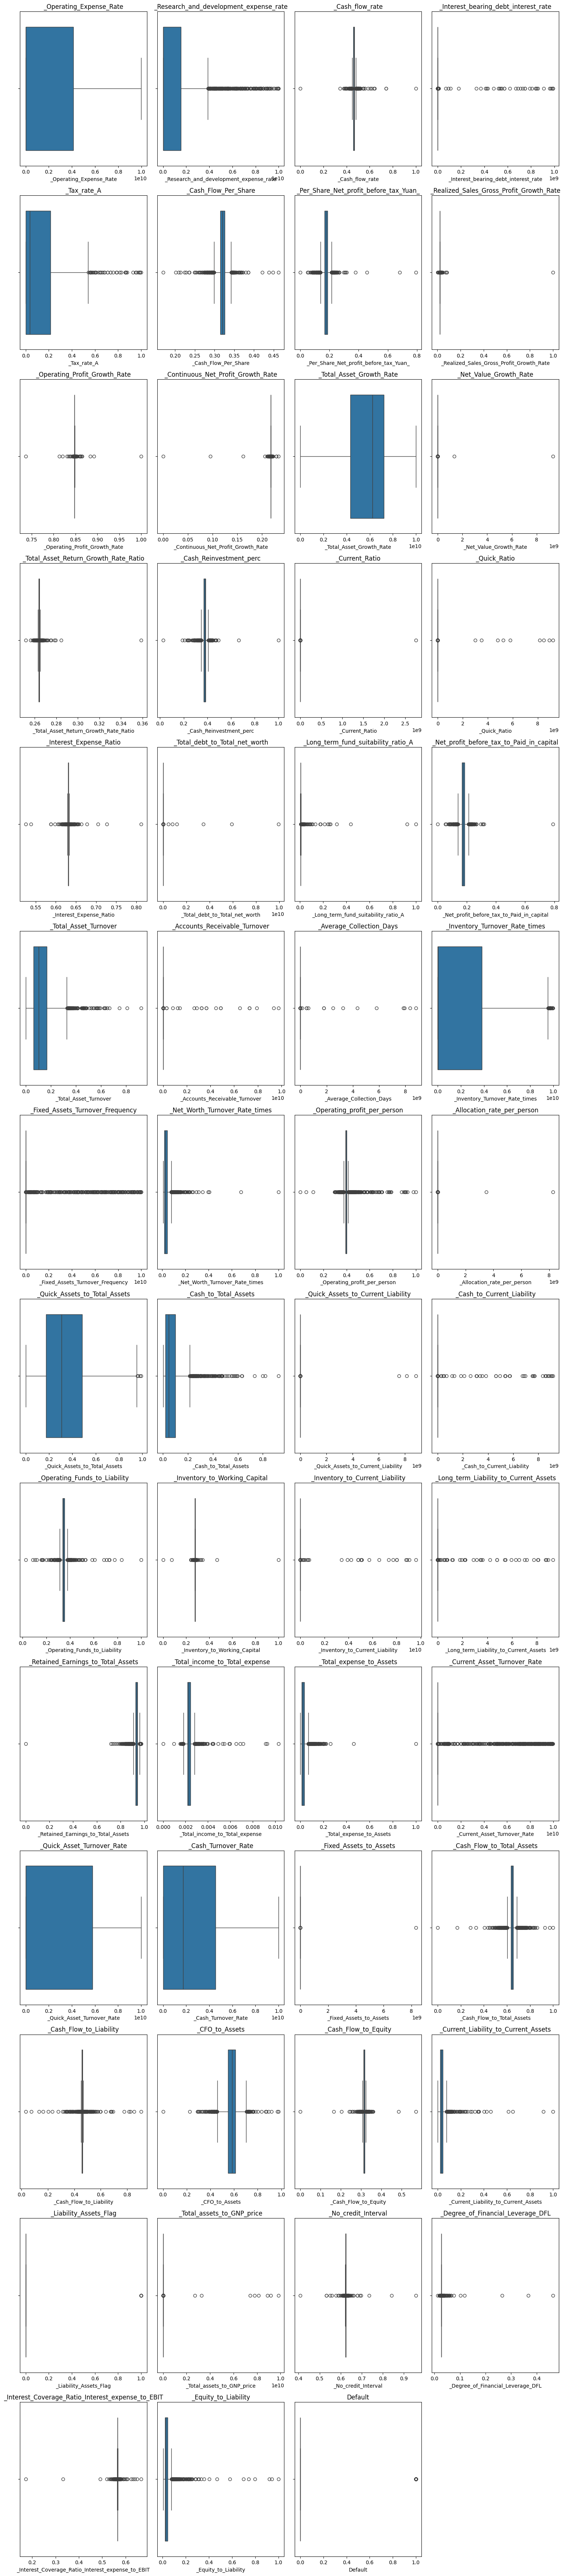

In [14]:
# outlier detection using boxplot
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

# Calculate the number of rows and columns needed for subplots
n_cols = 4
n_rows = (len(numeric_columns) + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 5))

for i, variable in enumerate(numeric_columns):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(data=df, x=variable, whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

> The majority of the variables have outliers.

---

> When performing the outlier treatment we do this on the predictor variables only, not the y variable (dependent).


In [15]:
# splitting X and Y

df_X = df.drop('Default', axis = 1)
df_Y = df['Default']

In [16]:
df_X

,_Operating_Expense_Rate,_Research_and_development_expense_rate,_Cash_flow_rate,_Interest_bearing_debt_interest_rate,_Tax_rate_A,_Cash_Flow_Per_Share,_Per_Share_Net_profit_before_tax_Yuan_,_Realized_Sales_Gross_Profit_Growth_Rate,_Operating_Profit_Growth_Rate,_Continuous_Net_Profit_Growth_Rate,_Total_Asset_Growth_Rate,_Net_Value_Growth_Rate,_Total_Asset_Return_Growth_Rate_Ratio,_Cash_Reinvestment_perc,_Current_Ratio,_Quick_Ratio,_Interest_Expense_Ratio,_Total_debt_to_Total_net_worth,_Long_term_fund_suitability_ratio_A,_Net_profit_before_tax_to_Paid_in_capital,_Total_Asset_Turnover,_Accounts_Receivable_Turnover,_Average_Collection_Days,_Inventory_Turnover_Rate_times,_Fixed_Assets_Turnover_Frequency,_Net_Worth_Turnover_Rate_times,_Operating_profit_per_person,_Allocation_rate_per_person,_Quick_Assets_to_Total_Assets,_Cash_to_Total_Assets,_Quick_Assets_to_Current_Liability,_Cash_to_Current_Liability,_Operating_Funds_to_Liability,_Inventory_to_Working_Capital,_Inventory_to_Current_Liability,_Long_term_Liability_to_Current_Assets,_Retained_Earnings_to_Total_Assets,_Total_income_to_Total_expense,_Total_expense_to_Assets,_Current_Asset_Turnover_Rate,_Quick_Asset_Turnover_Rate,_Cash_Turnover_Rate,_Fixed_Assets_to_Assets,_Cash_Flow_to_Total_Assets,_Cash_Flow_to_Liability,_CFO_to_Assets,_Cash_Flow_to_Equity,_Current_Liability_to_Current_Assets,_Liability_Assets_Flag,_Total_assets_to_GNP_price,_No_credit_Interval,_Degree_of_Financial_Leverage_DFL,_Interest_Coverage_Ratio_Interest_expense_to_EBIT,_Equity_to_Liability
0,8820000000.00000,0.00000,0.46205,0.00035,0.00142,0.32256,0.19447,0.02207,0.84802,0.21759,7500000000.00000,0.00044,0.26390,0.36914,0.00832,0.00025,0.63151,0.02601,0.00577,0.19286,0.05397,0.01400,0.00045,707000000.00000,0.00030,0.02984,0.61169,0.13949,0.17644,0.02563,0.00151,0.00068,0.34239,0.27843,0.01794,0.00306,0.93763,0.00269,0.00706,0.00073,0.00014,5470000000.00000,0.09427,0.63267,0.45807,0.57687,0.31090,0.03491,0,0.02880,0.62093,0.02693,0.56574,0.01534
1,9380000000.00000,4230000000.00000,0.46012,0.00072,0.00000,0.31552,0.16163,0.02190,0.83965,0.21736,6750000000.00000,0.00040,0.26371,0.37268,0.00694,0.00479,0.62806,0.00681,0.00523,0.16068,0.05697,0.00031,0.02064,0.00028,8850000000.00000,0.01839,0.38663,0.02280,0.40204,0.00453,0.00658,0.00022,0.33748,0.27722,0.00127,0.00481,0.92625,0.00204,0.01544,0.00030,0.00030,882000000.00000,0.35189,0.64297,0.45928,0.55152,0.31457,0.04165,0,0.00619,0.62251,0.02630,0.56074,0.02944
2,3800000000.00000,815000000.00000,0.44989,0.00050,0.00000,0.29985,0.17255,0.02219,0.84820,0.21757,9680000000.00000,0.00045,0.26409,0.34886,0.00867,0.00591,0.63169,0.00410,0.00514,0.17155,0.15442,0.00104,0.00605,0.00017,0.00015,0.02984,0.39326,0.01236,0.31892,0.00824,0.00609,0.00046,0.30699,0.27747,0.00701,0.00000,0.93315,0.00232,0.00977,0.00013,941000000.00000,679000000.00000,0.46328,0.64449,0.45970,0.46305,0.31478,0.03356,0,0.00109,0.62375,0.02728,0.56674,0.04172
3,6440000000.00000,0.00000,0.46273,0.00059,0.00931,0.31983,0.17474,0.02764,0.84839,0.21766,7520000000.00000,0.00045,0.26477,0.37988,0.01775,0.00174,0.63259,0.00785,0.01196,0.17216,0.10195,0.00541,0.00117,1340000000.00000,0.00183,0.02839,0.43978,0.00905,0.13709,0.05351,0.00244,0.00279,0.34350,0.27763,0.03987,0.00447,0.92804,0.00233,0.01361,0.00040,5310000000.00000,6020000000.00000,0.02643,0.65683,0.46186,0.57721,0.31697,0.01653,0,0.00375,0.62296,0.02699,0.56595,0.02696
4,3680000000.00000,0.00000,0.46312,0.00078,0.40024,0.32510,0.17655,0.02207,0.84799,0.21759,7120000000.00000,0.00045,0.26397,0.38961,0.00843,0.00397,0.63268,0.01367,0.00582,0.17560,0.16342,0.00081,0.00778,0.00013,0.00083,0.05226,0.39277,0.00207,0.73919,0.08233,0.00727,0.00238,0.34580,0.27724,0.00334,0.00000,0.93442,0.00231,0.01049,0.00021,0.00019,5670000000.00000,0.10330,0.65655,0.46124,0.59404,0.31773,0.03450,0,0.00659,0.62442,0.02750,0.56718,0.01990
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [17]:
df_Y

,Default
0,0
1,1
2,0
3,0
4,0
...,...
2053,0
2054,0
2055,0
2056,0


In [18]:
def remove_outlier(col):
    sorted(col)
    Q1,Q3=np.percentile(col,[25,75])
    IQR=Q3-Q1
    lower_range= Q1-(1.5 * IQR)
    upper_range= Q3+(1.5 * IQR)
    return lower_range, upper_range

In [19]:
# Capping to the upper and lower limits
for column in df_X.columns:
    lr,ur=remove_outlier(df[column])
    df_X[column]=np.where(df_X[column]>ur,ur,df_X[column])
    df_X[column]=np.where(df_X[column]<lr,lr,df_X[column])

#### Missing Values detection and treatment

In [20]:
# Checking for missing values
df_X.isnull().sum()

,0
_Operating_Expense_Rate,0
_Research_and_development_expense_rate,0
_Cash_flow_rate,0
_Interest_bearing_debt_interest_rate,0
_Tax_rate_A,0
_Cash_Flow_Per_Share,167
_Per_Share_Net_profit_before_tax_Yuan_,0
_Realized_Sales_Gross_Profit_Growth_Rate,0
_Operating_Profit_Growth_Rate,0
_Continuous_Net_Profit_Growth_Rate,0


> There are 4 variables with missing variables in the X variables.  As we do not have any information on the dataset, we will use KNN Imputer to impute the missing values.

In [21]:
df_Y.isnull().sum()

np.int64(0)

>  The are no missing vaues in the Y variable.

We will impute missing values using the KNN Imputer as we do not have more information on the dataset to fill in the missing values.

In [22]:
from sklearn.impute import KNNImputer

In [23]:
imputer = KNNImputer(n_neighbors=10)

In [24]:
df_imputed = pd.DataFrame(imputer.fit_transform(df_X), columns = df_X.columns)

In [25]:
df_imputed.isnull().sum()

,0
_Operating_Expense_Rate,0
_Research_and_development_expense_rate,0
_Cash_flow_rate,0
_Interest_bearing_debt_interest_rate,0
_Tax_rate_A,0
_Cash_Flow_Per_Share,0
_Per_Share_Net_profit_before_tax_Yuan_,0
_Realized_Sales_Gross_Profit_Growth_Rate,0
_Operating_Profit_Growth_Rate,0
_Continuous_Net_Profit_Growth_Rate,0


In [26]:
df_imputed['_Liability_Assets_Flag'].value_counts()

,count
_Liability_Assets_Flag,
0.00000,2058


>  We will now scale the data before we start building the models.

In [27]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_predictors = pd.DataFrame(scaler.fit_transform(df_imputed), columns = df_imputed.columns)

In [28]:
# combining the transformed X variable to the Y variable

df_scaled = pd.concat([scaled_predictors, df_Y], axis = 1)

In [29]:
df_scaled.isnull().sum()

,0
_Operating_Expense_Rate,0
_Research_and_development_expense_rate,0
_Cash_flow_rate,0
_Interest_bearing_debt_interest_rate,0
_Tax_rate_A,0
_Cash_Flow_Per_Share,0
_Per_Share_Net_profit_before_tax_Yuan_,0
_Realized_Sales_Gross_Profit_Growth_Rate,0
_Operating_Profit_Growth_Rate,0
_Continuous_Net_Profit_Growth_Rate,0


In [30]:
df_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2058 entries, 0 to 2057
Data columns (total 55 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   _Operating_Expense_Rate                            2058 non-null   float64
 1   _Research_and_development_expense_rate             2058 non-null   float64
 2   _Cash_flow_rate                                    2058 non-null   float64
 3   _Interest_bearing_debt_interest_rate               2058 non-null   float64
 4   _Tax_rate_A                                        2058 non-null   float64
 5   _Cash_Flow_Per_Share                               2058 non-null   float64
 6   _Per_Share_Net_profit_before_tax_Yuan_             2058 non-null   float64
 7   _Realized_Sales_Gross_Profit_Growth_Rate           2058 non-null   float64
 8   _Operating_Profit_Growth_Rate                      2058 non-null   float64
 9   _Continu

In [31]:
df_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
_Operating_Expense_Rate,2058.00000,0.00000,1.00024,-0.63115,-0.63115,-0.63115,0.63275,2.43789
_Research_and_development_expense_rate,2058.00000,0.00000,1.00024,-0.64515,-0.64515,-0.64515,0.42789,2.03744
_Cash_flow_rate,2058.00000,0.00000,1.00024,-2.18251,-0.57889,-0.13008,0.49019,2.09381
_Interest_bearing_debt_interest_rate,2058.00000,0.00000,1.00024,-1.63427,-0.70265,-0.10183,0.60363,2.56306
_Tax_rate_A,2058.00000,-0.00000,1.00024,-0.81922,-0.81922,-0.54416,0.78369,3.18804
_Cash_Flow_Per_Share,2058.00000,0.00000,1.00024,-10.22378,-0.31306,0.04476,0.37556,9.65530
_Per_Share_Net_profit_before_tax_Yuan_,2058.00000,0.00000,1.00024,-2.14621,-0.54266,-0.04155,0.52637,2.12992
_Realized_Sales_Gross_Profit_Growth_Rate,2058.00000,-0.00000,1.00024,-2.05492,-0.55022,-0.10375,0.45291,1.95761
_Operating_Profit_Growth_Rate,2058.00000,-0.00000,1.00024,-1.98228,-0.50445,-0.05196,0.48078,1.95861
_Continuous_Net_Profit_Growth_Rate,2058.00000,0.00000,1.00024,-1.91335,-0.45424,0.01363,0.51850,1.97761


>  Now we have fixed missing values, outliers and scaled the data.
We can now proceed to the EDA and building the logistic regression model

#EDA

In [32]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [33]:
# function to plot a stacked barplot

def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [34]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [35]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

## Univariate Analysis



### Plotting numeric columns

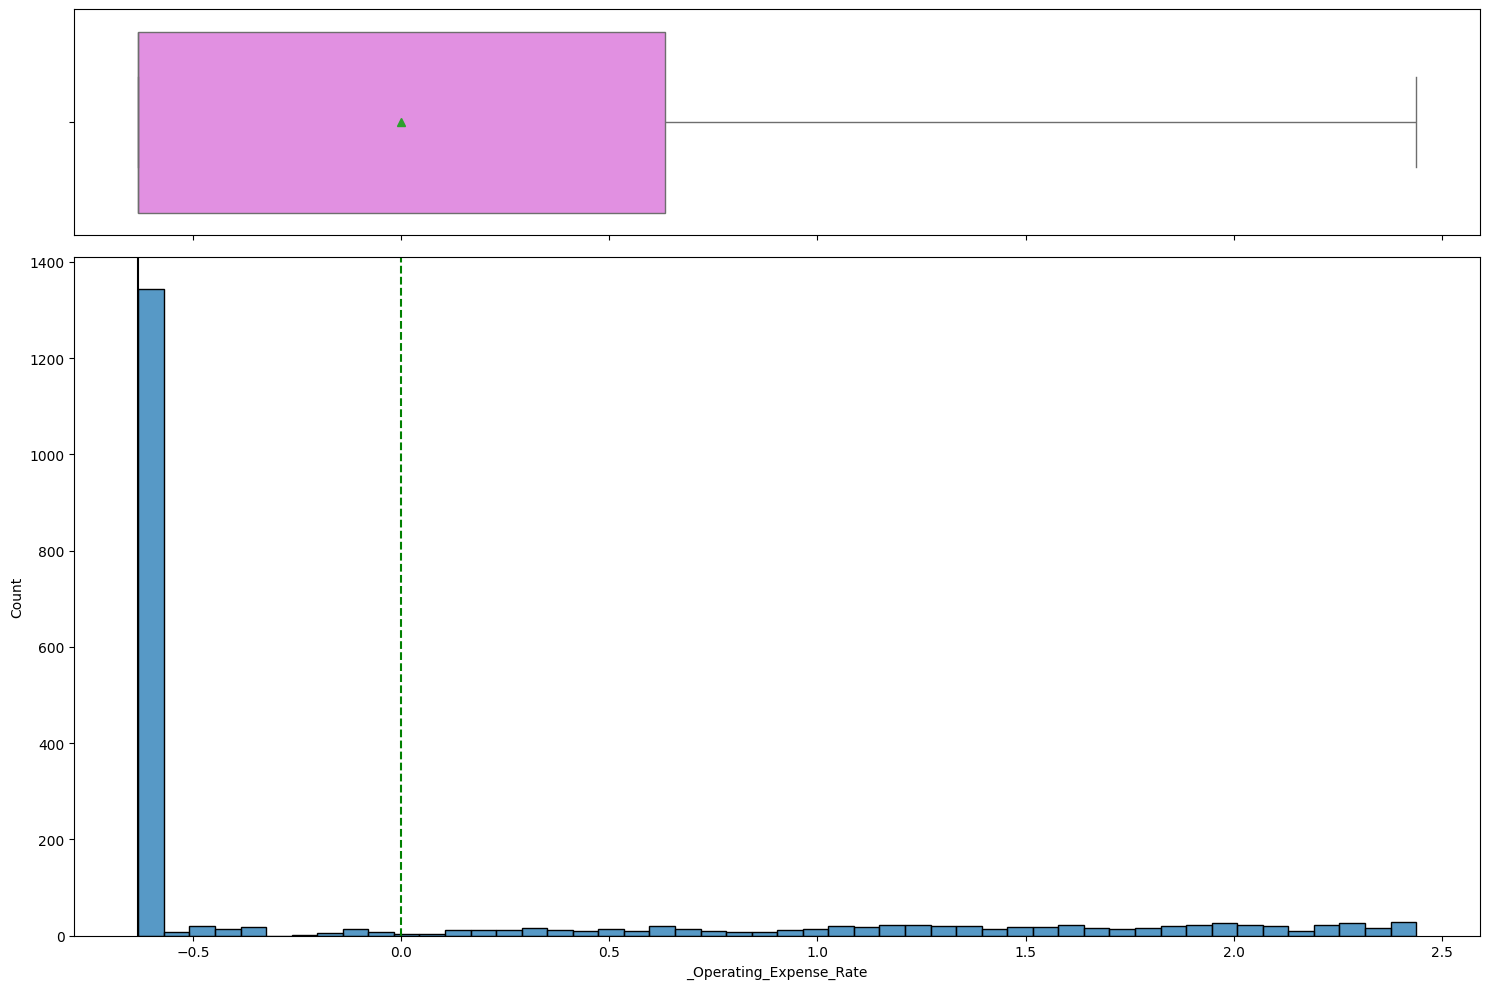

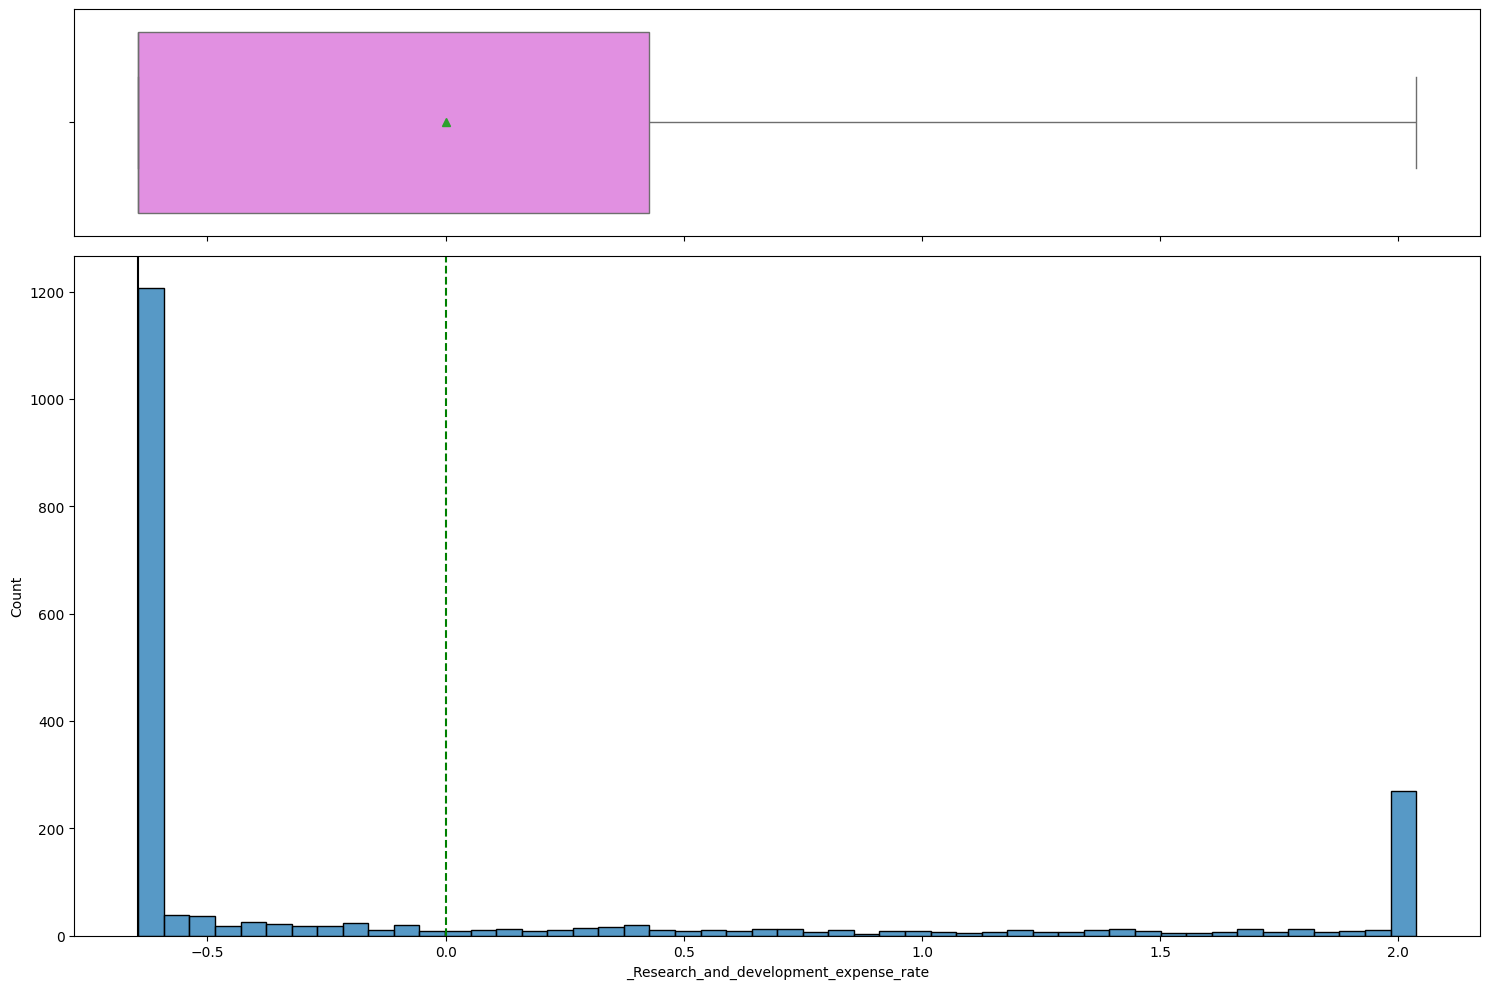

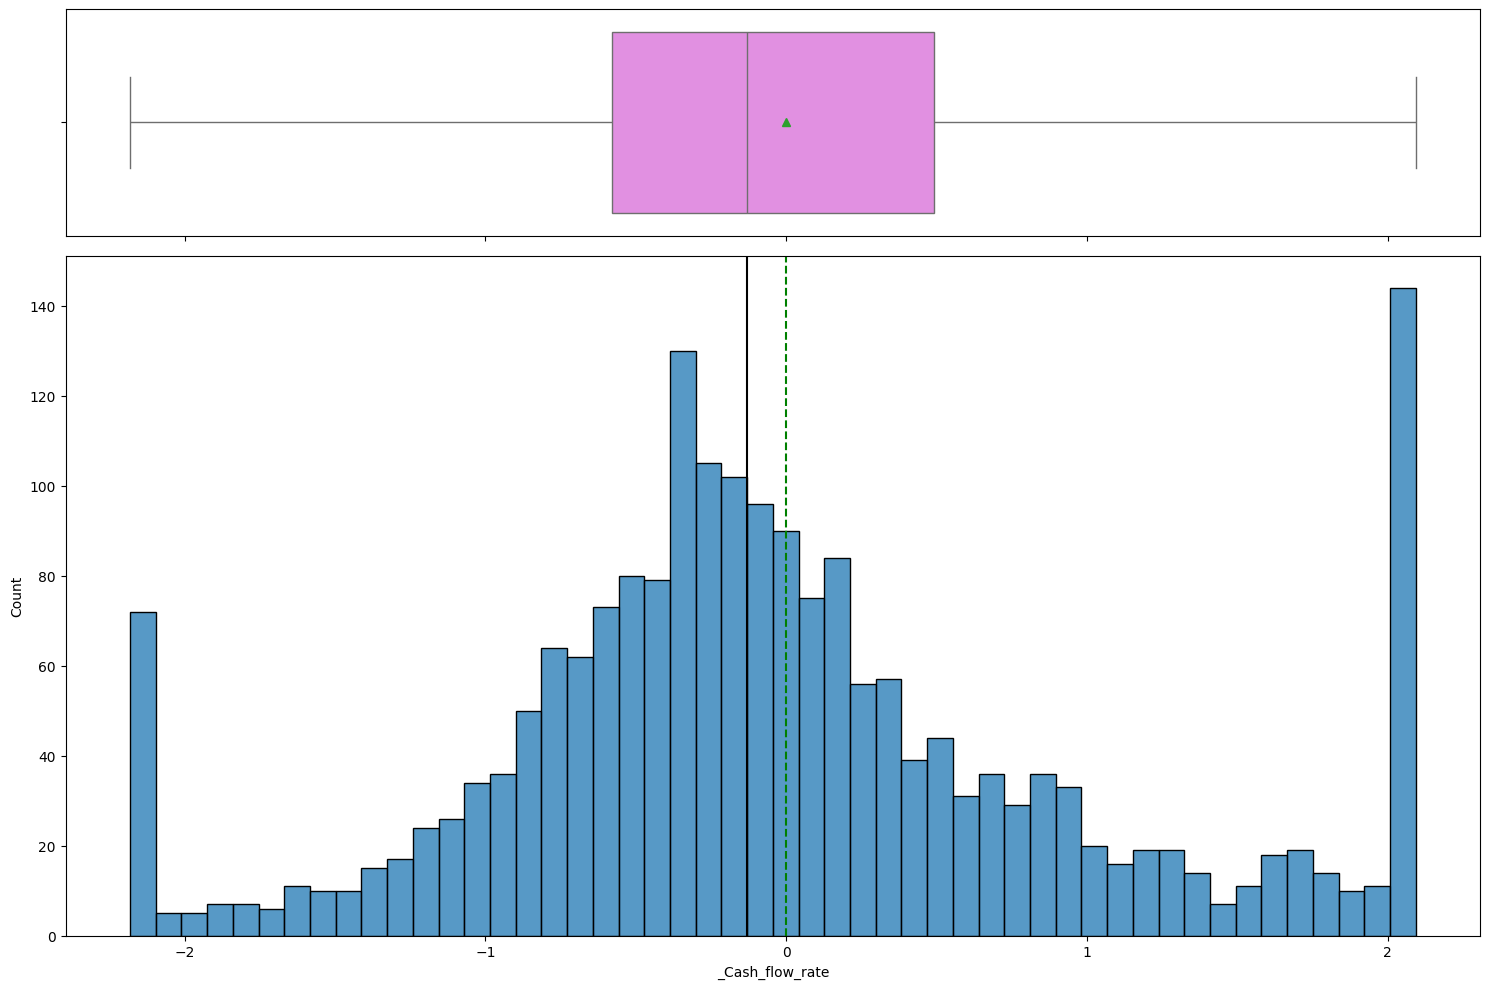

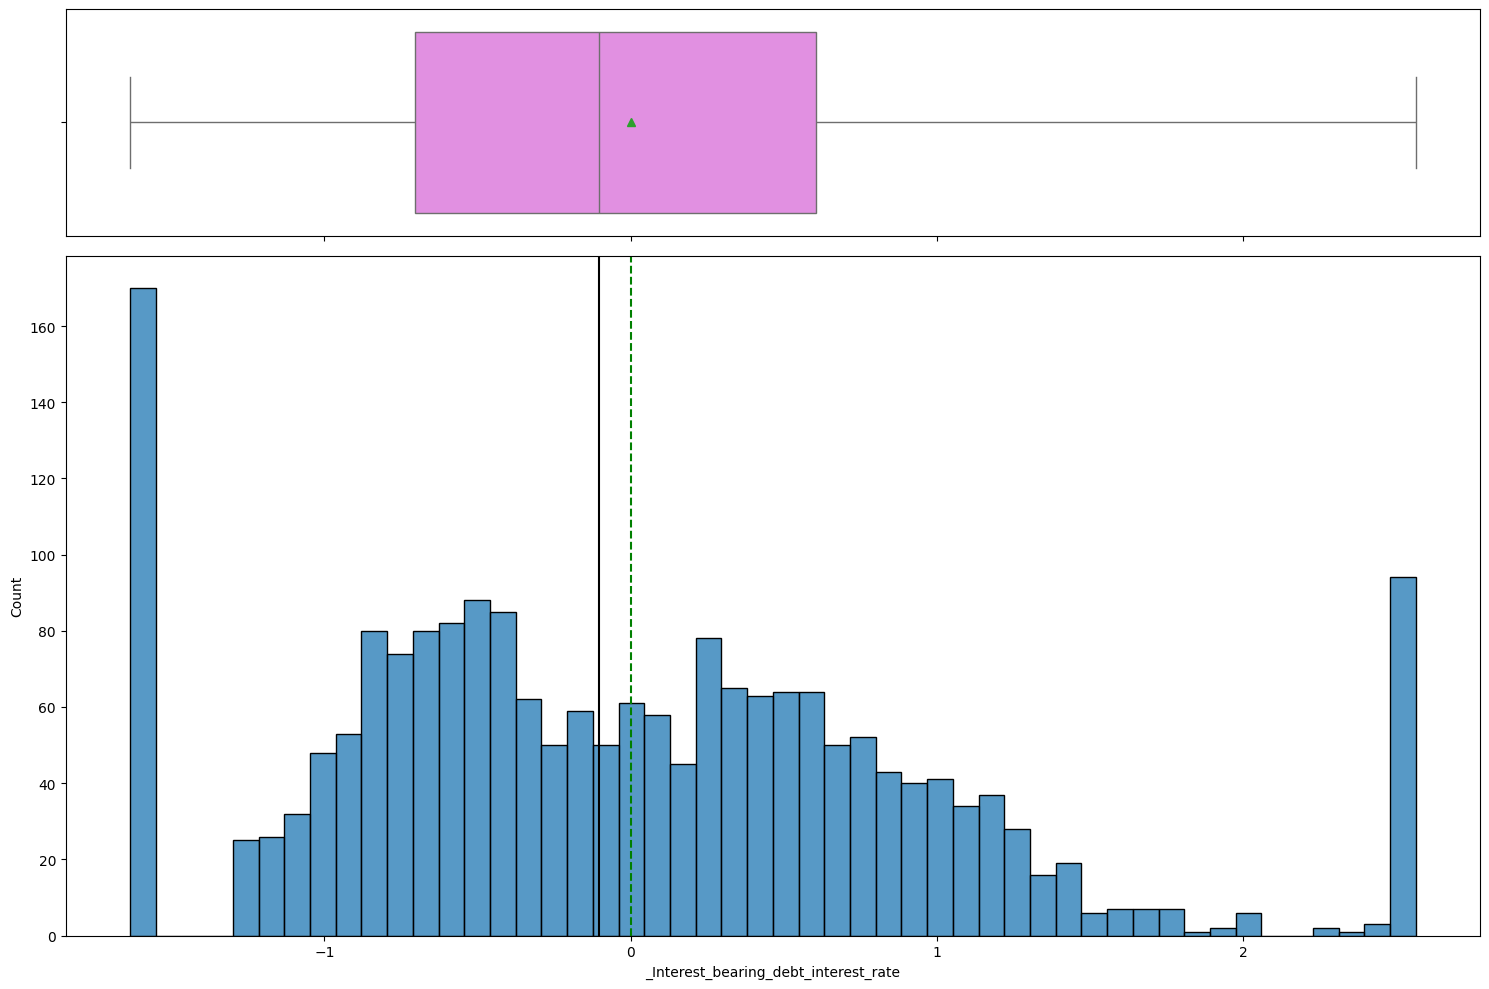

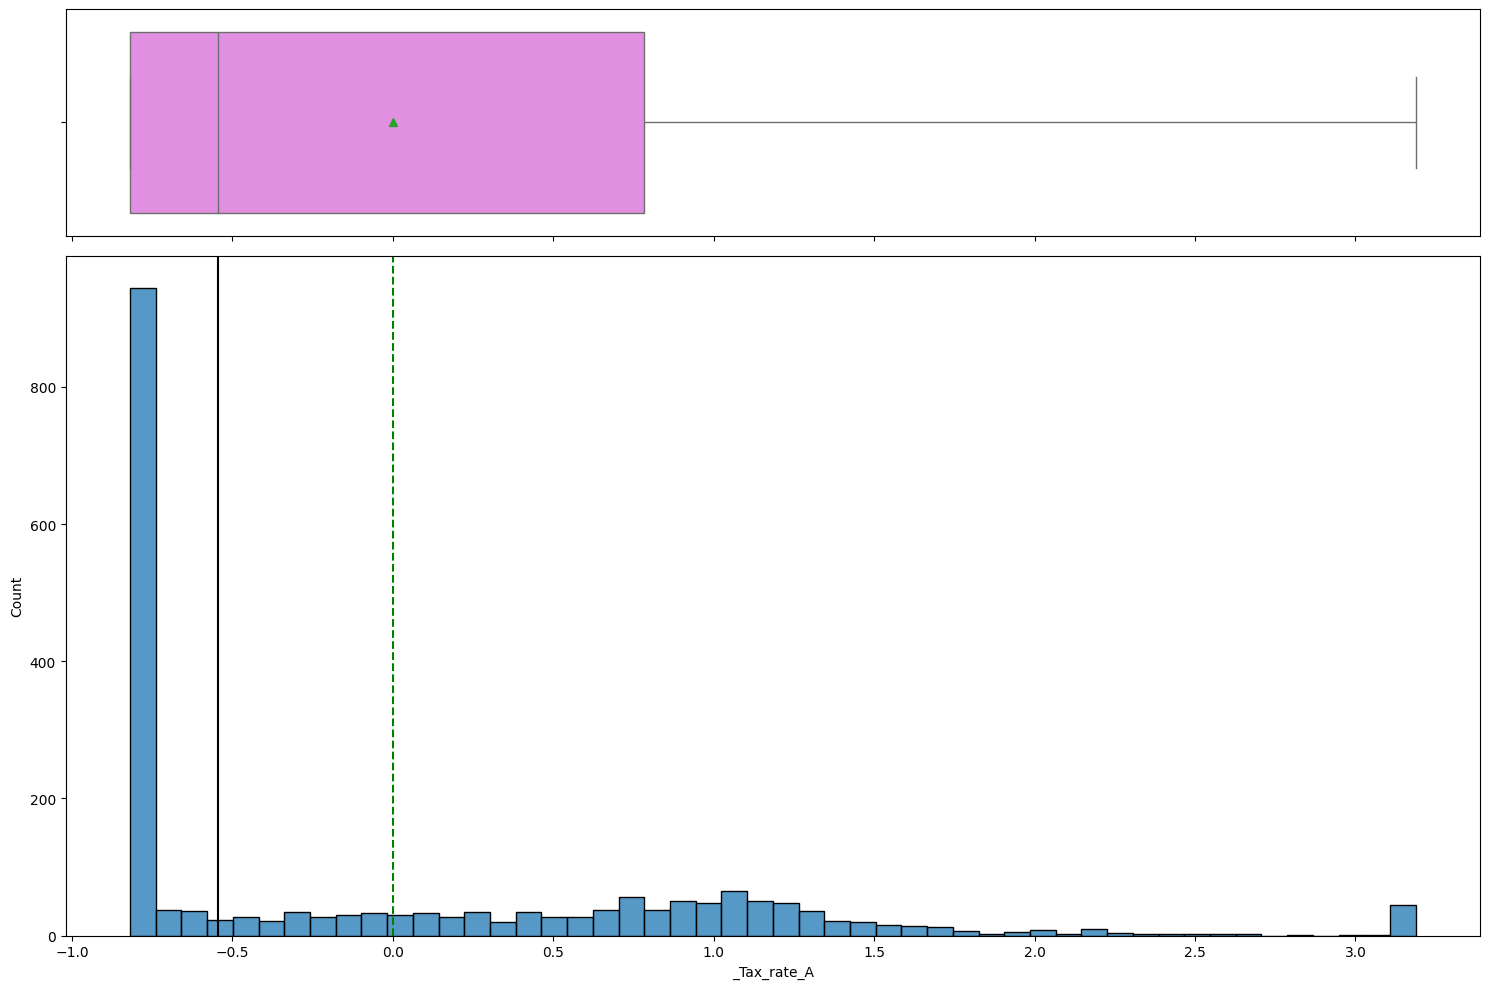

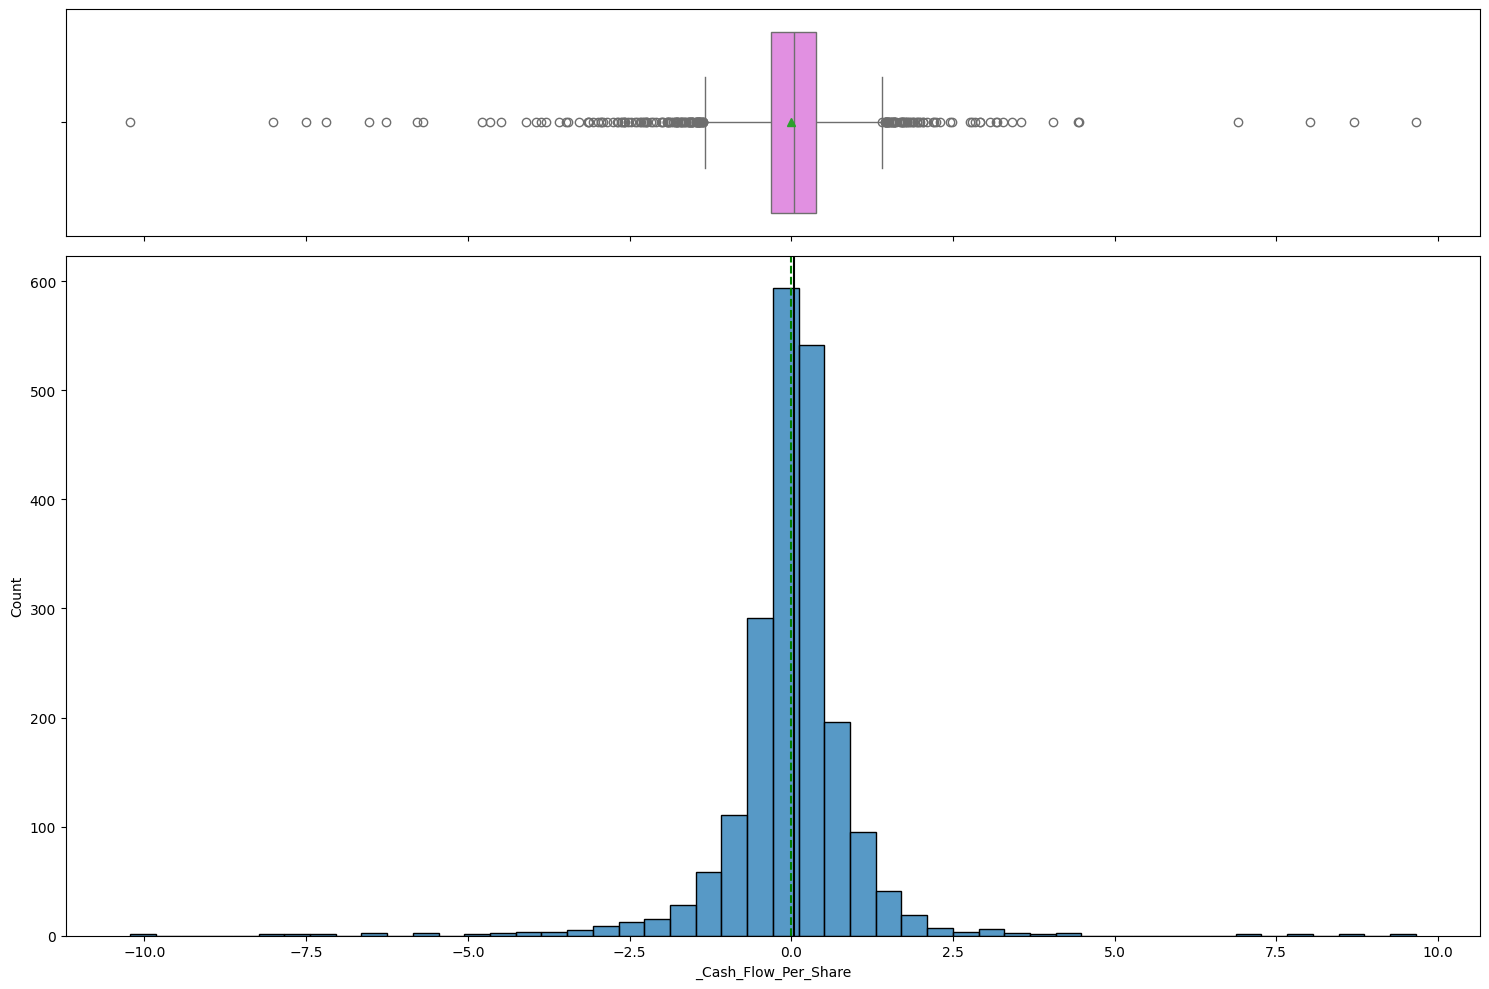

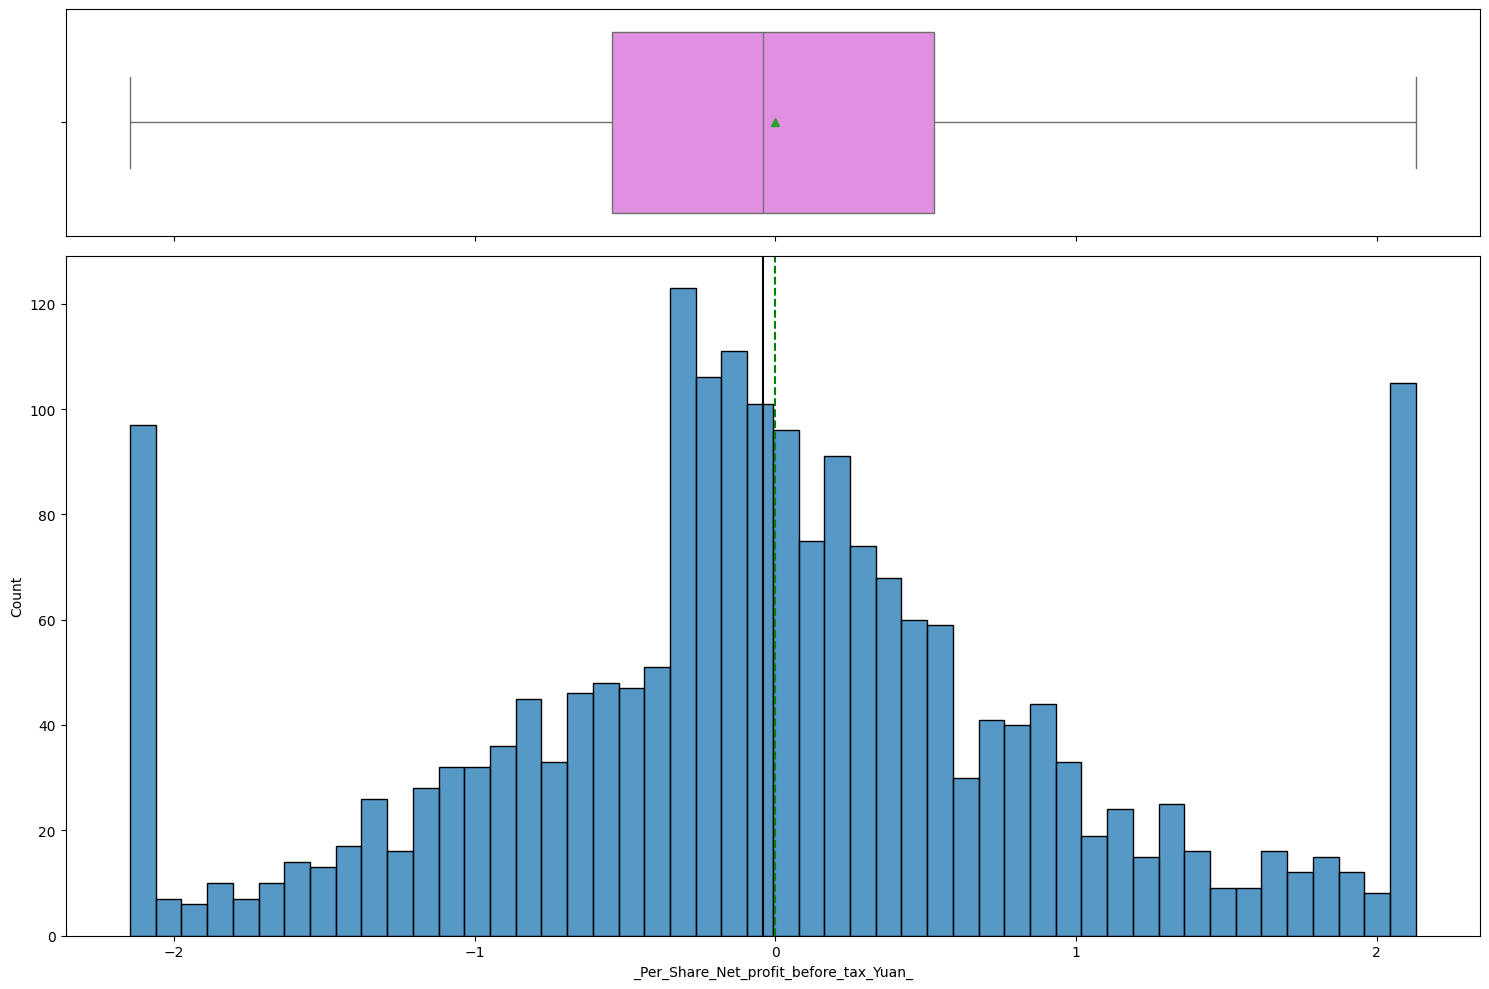

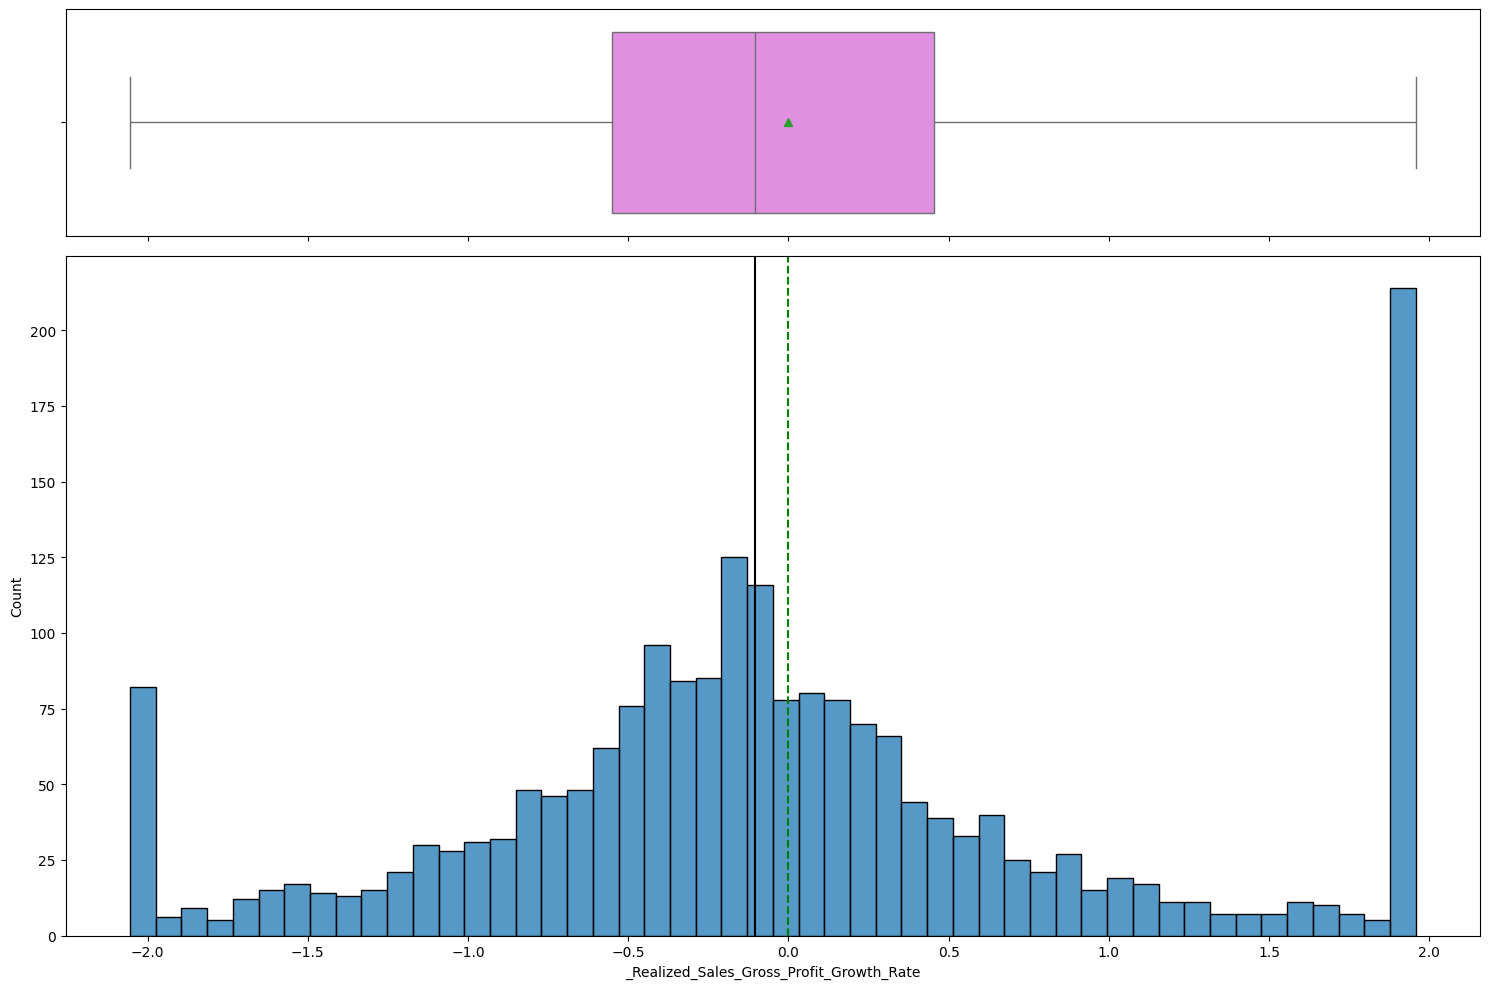

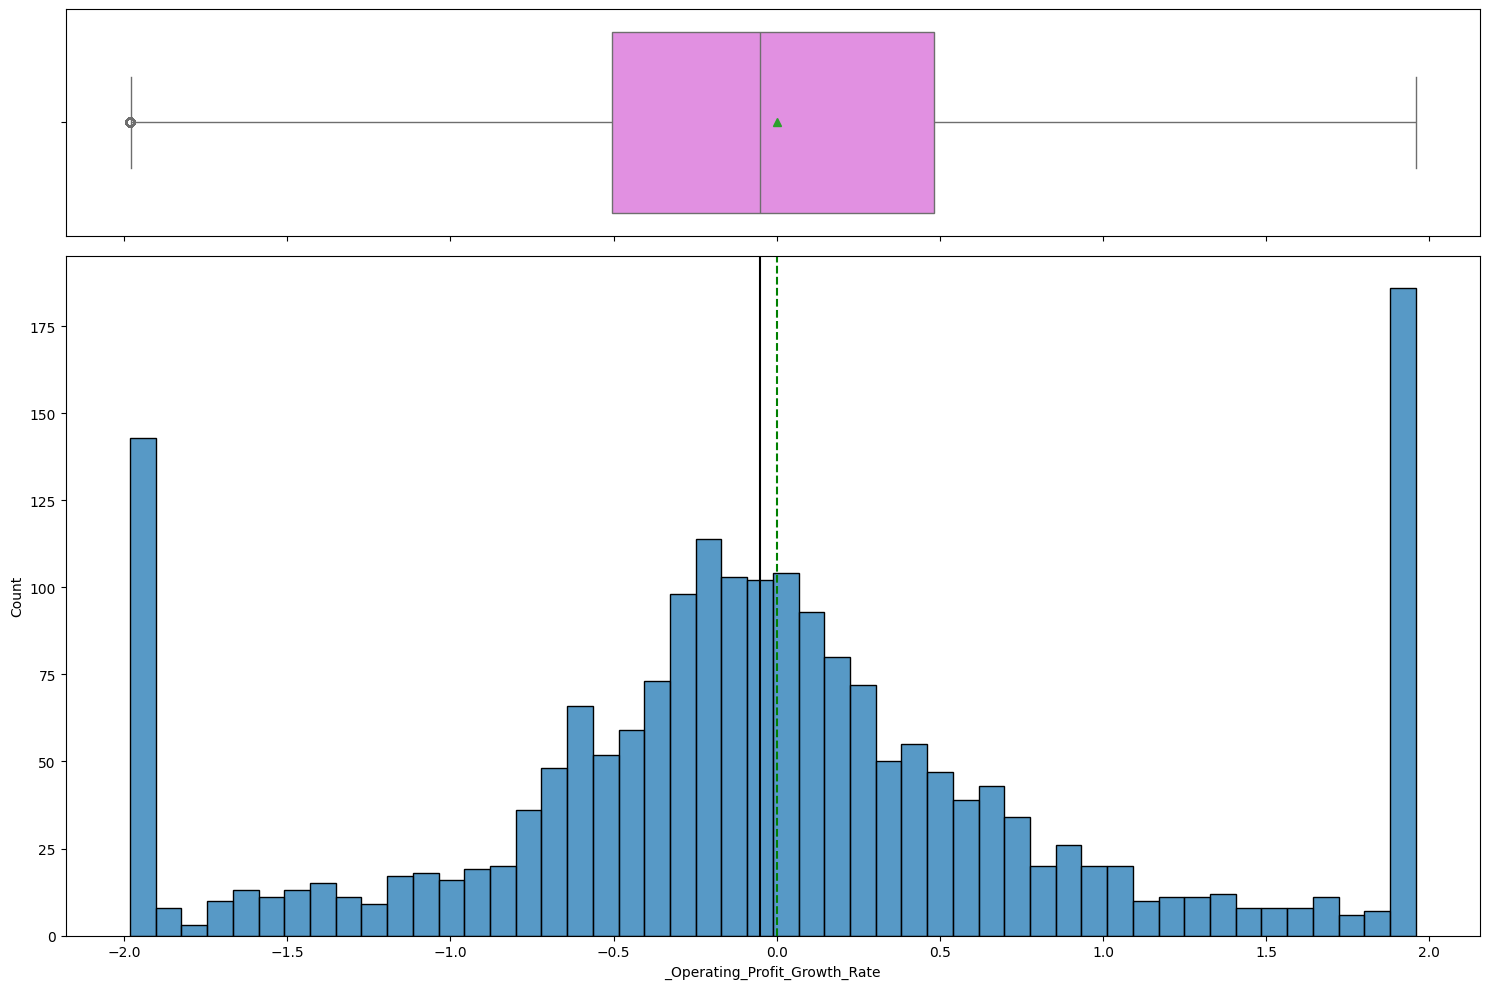

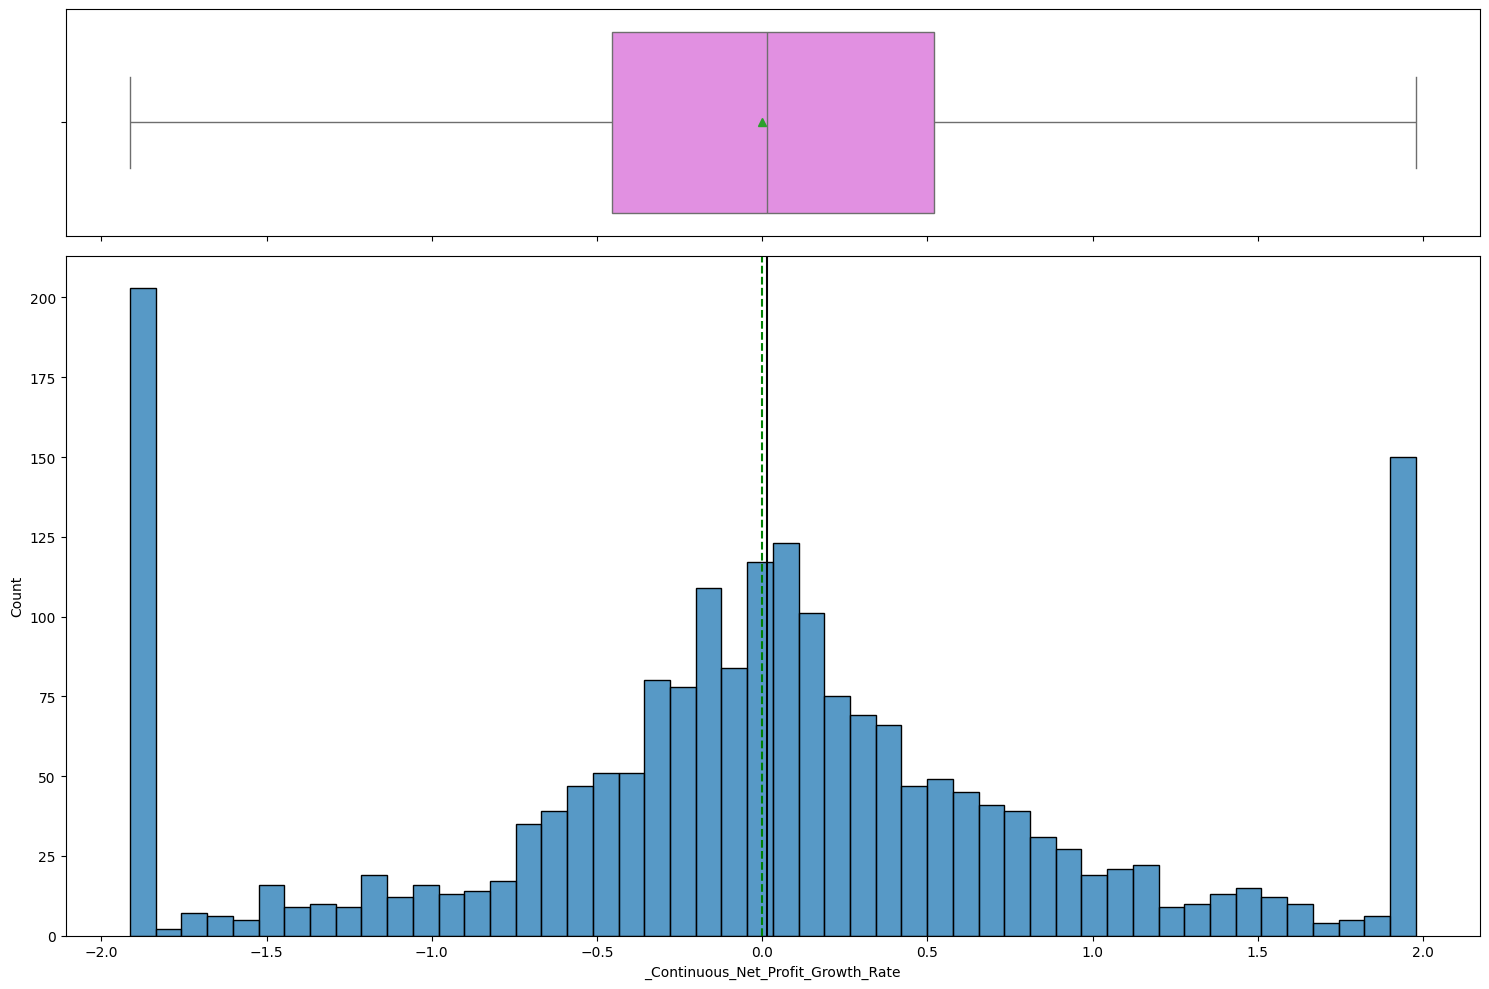

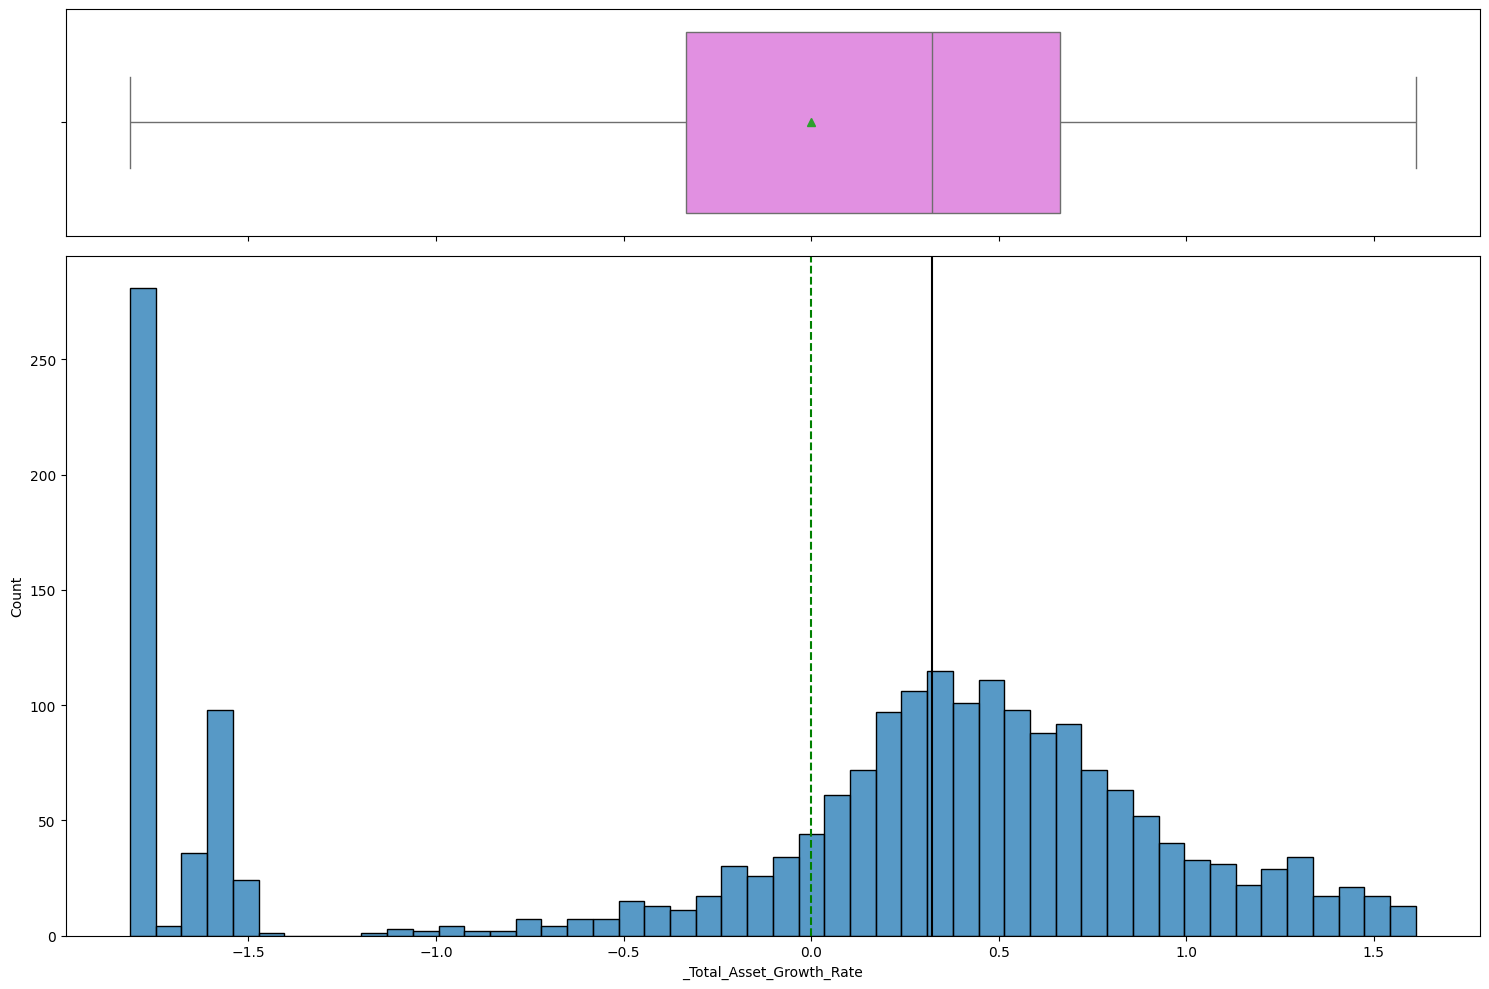

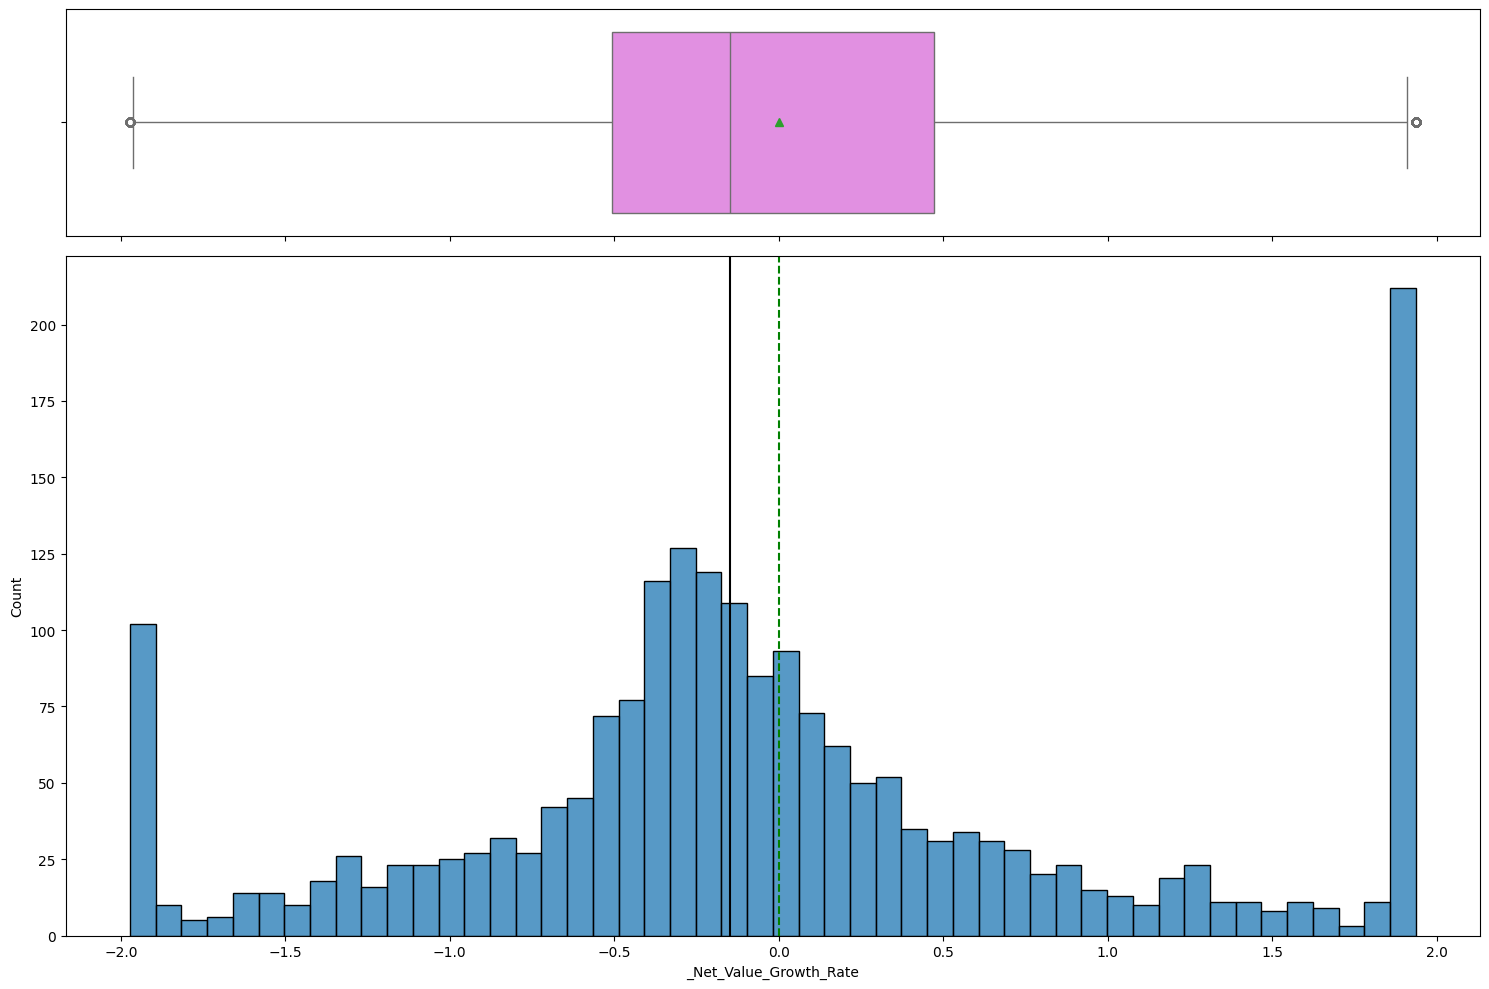

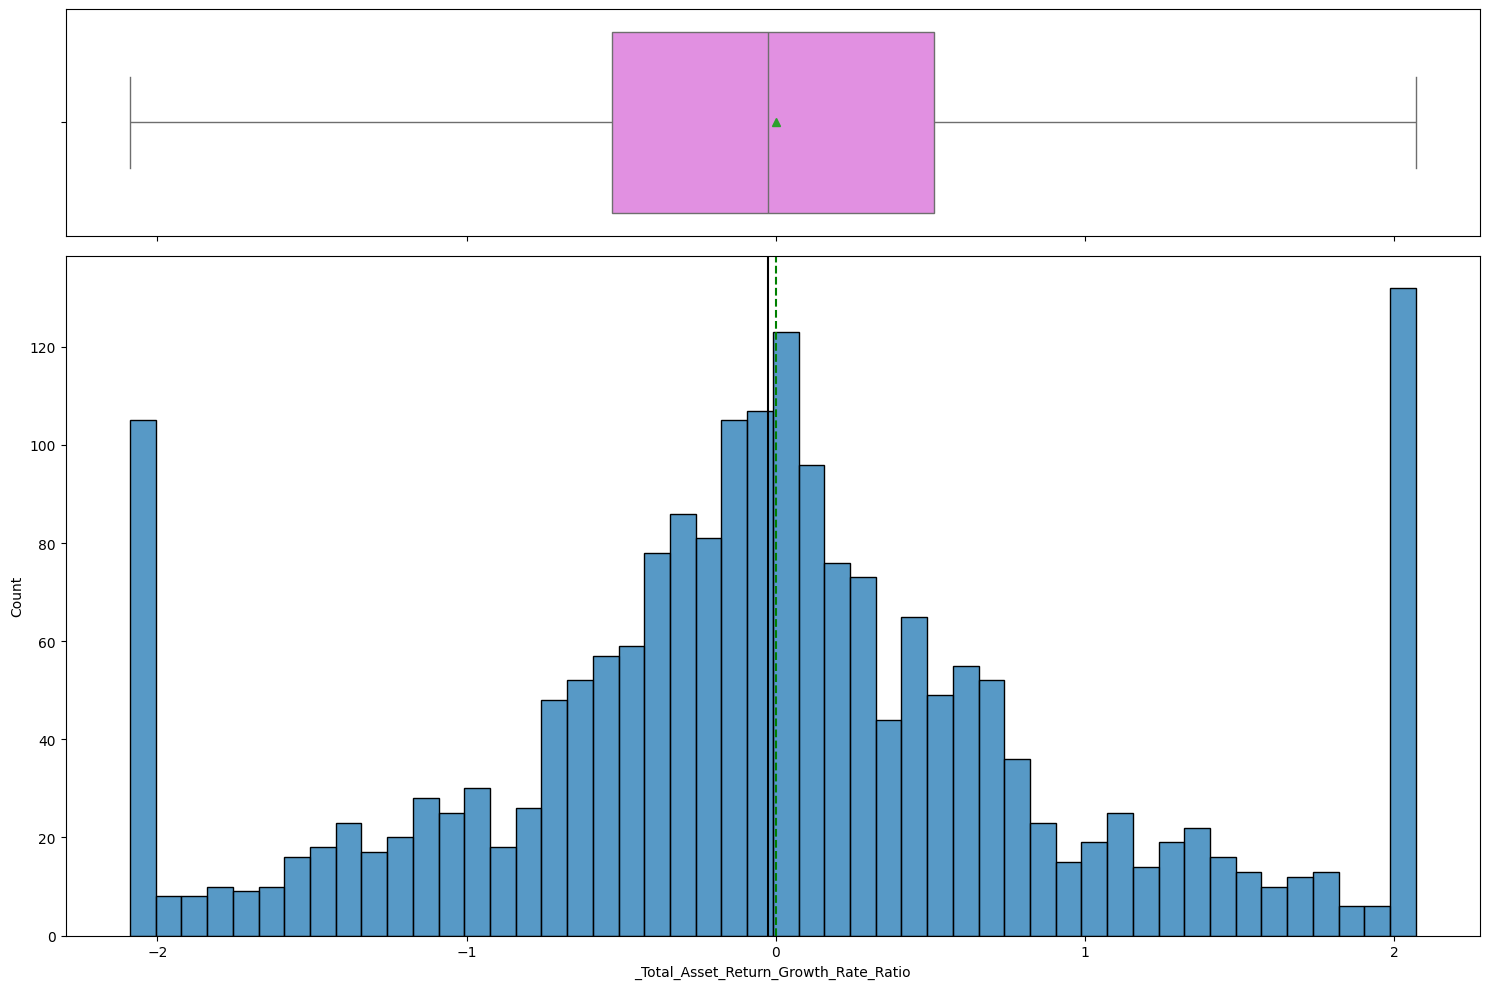

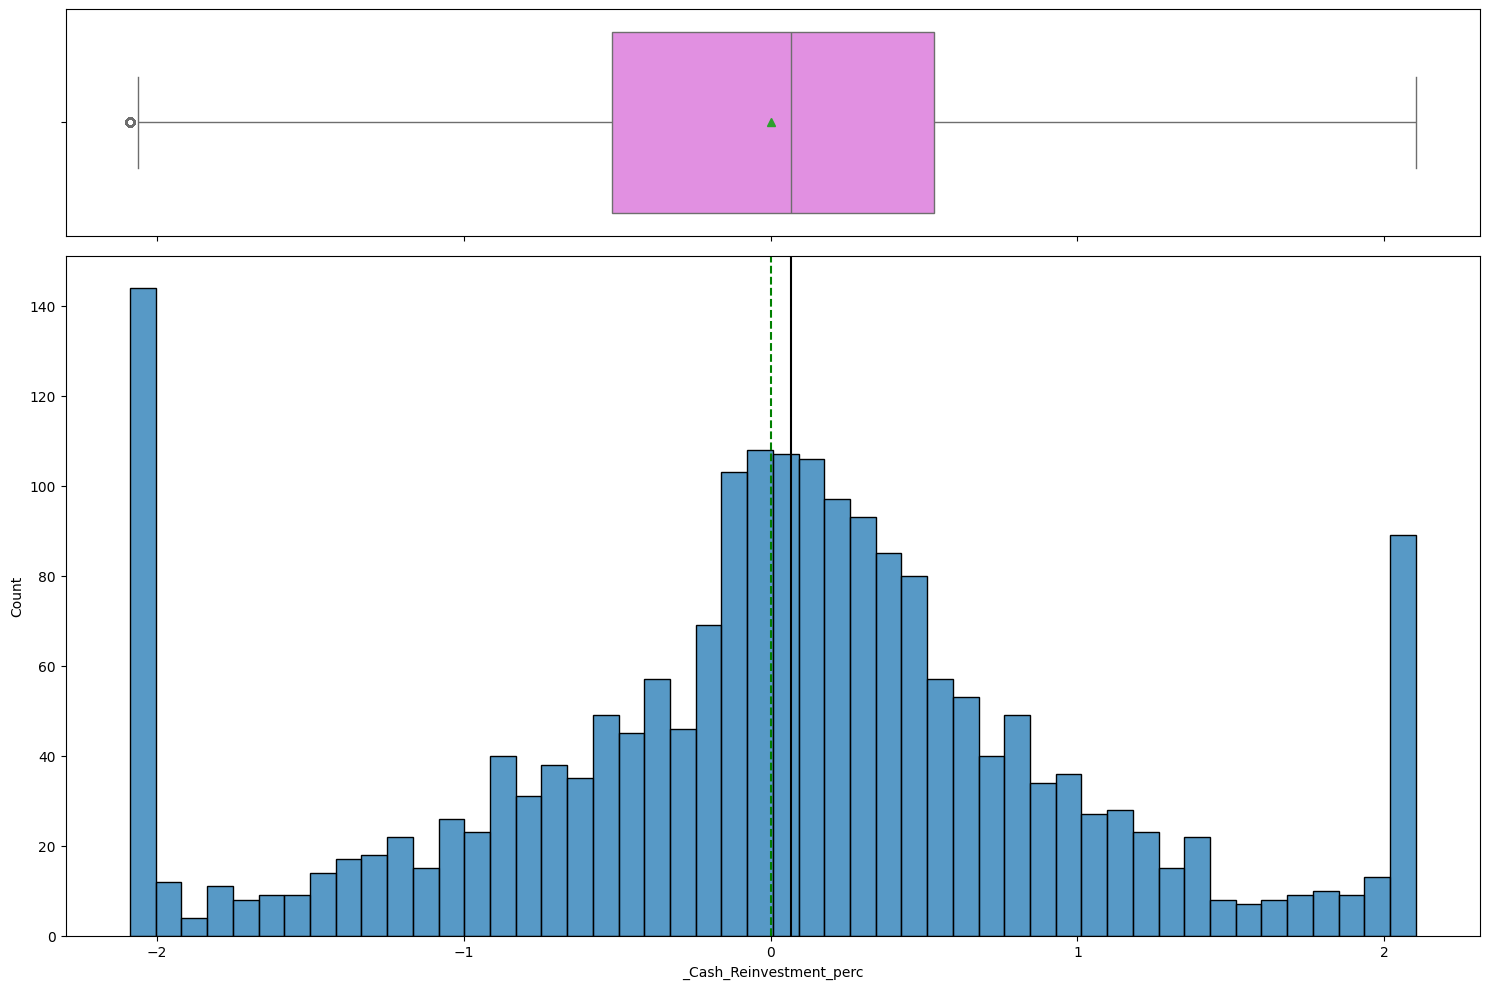

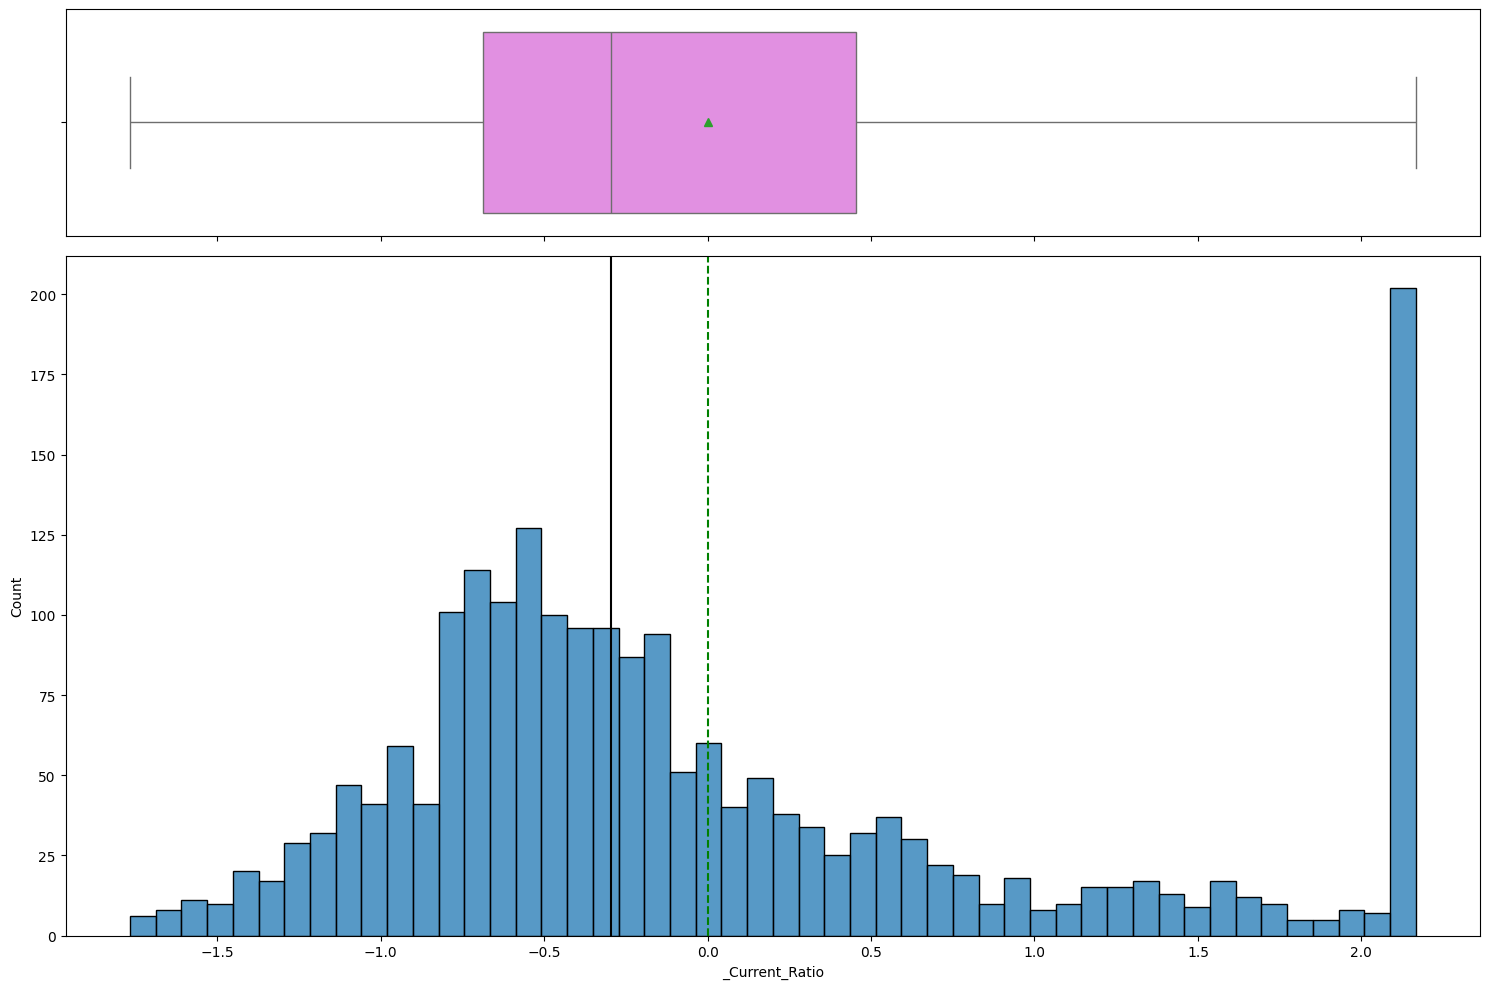

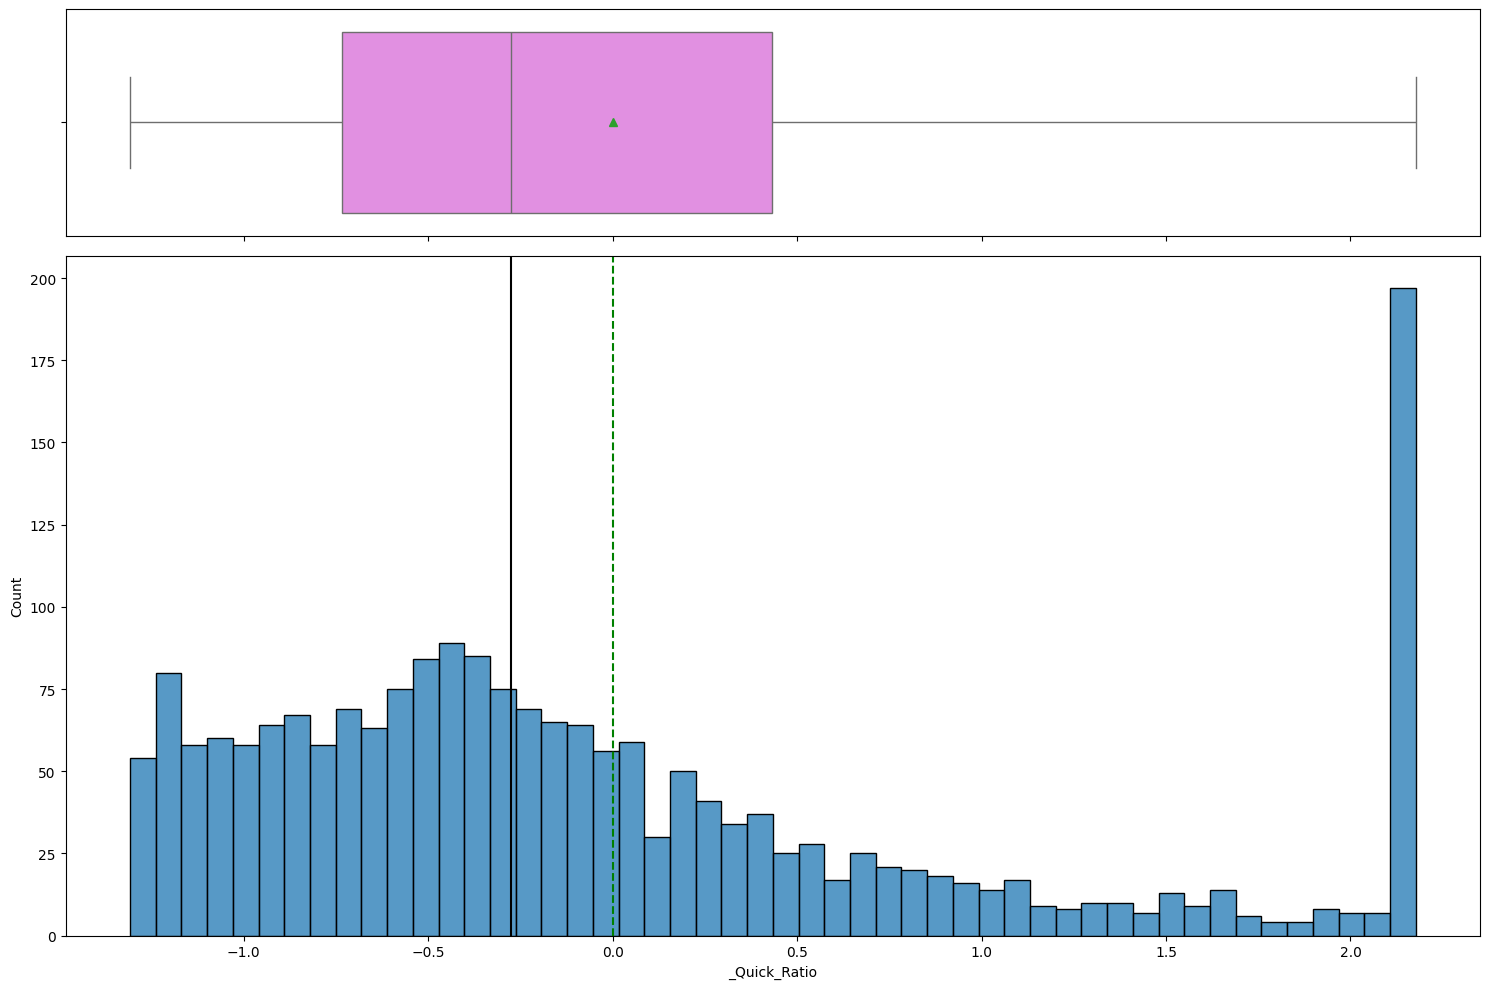

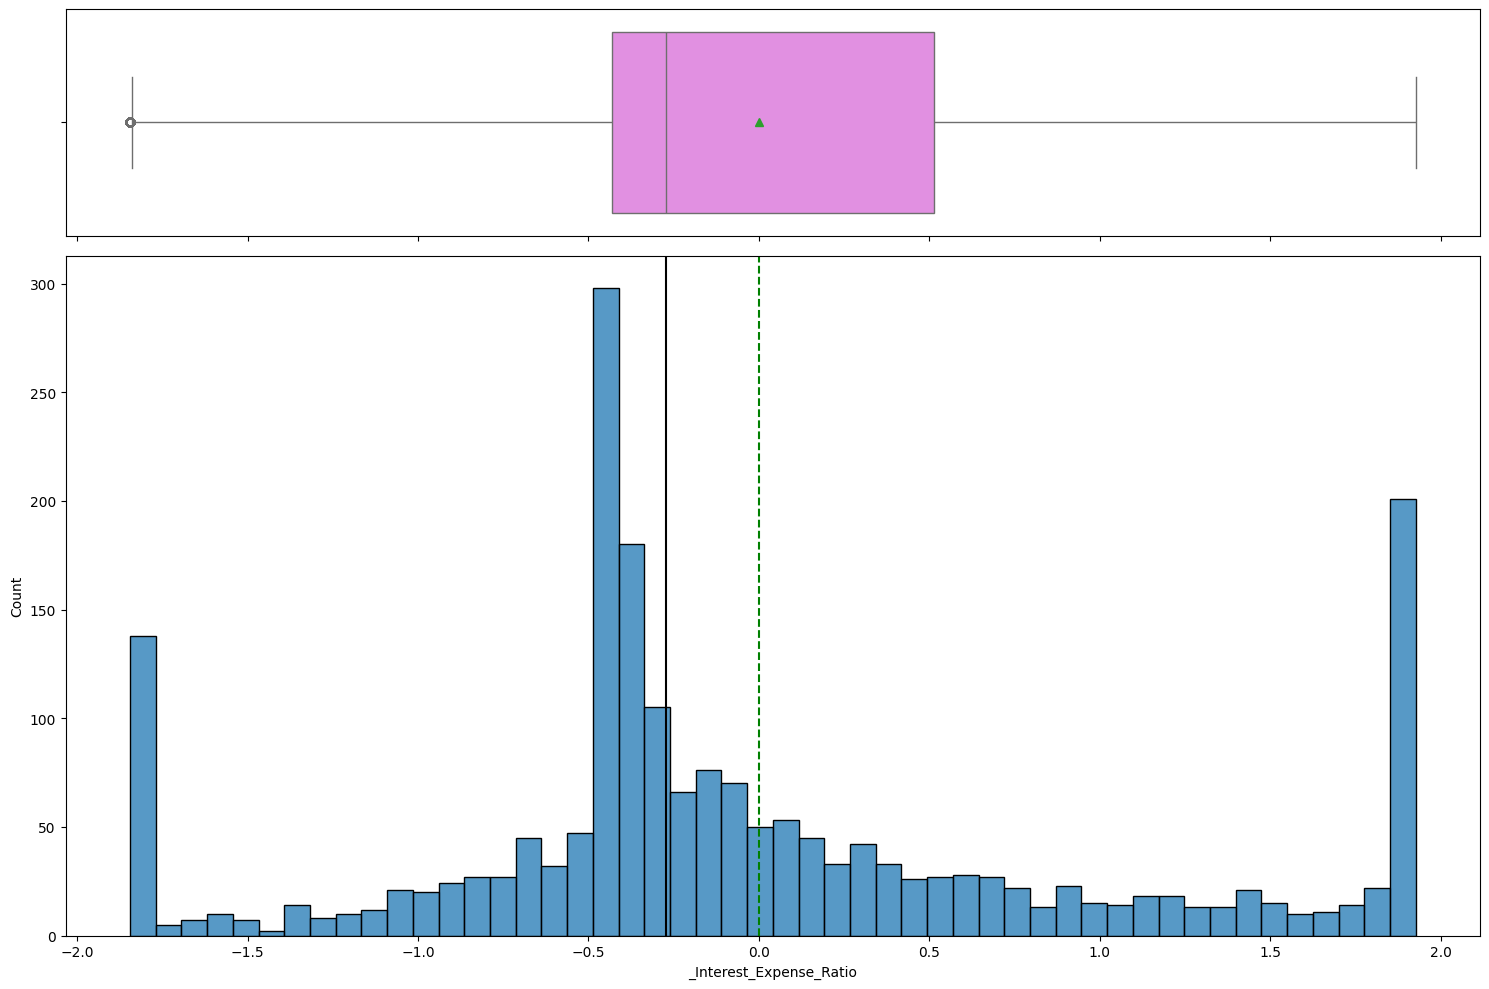

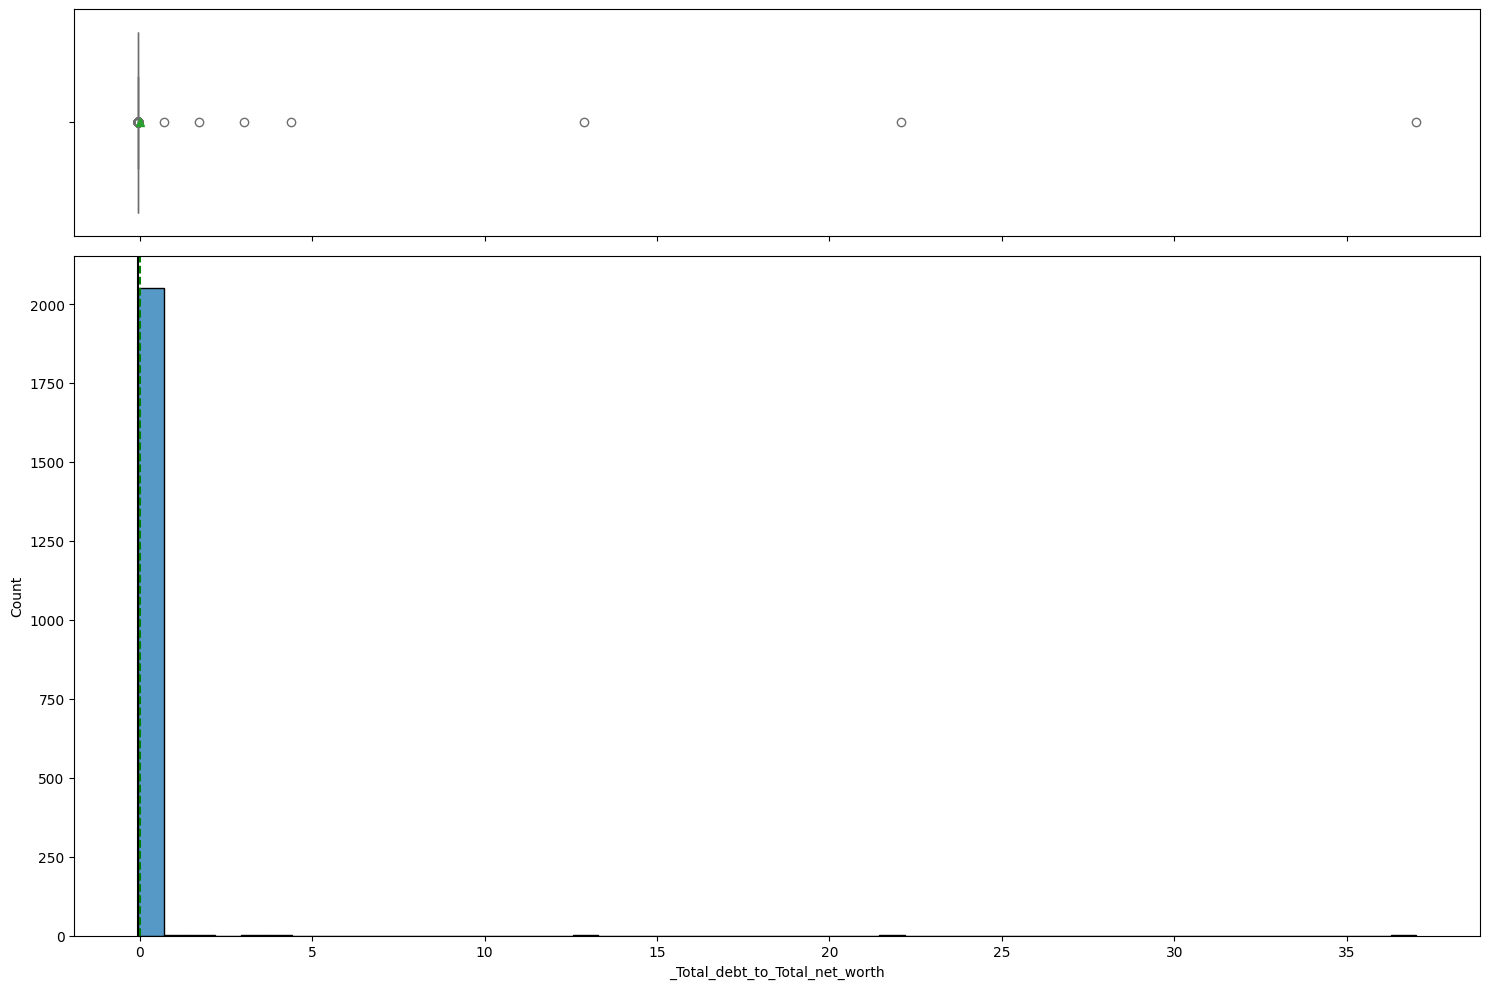

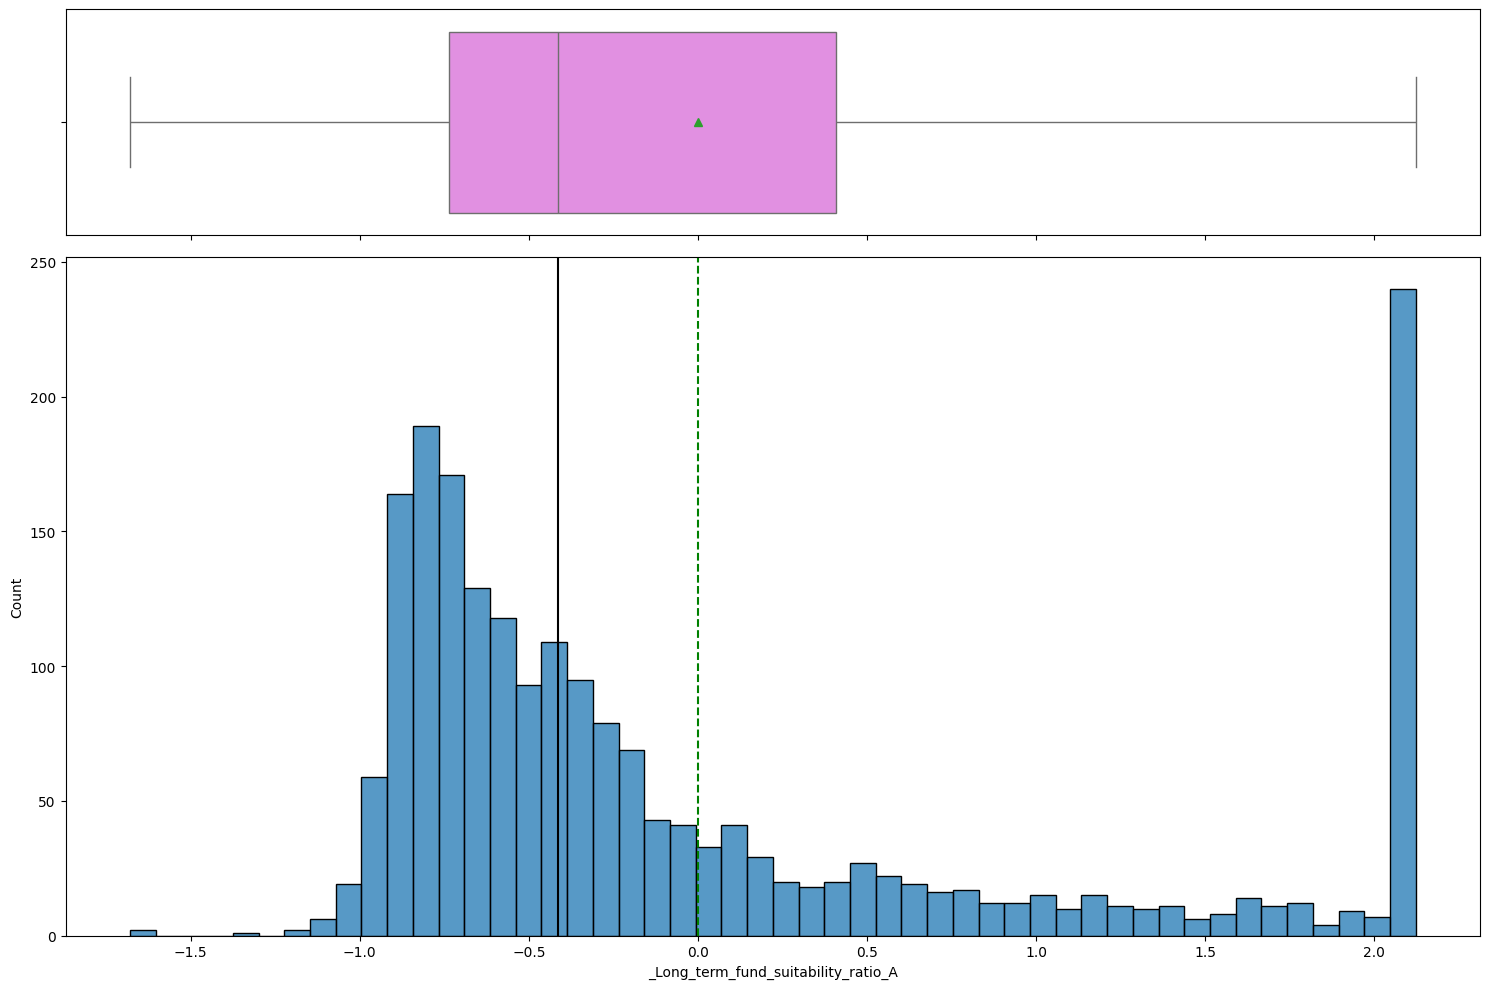

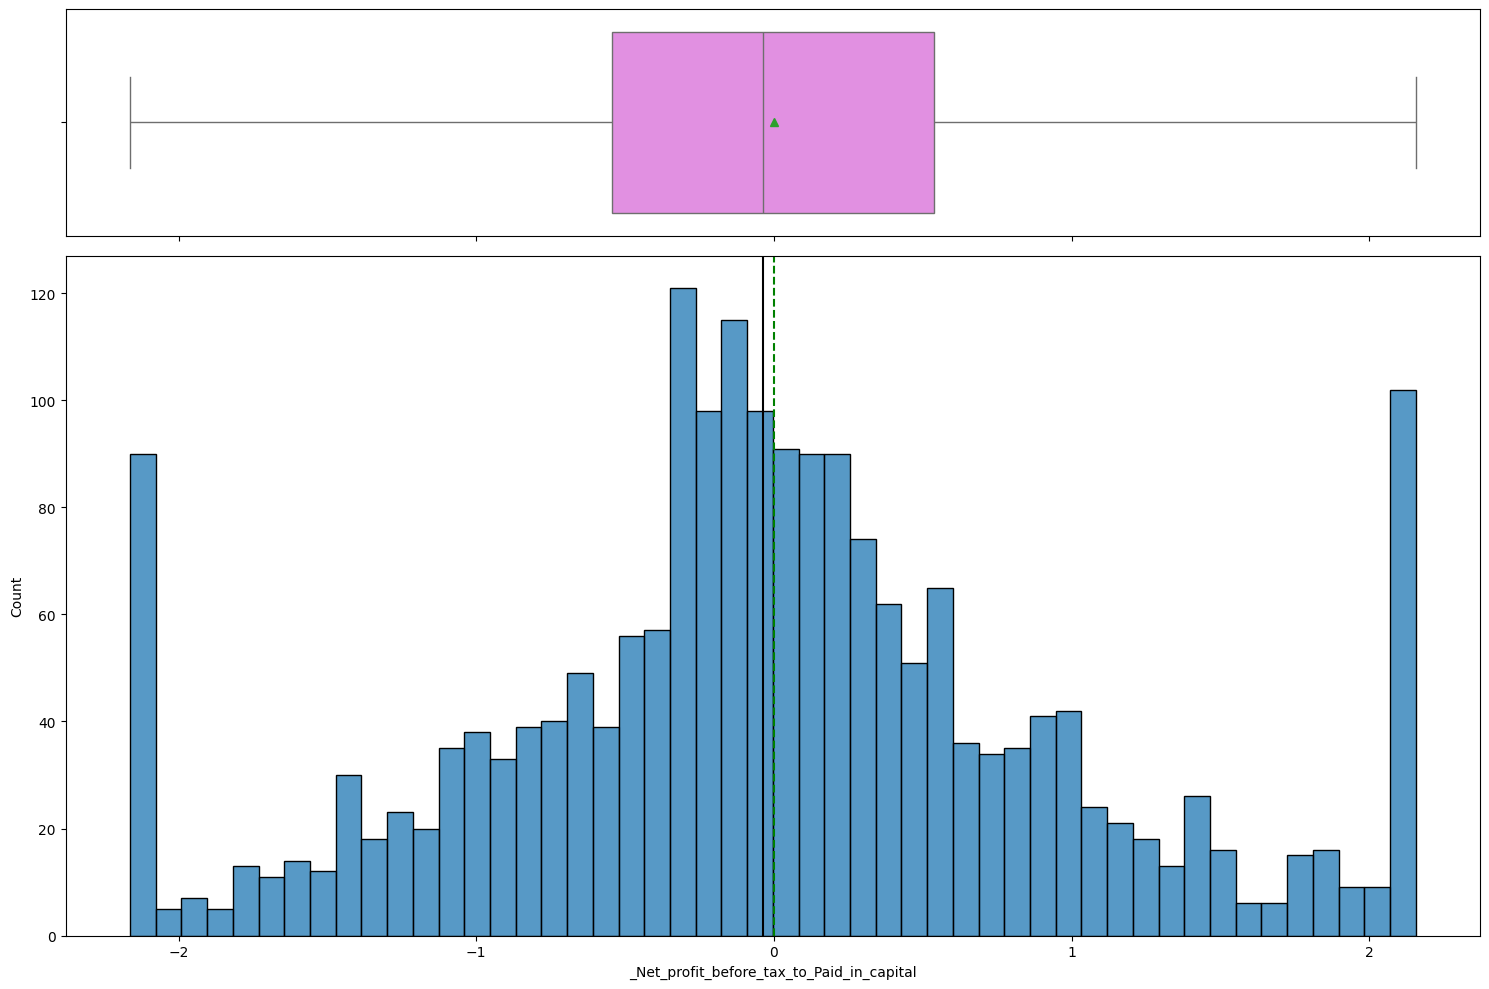

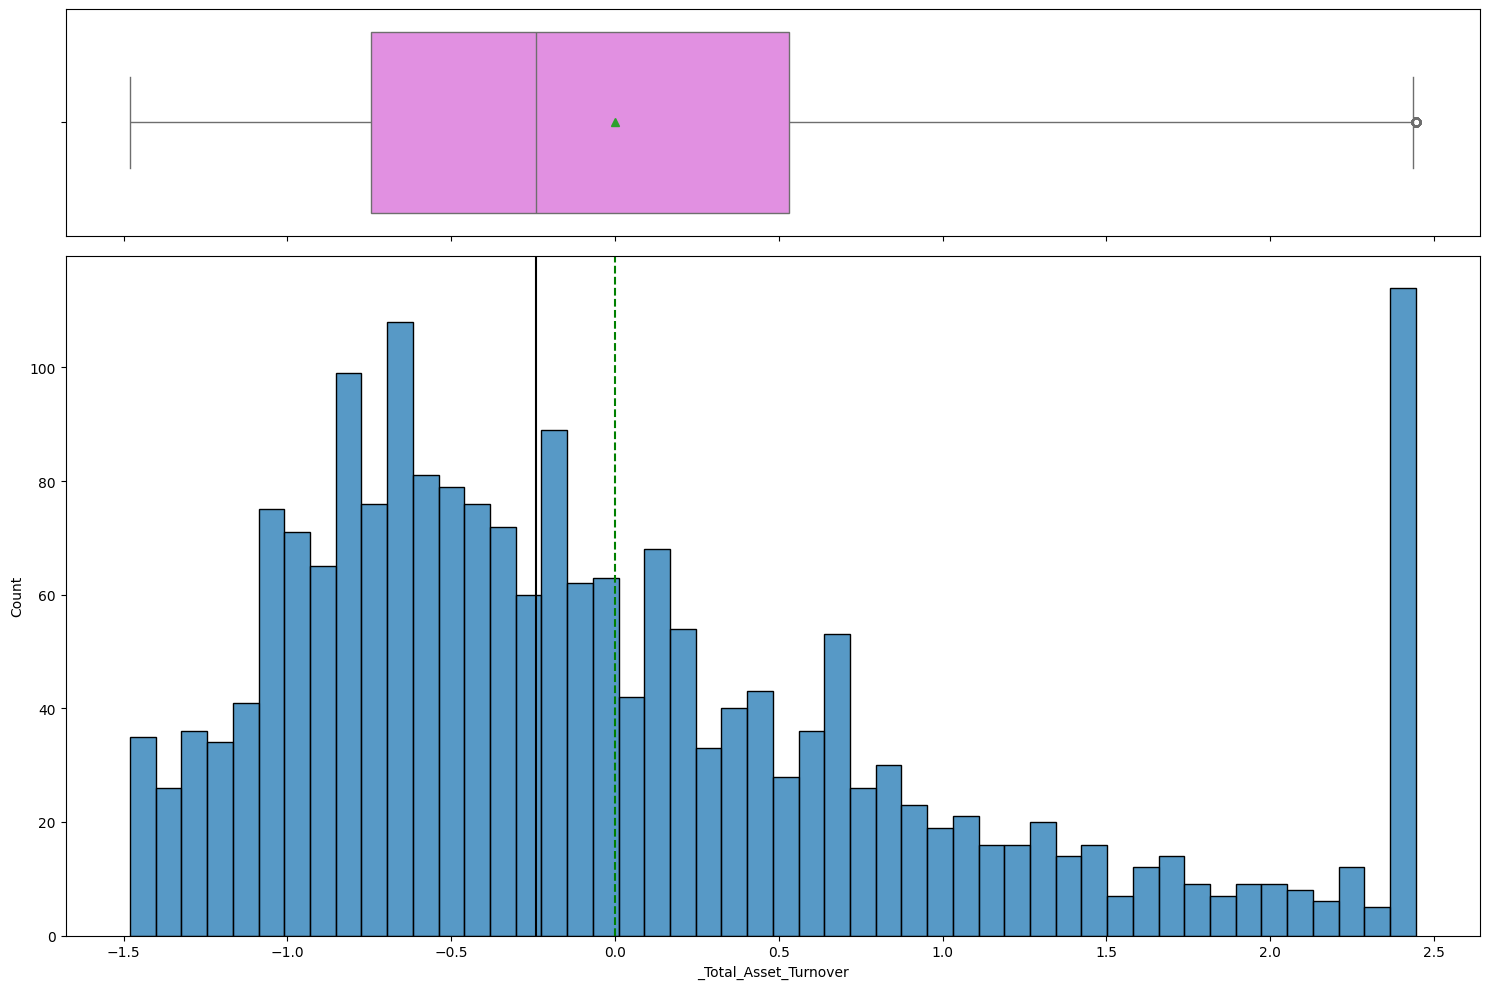

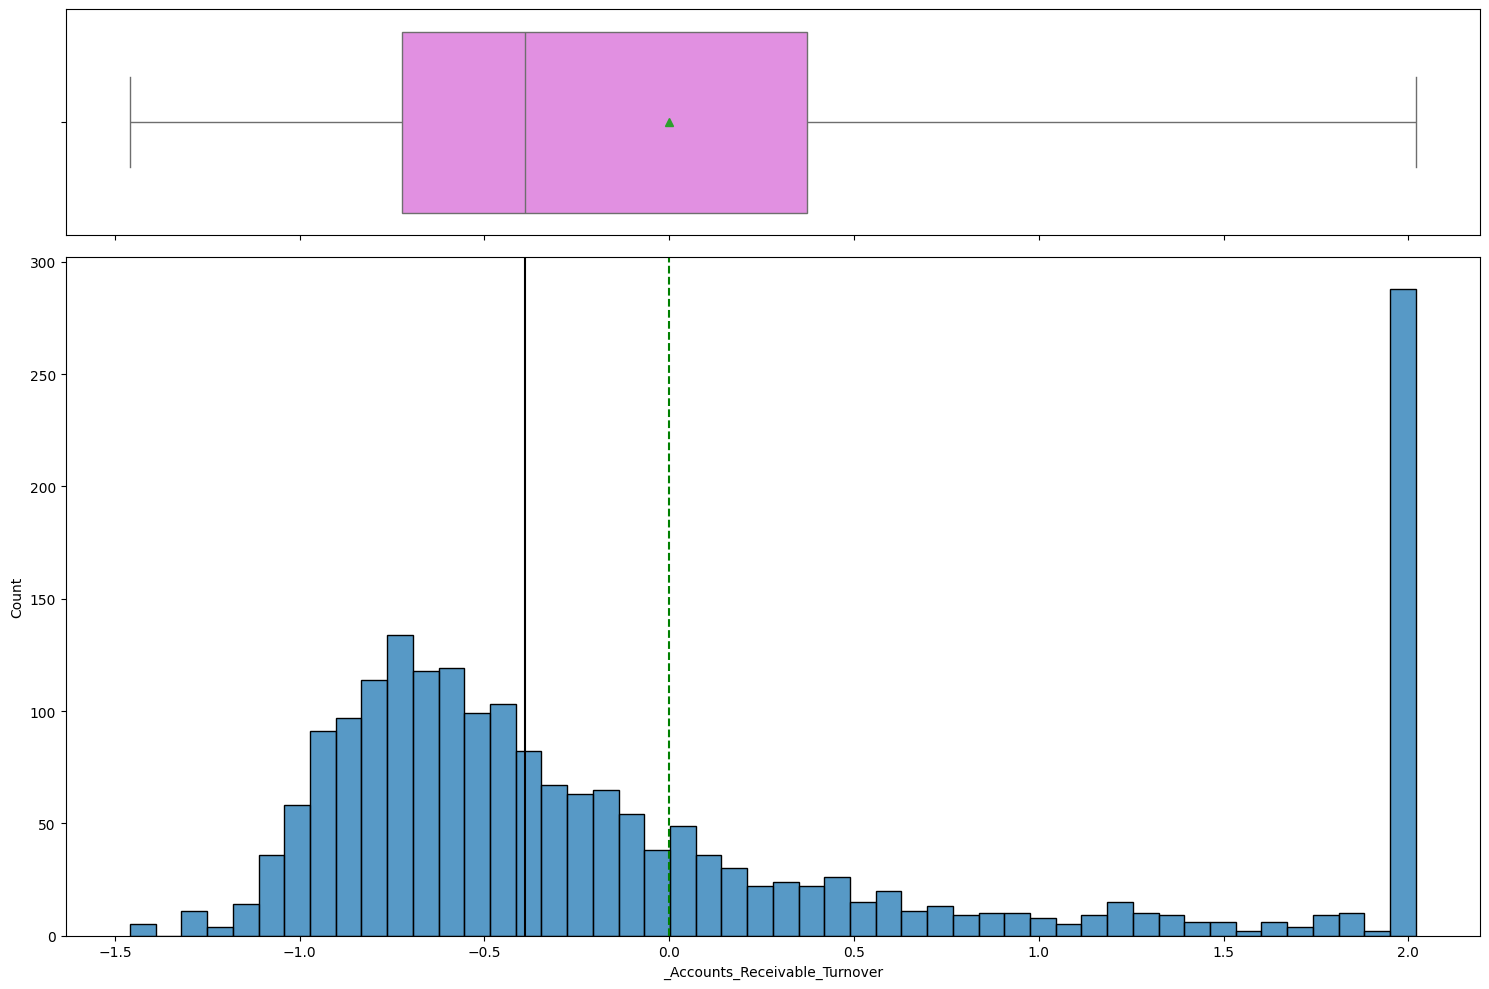

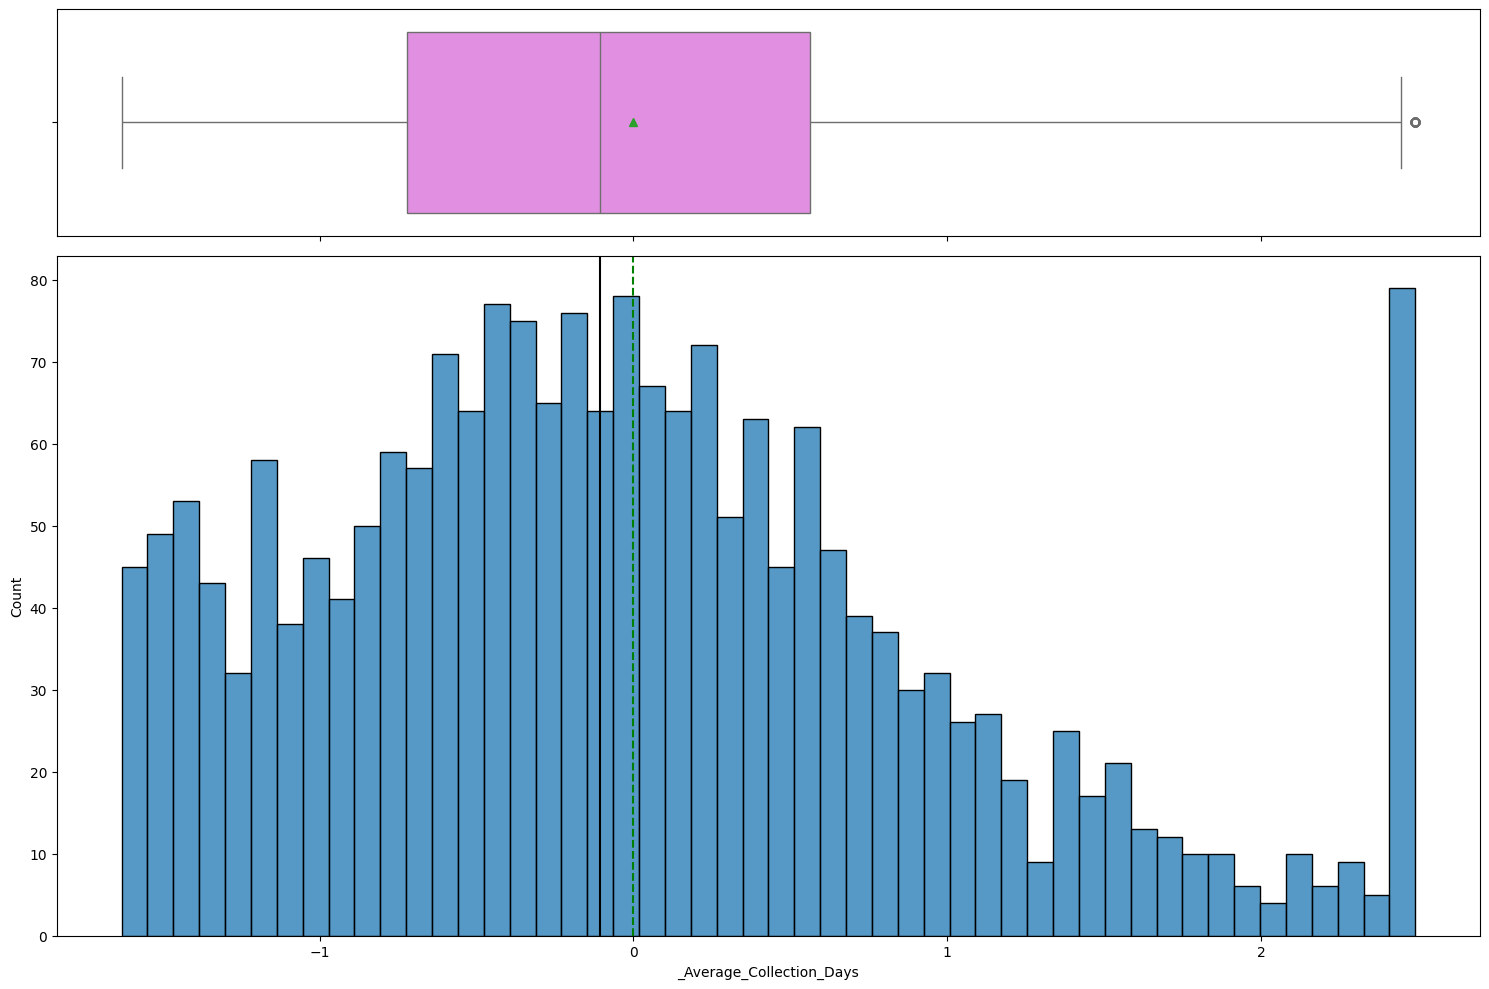

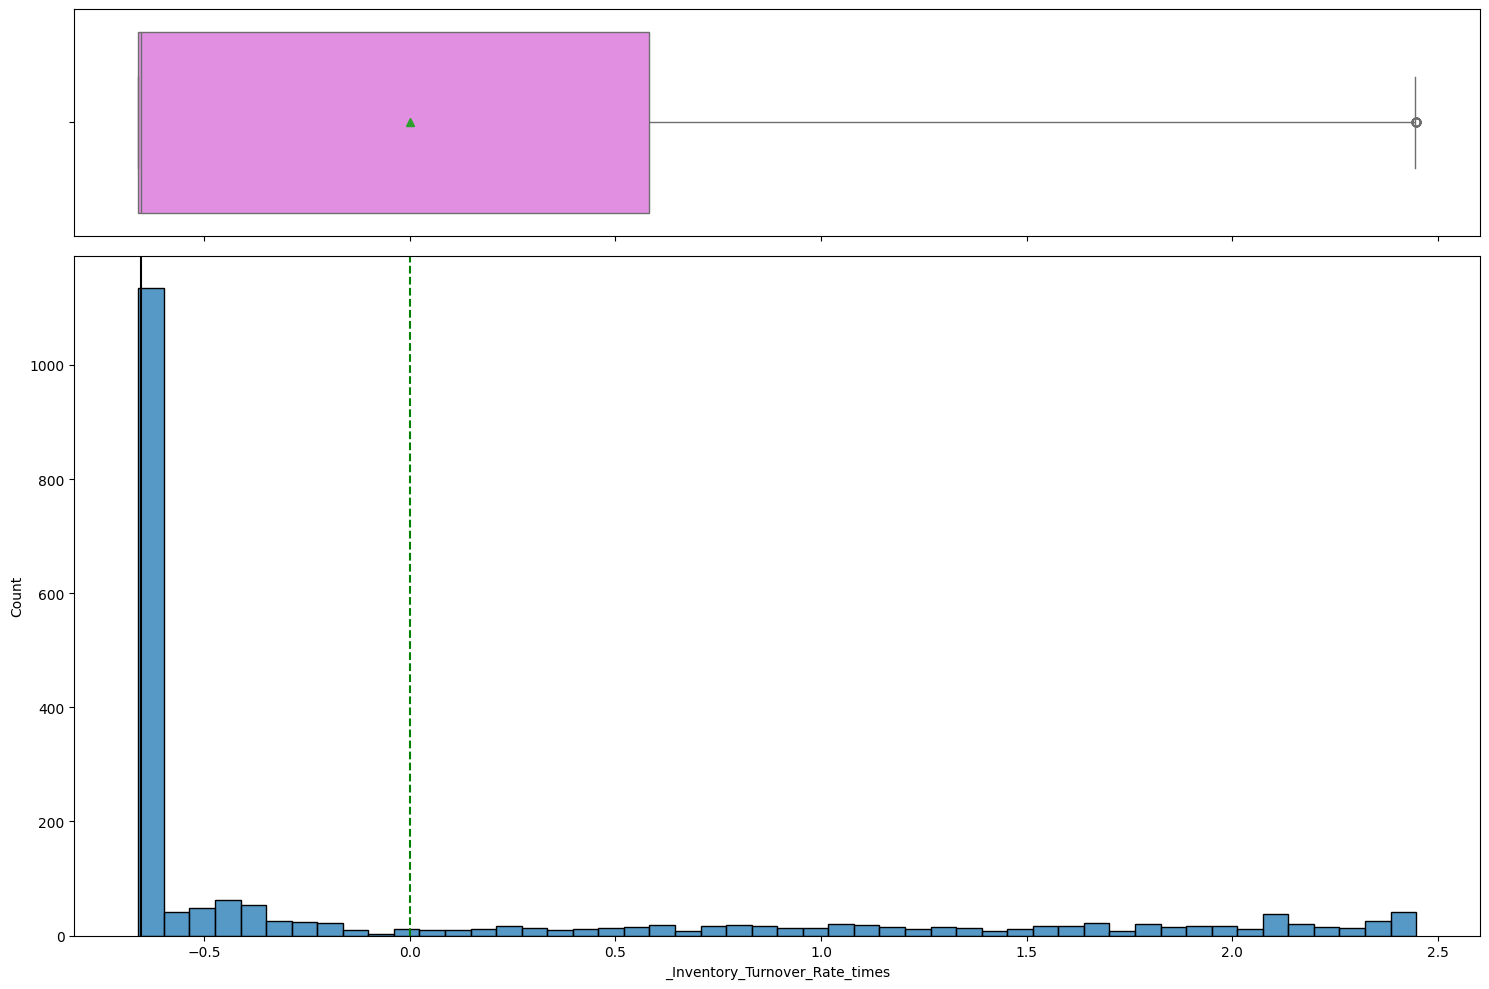

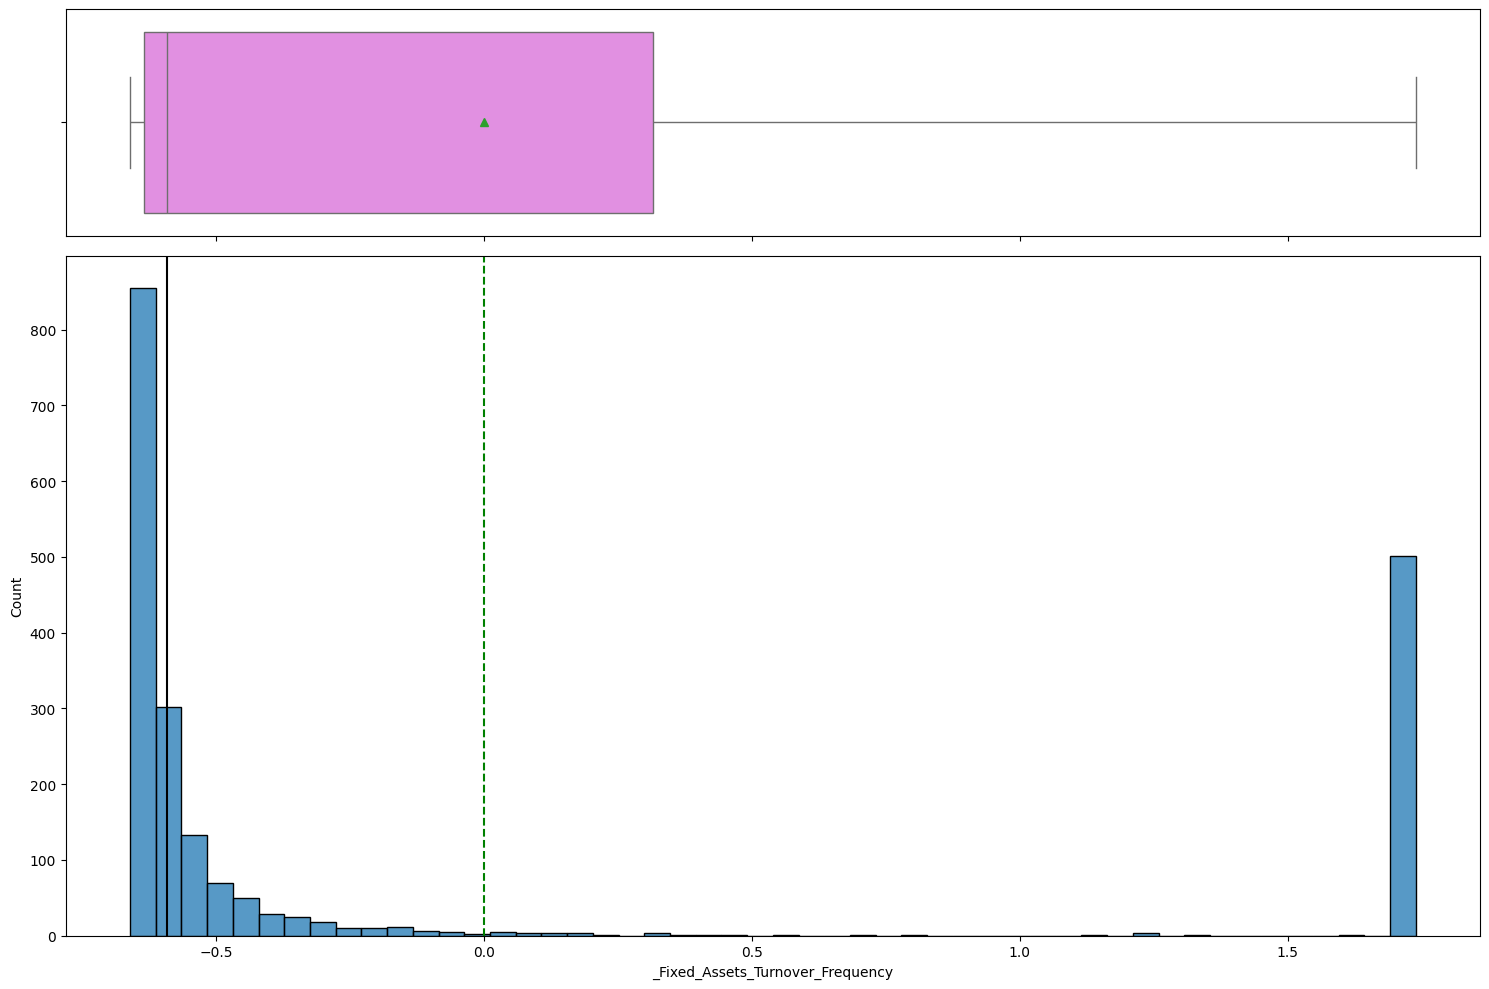

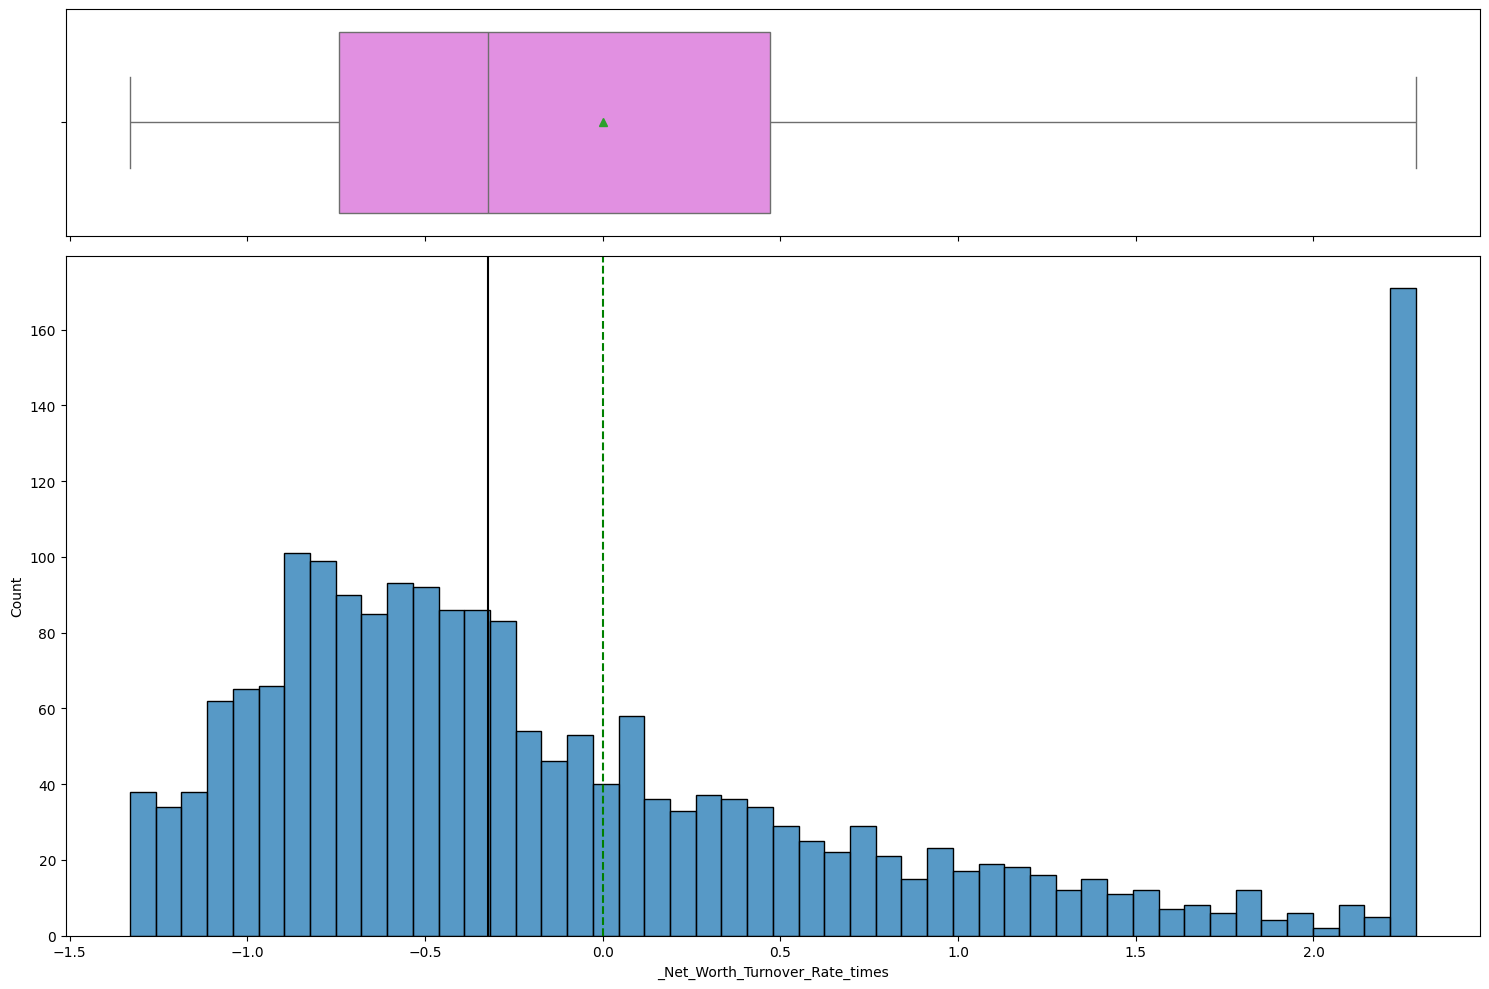

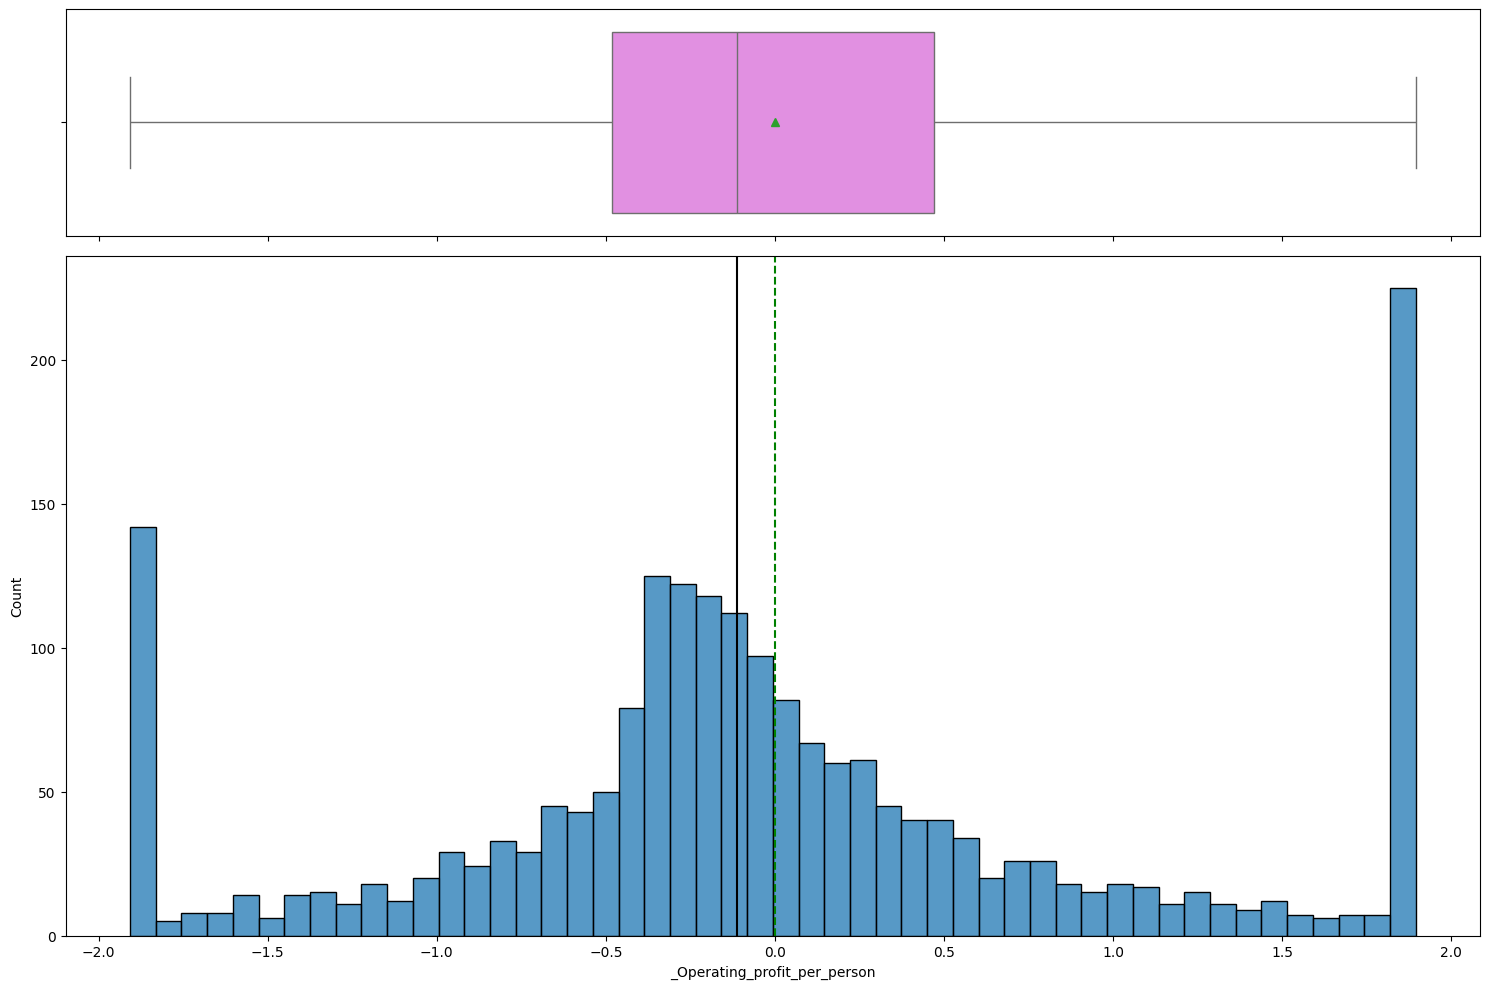

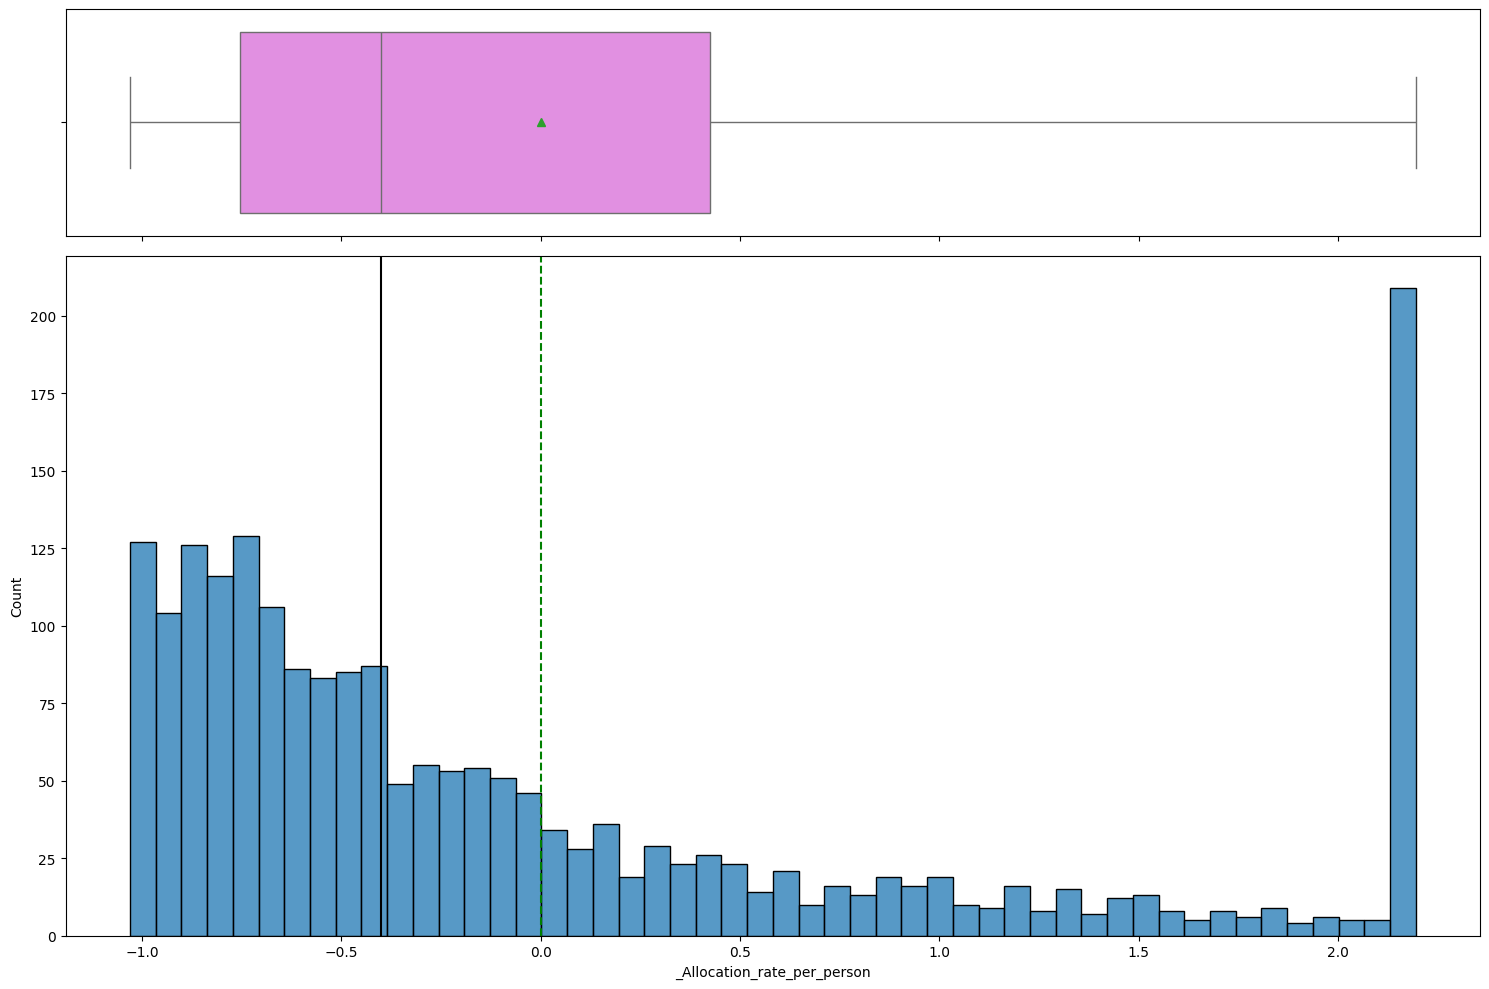

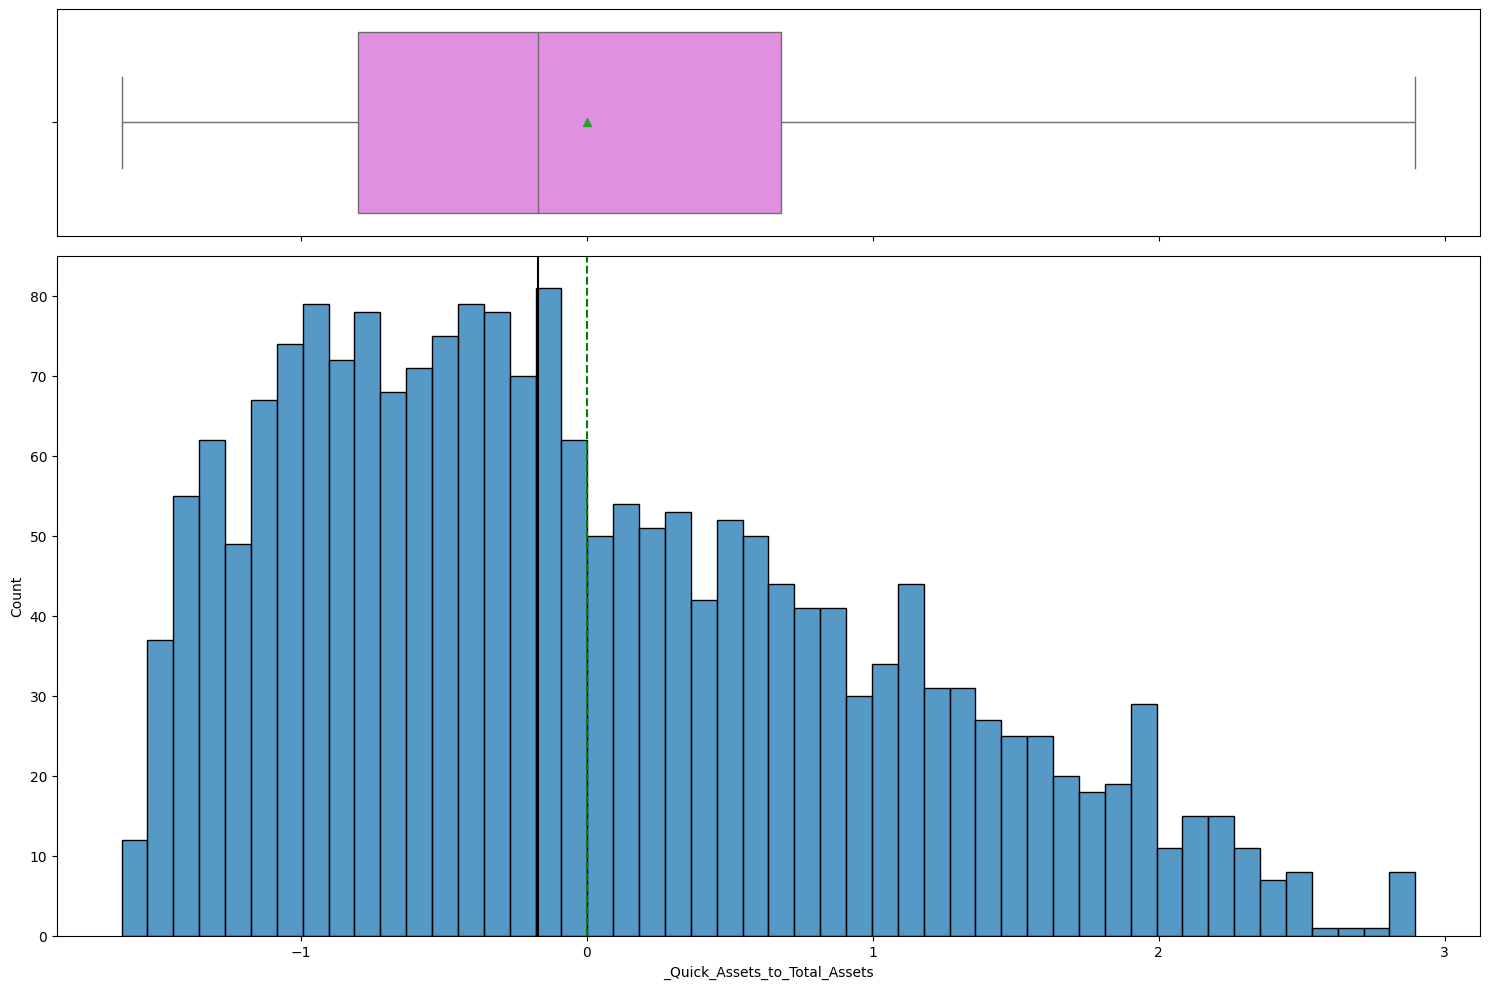

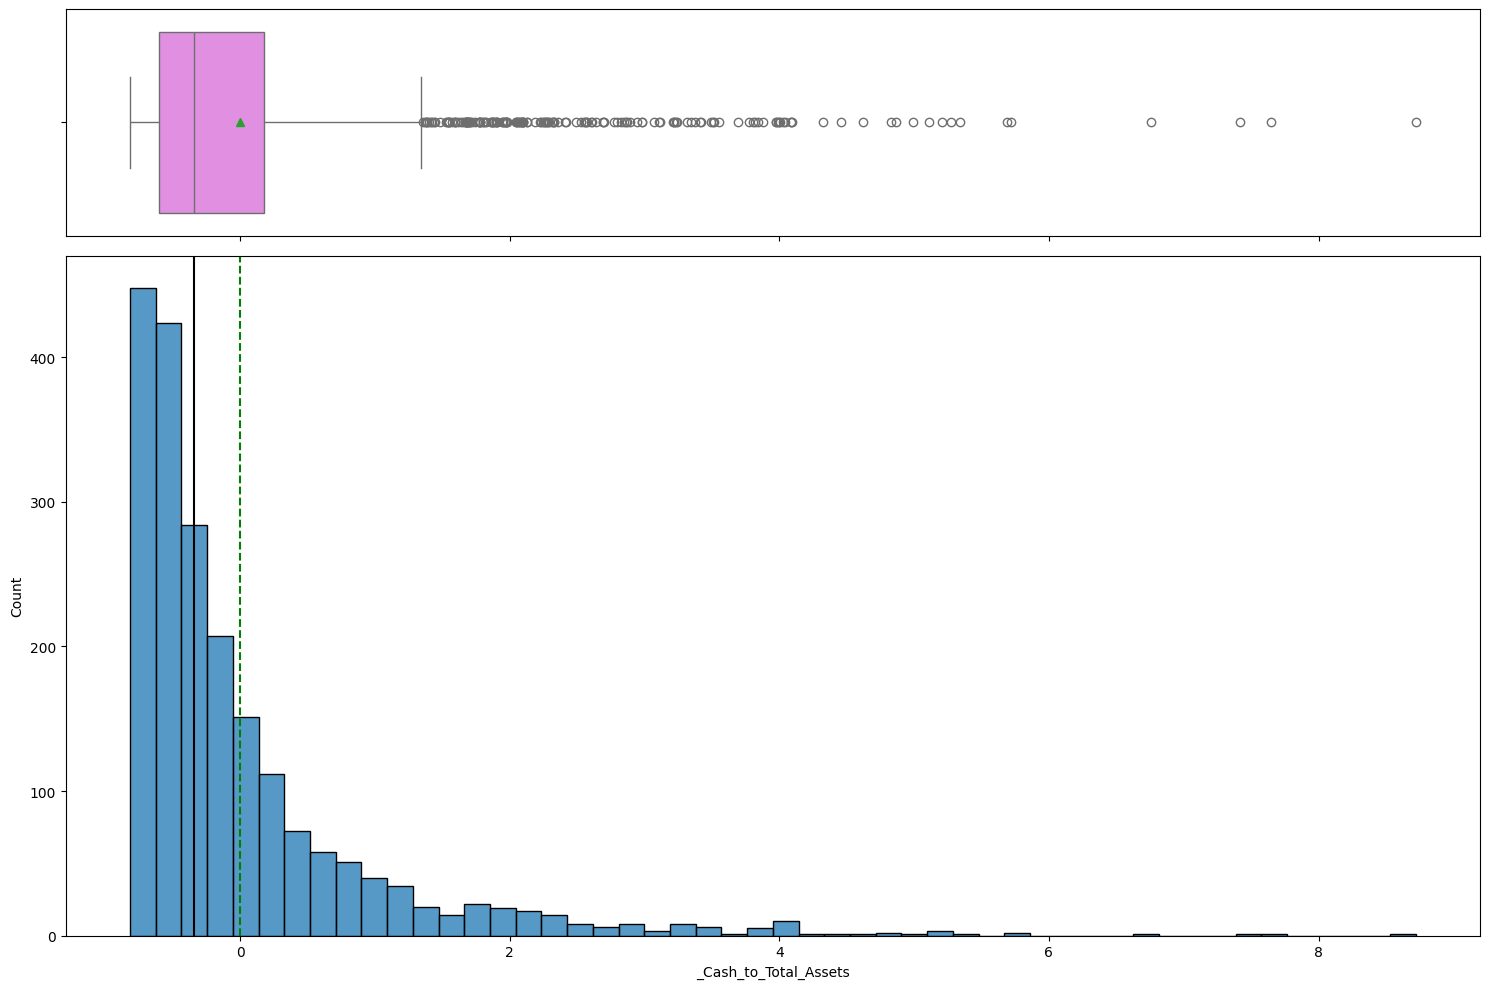

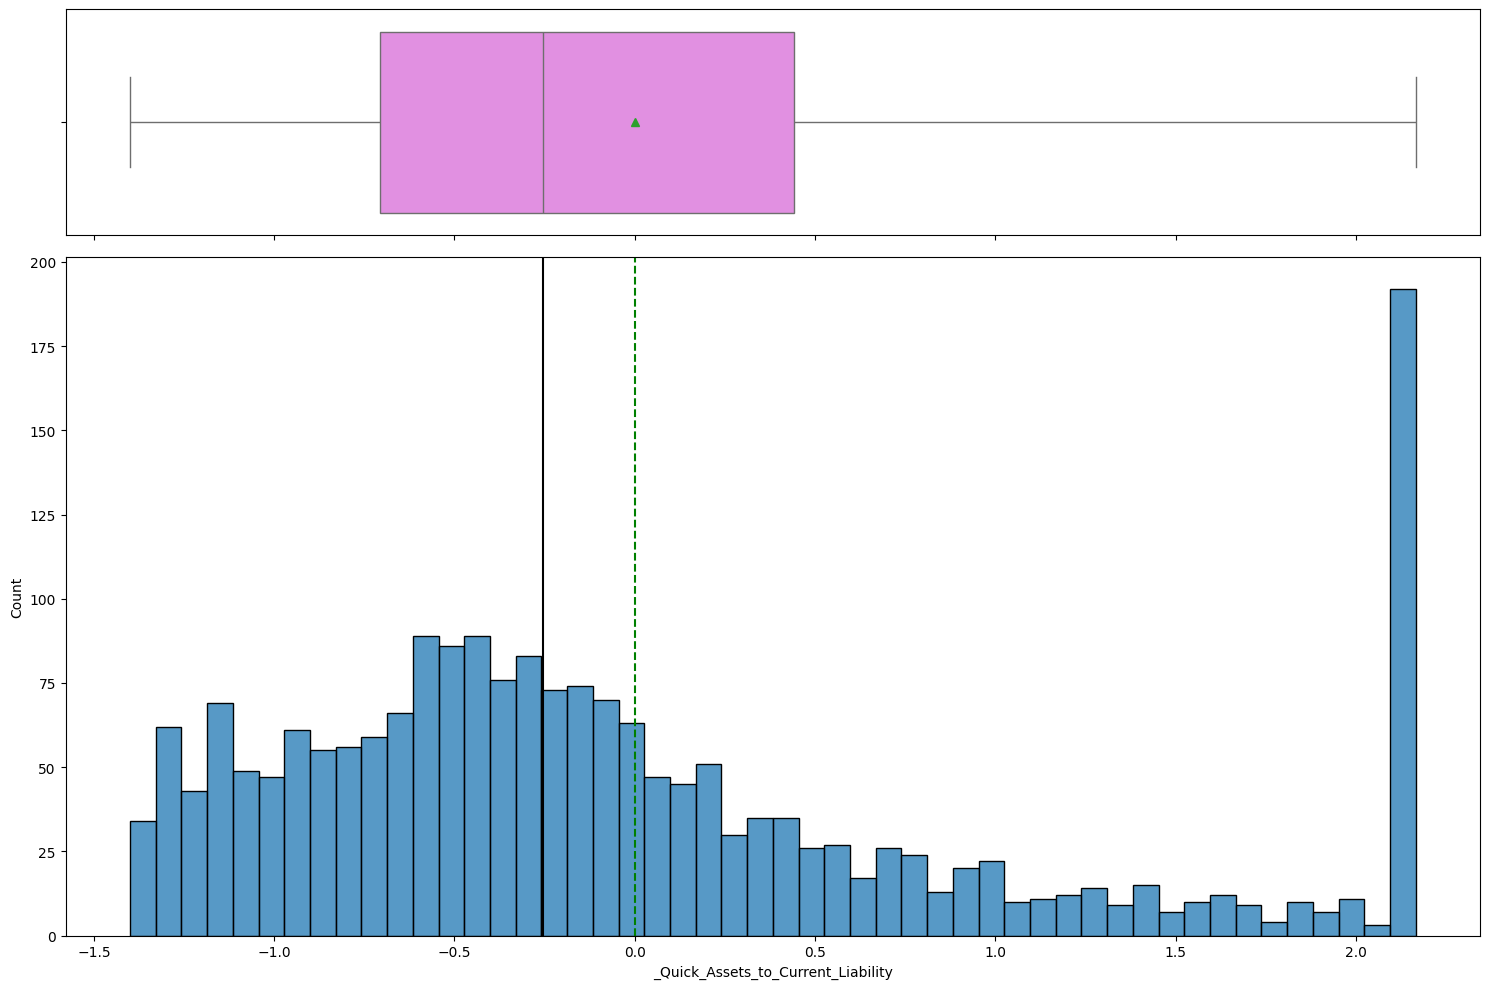

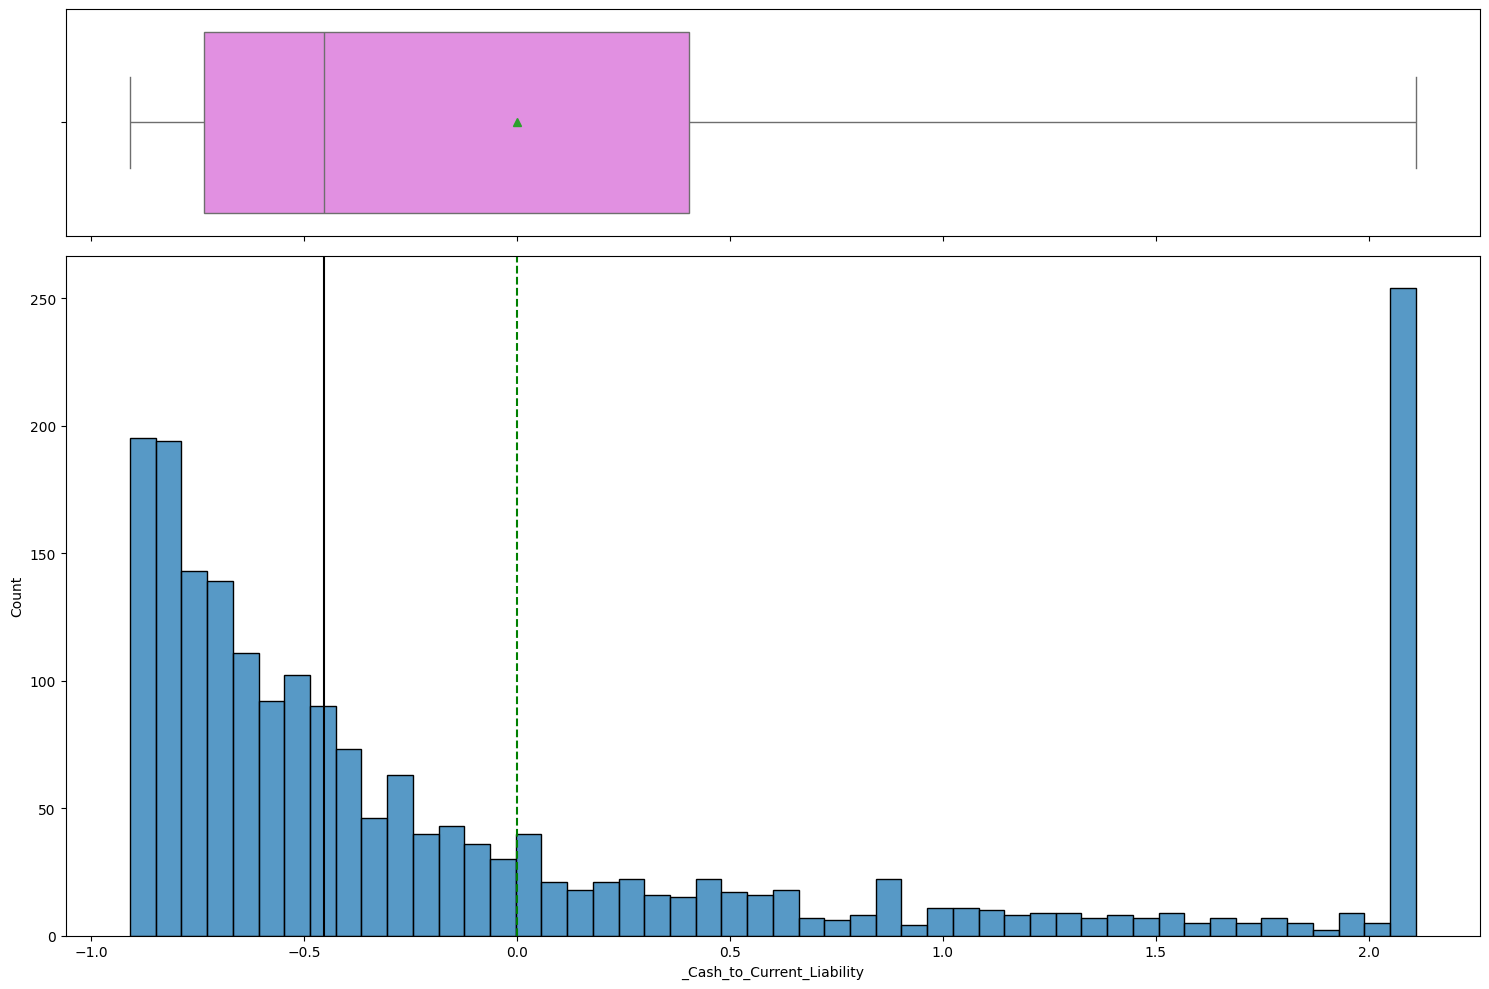

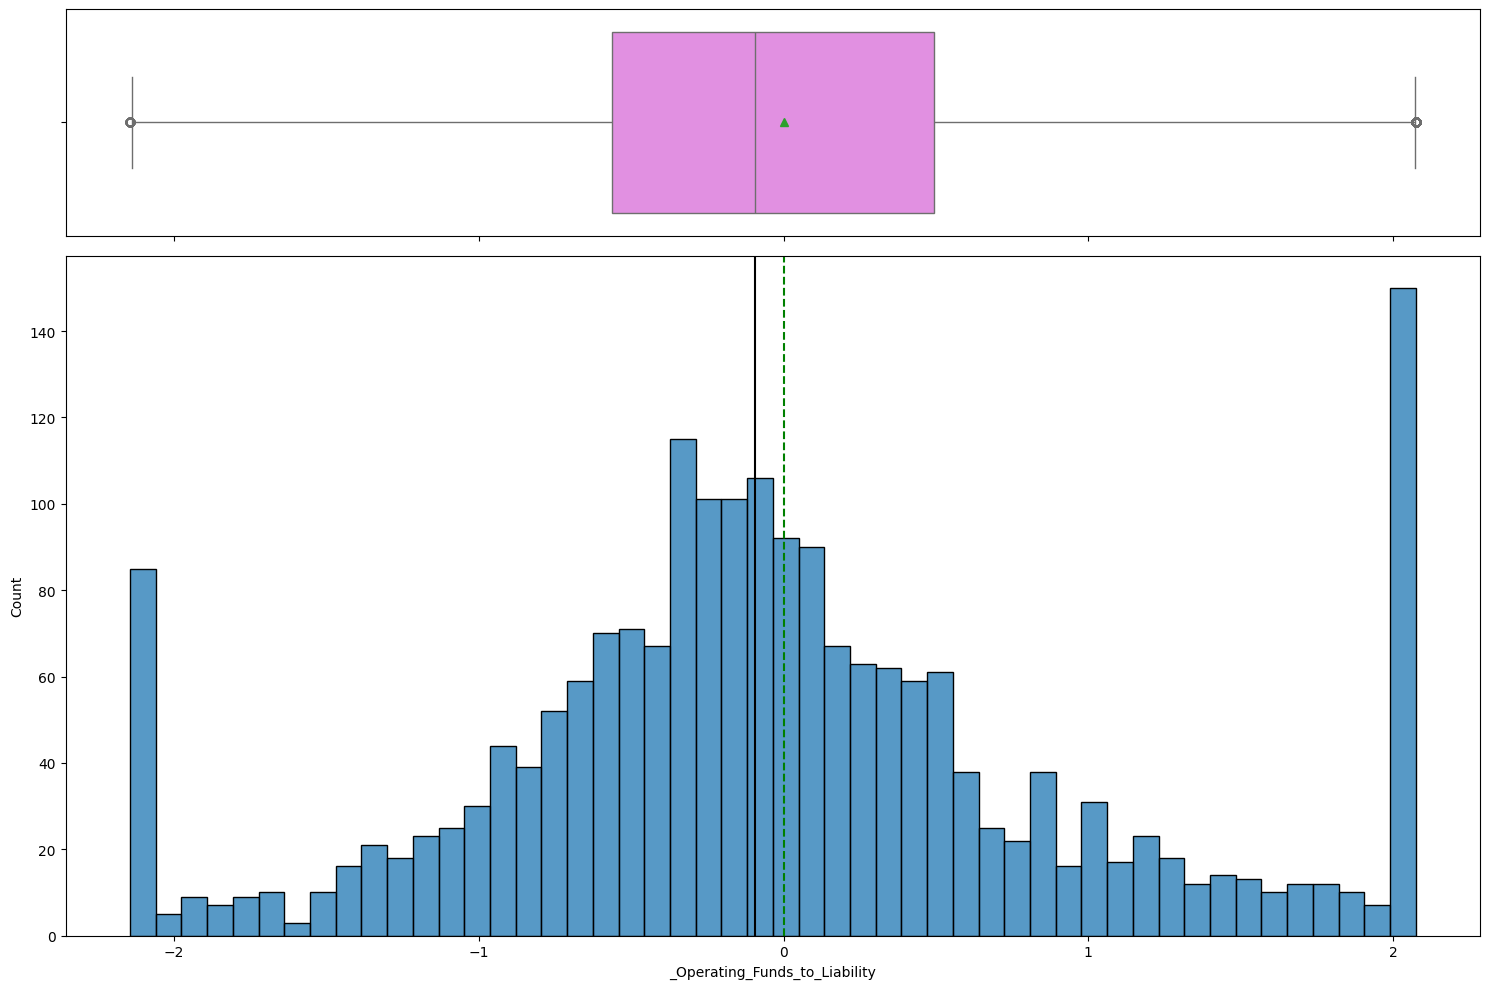

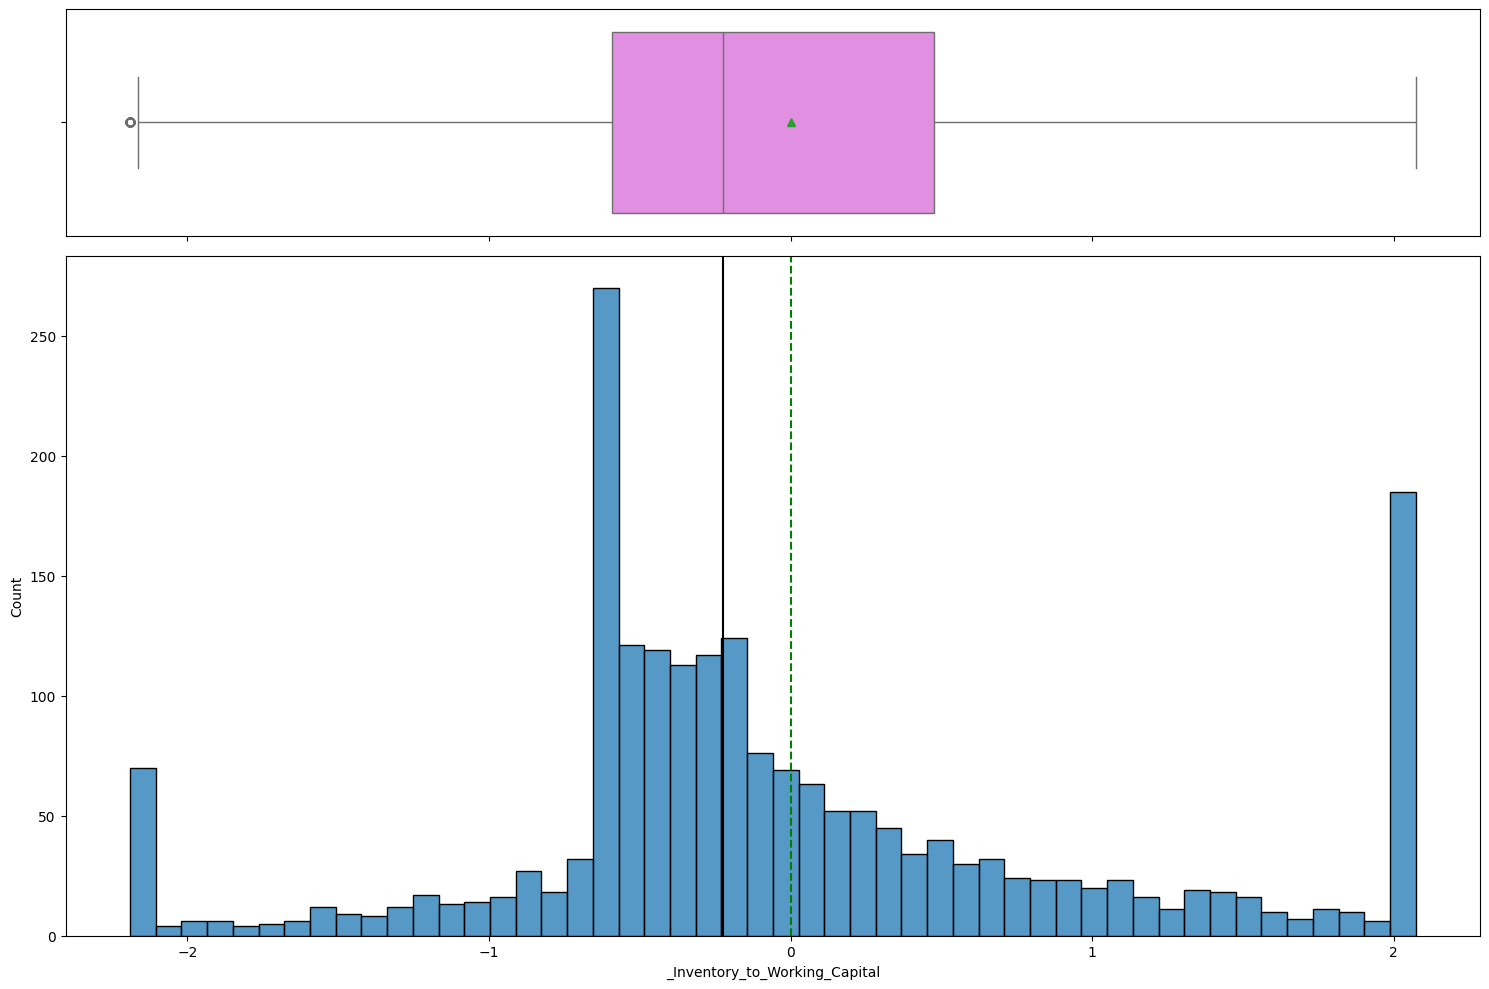

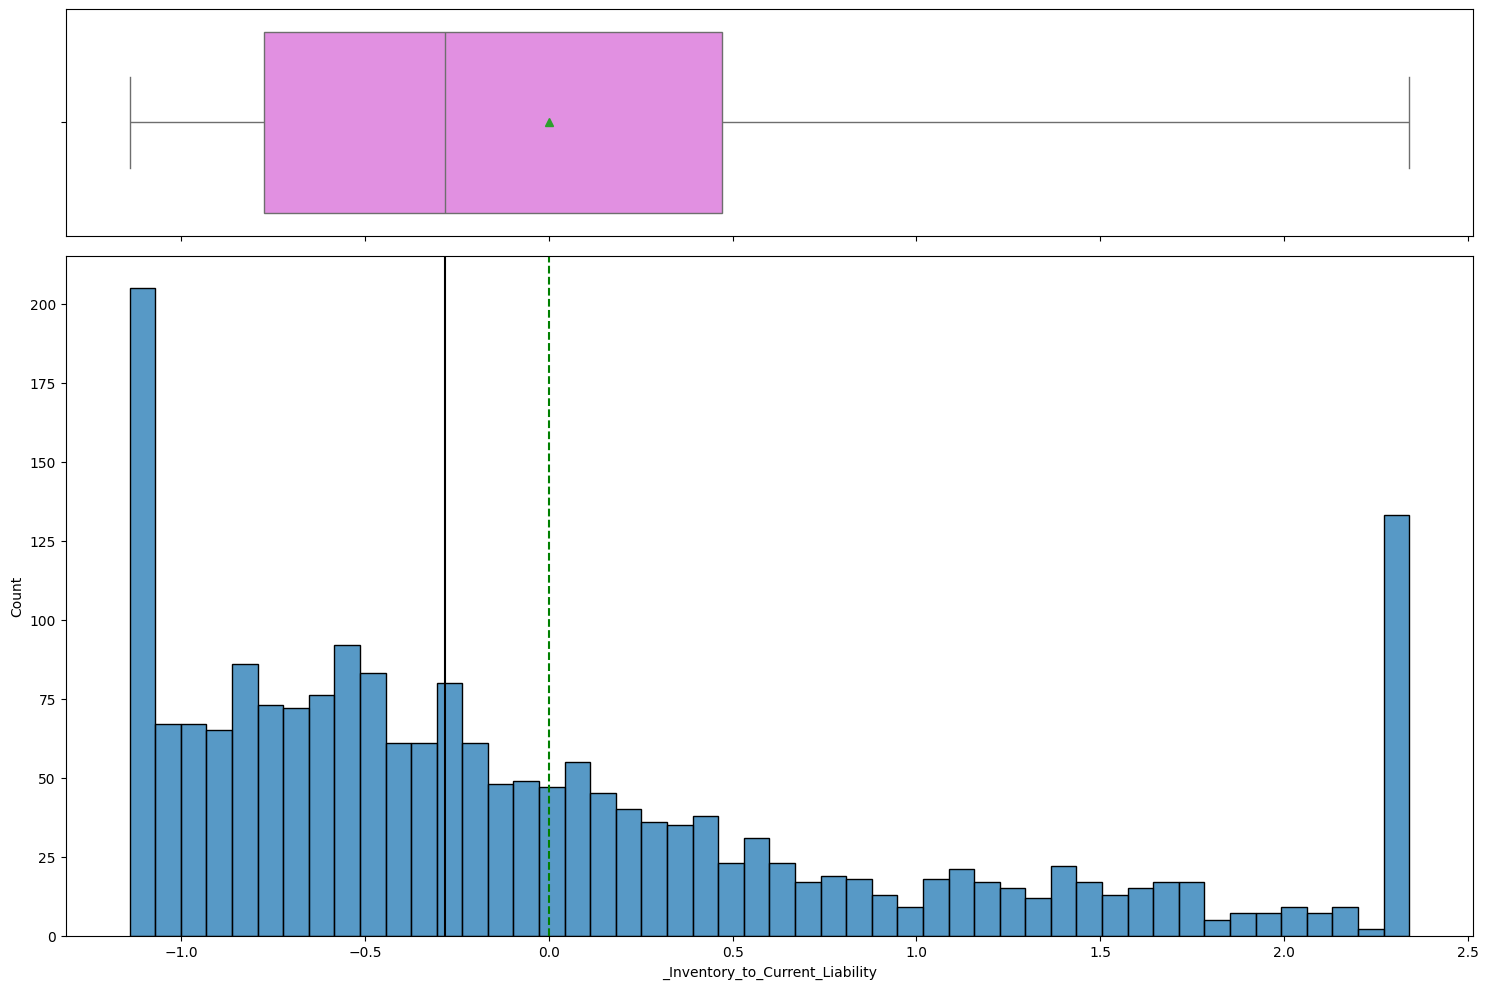

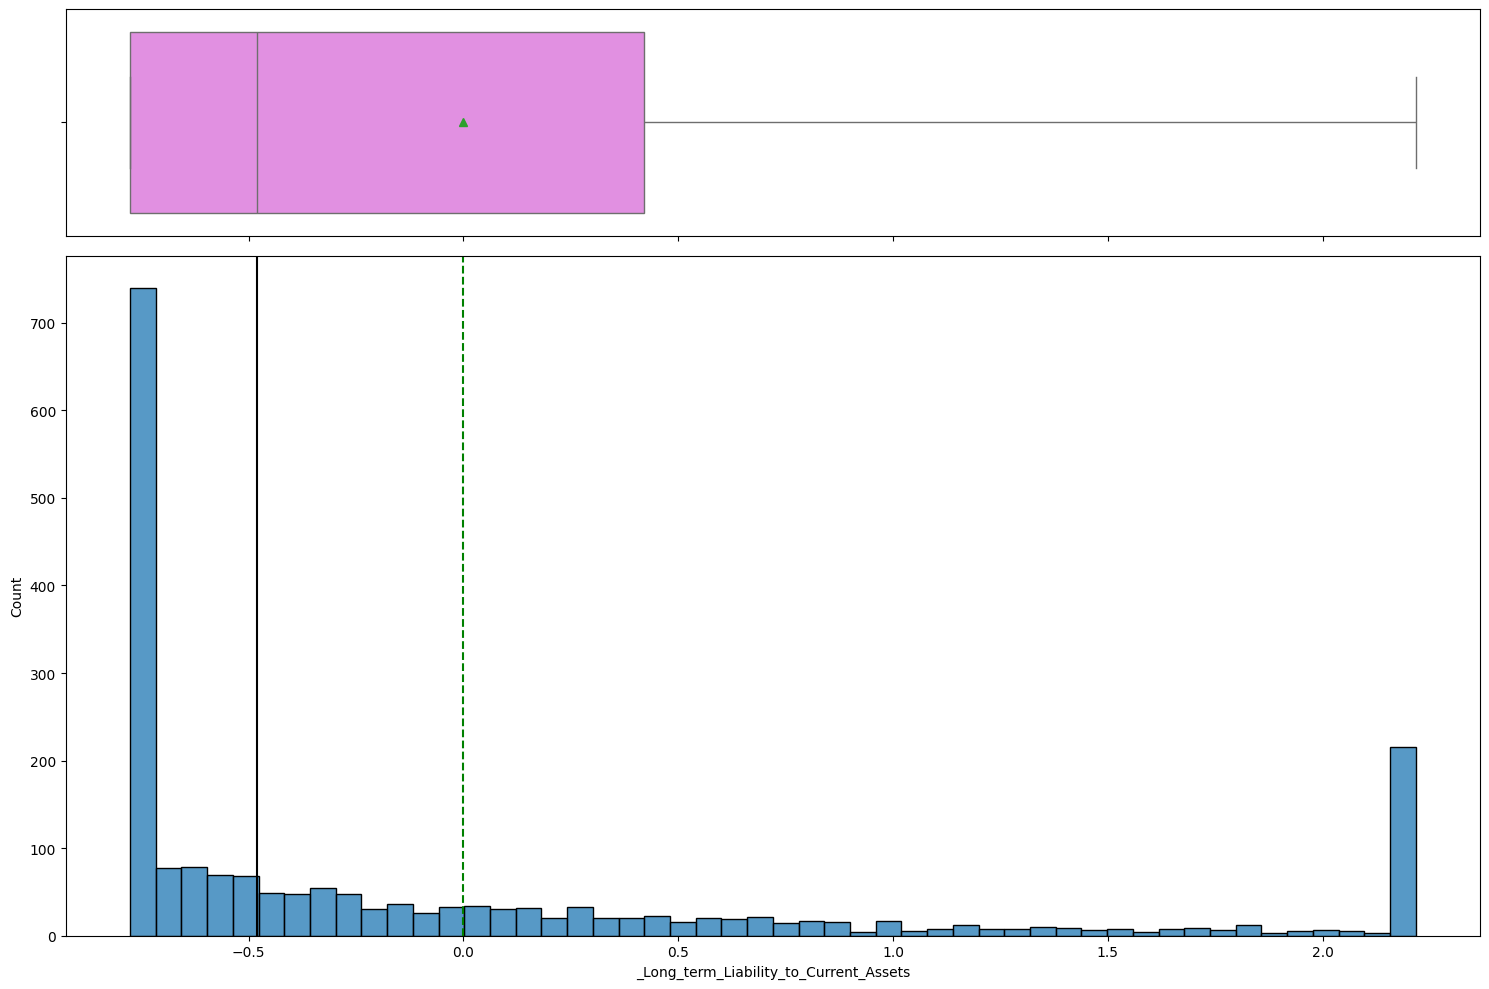

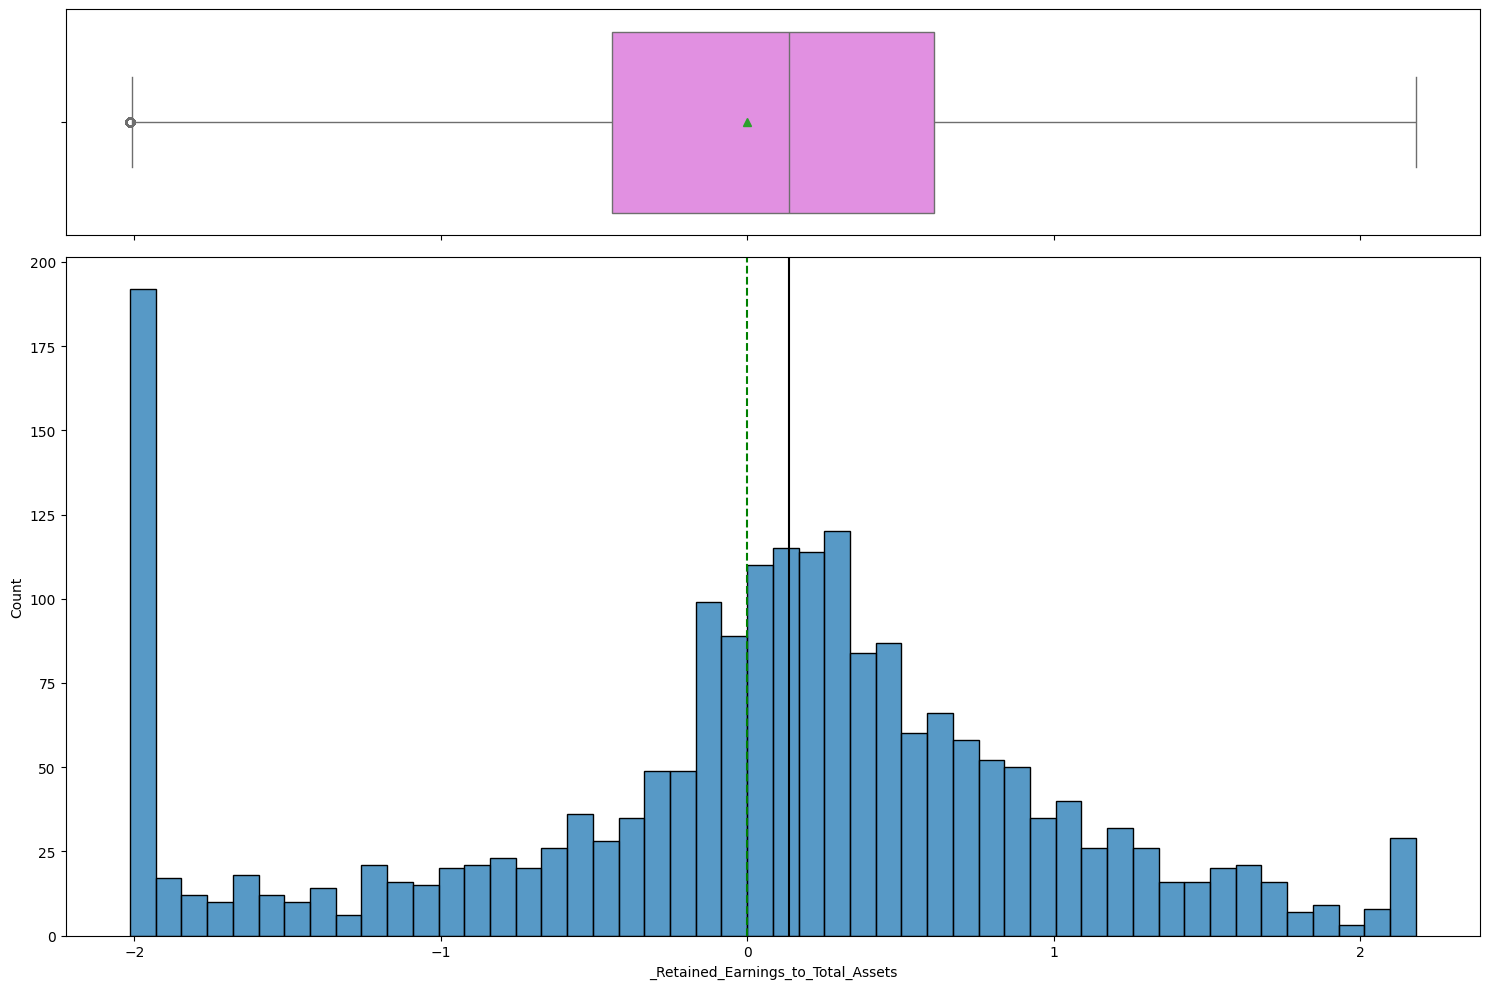

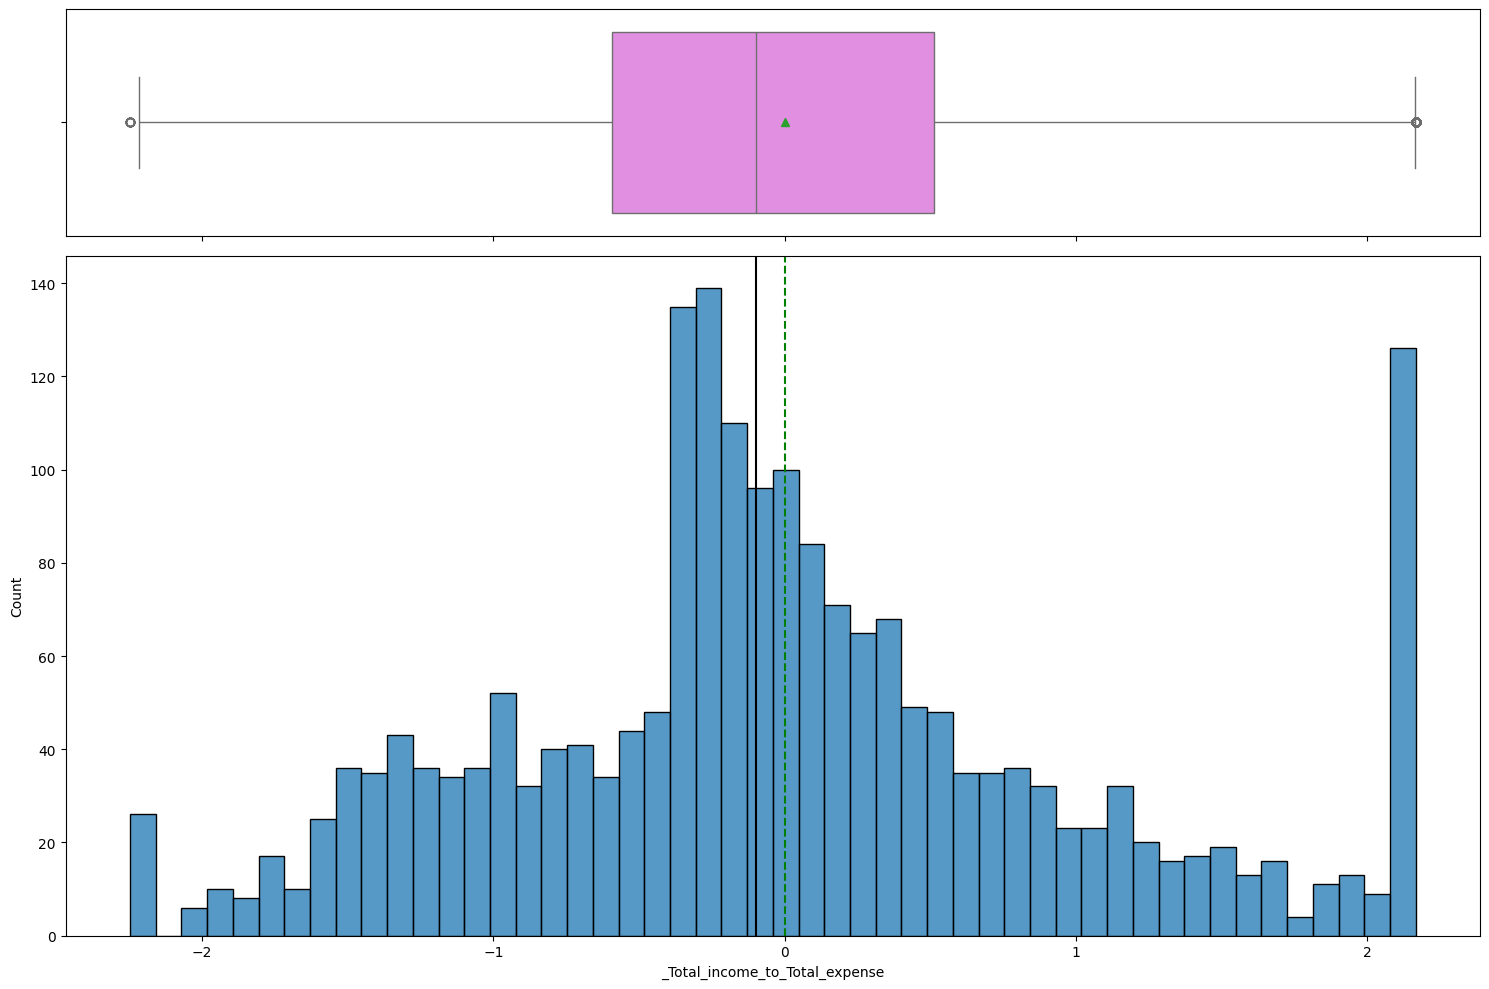

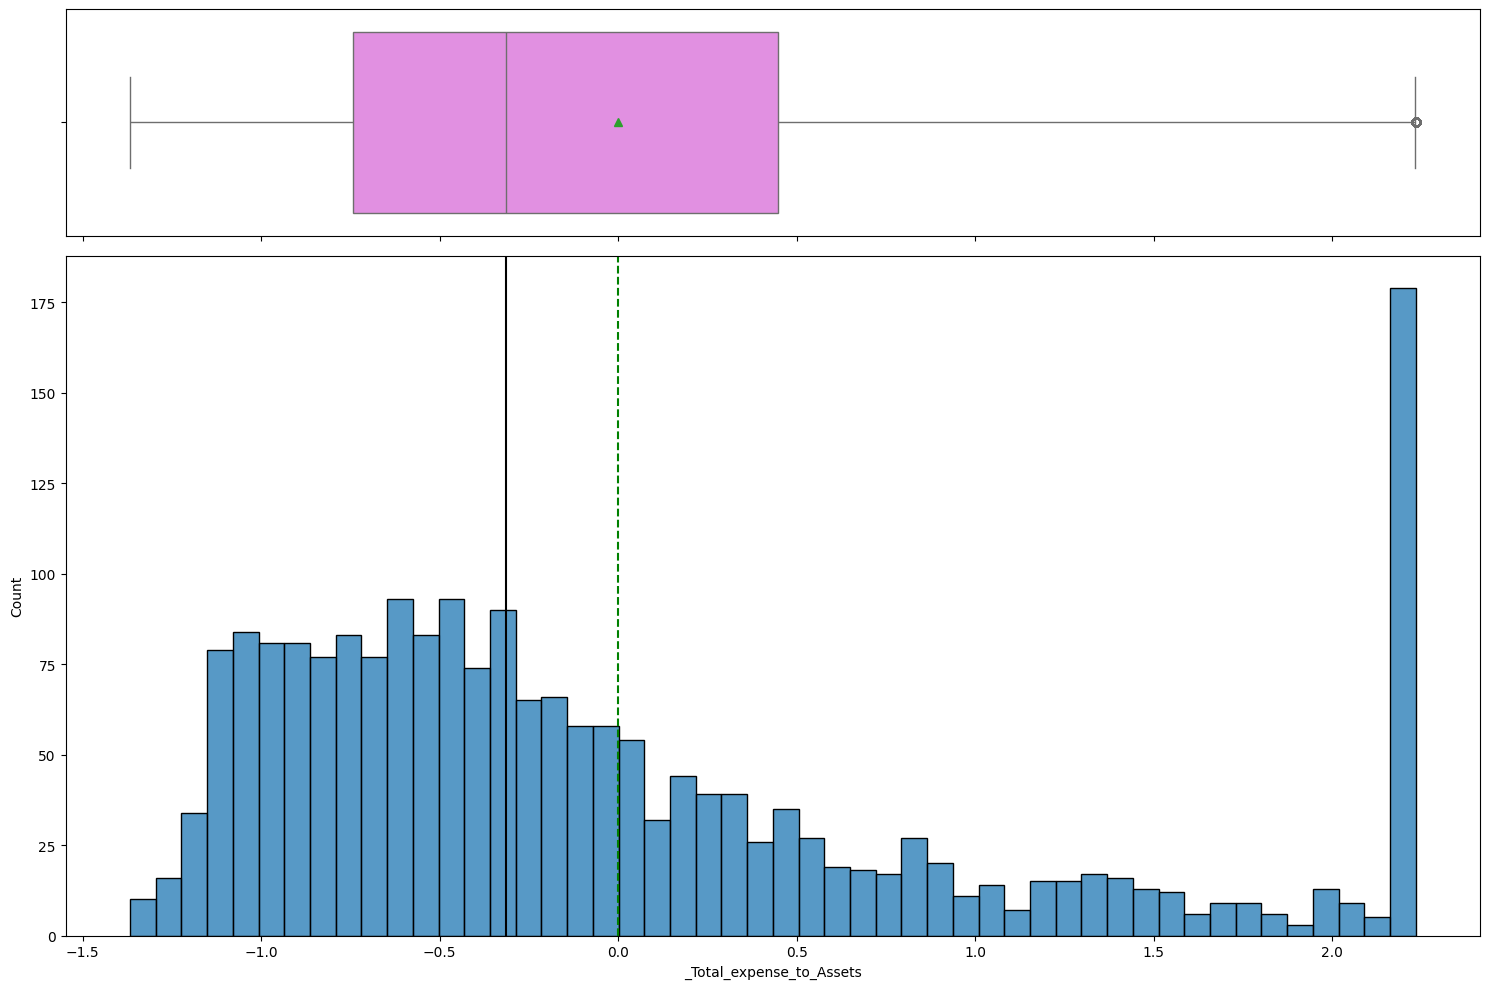

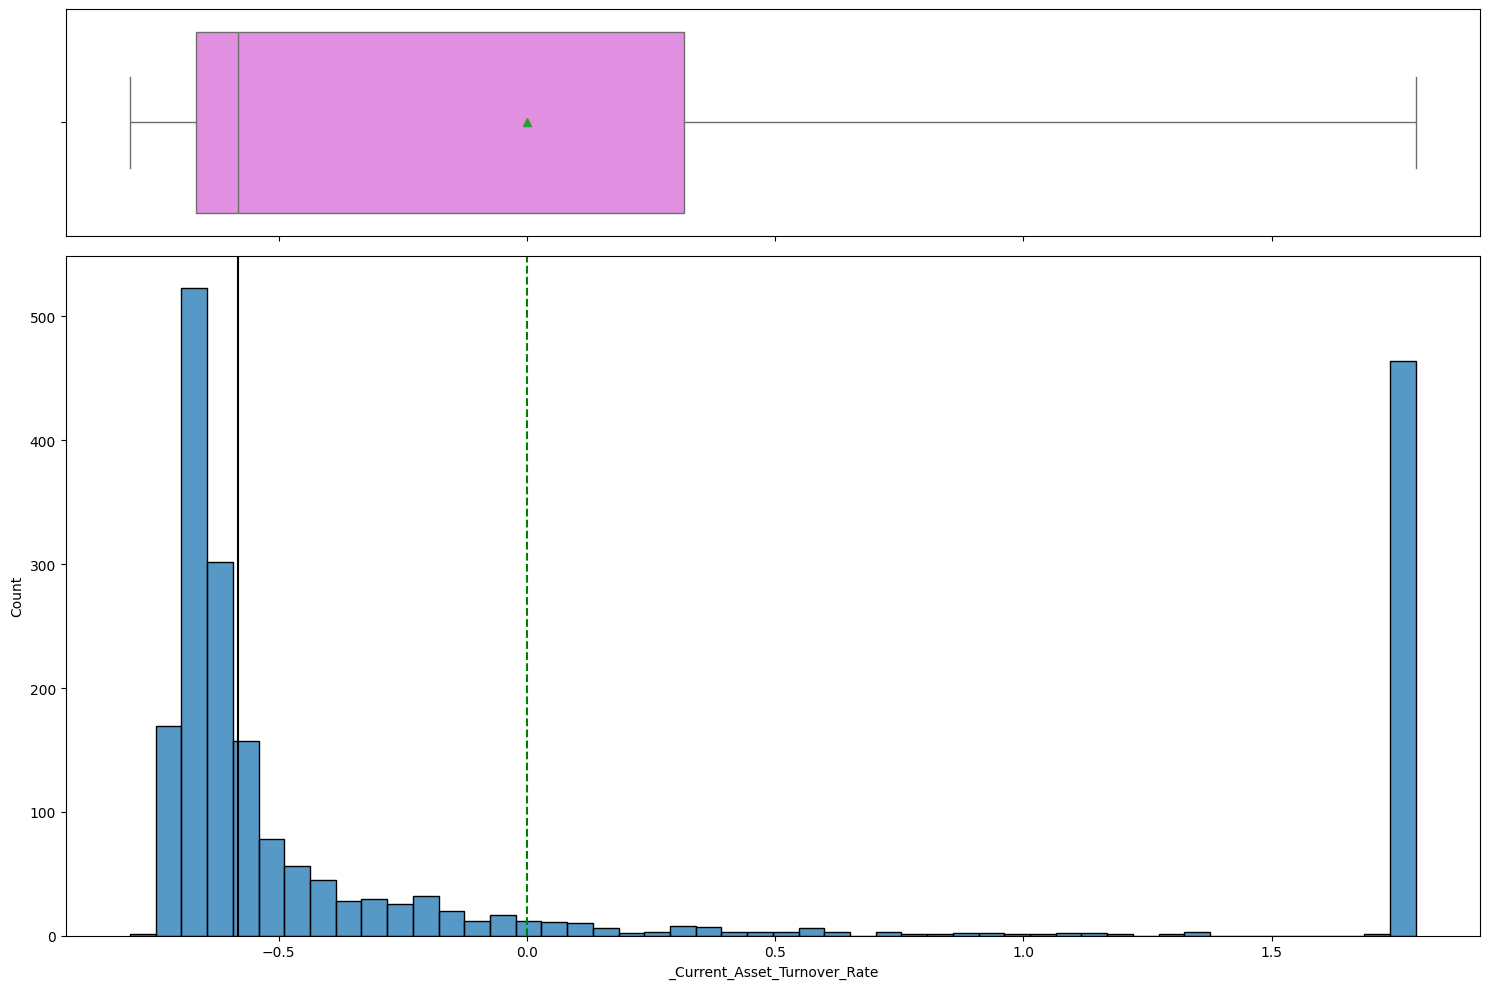

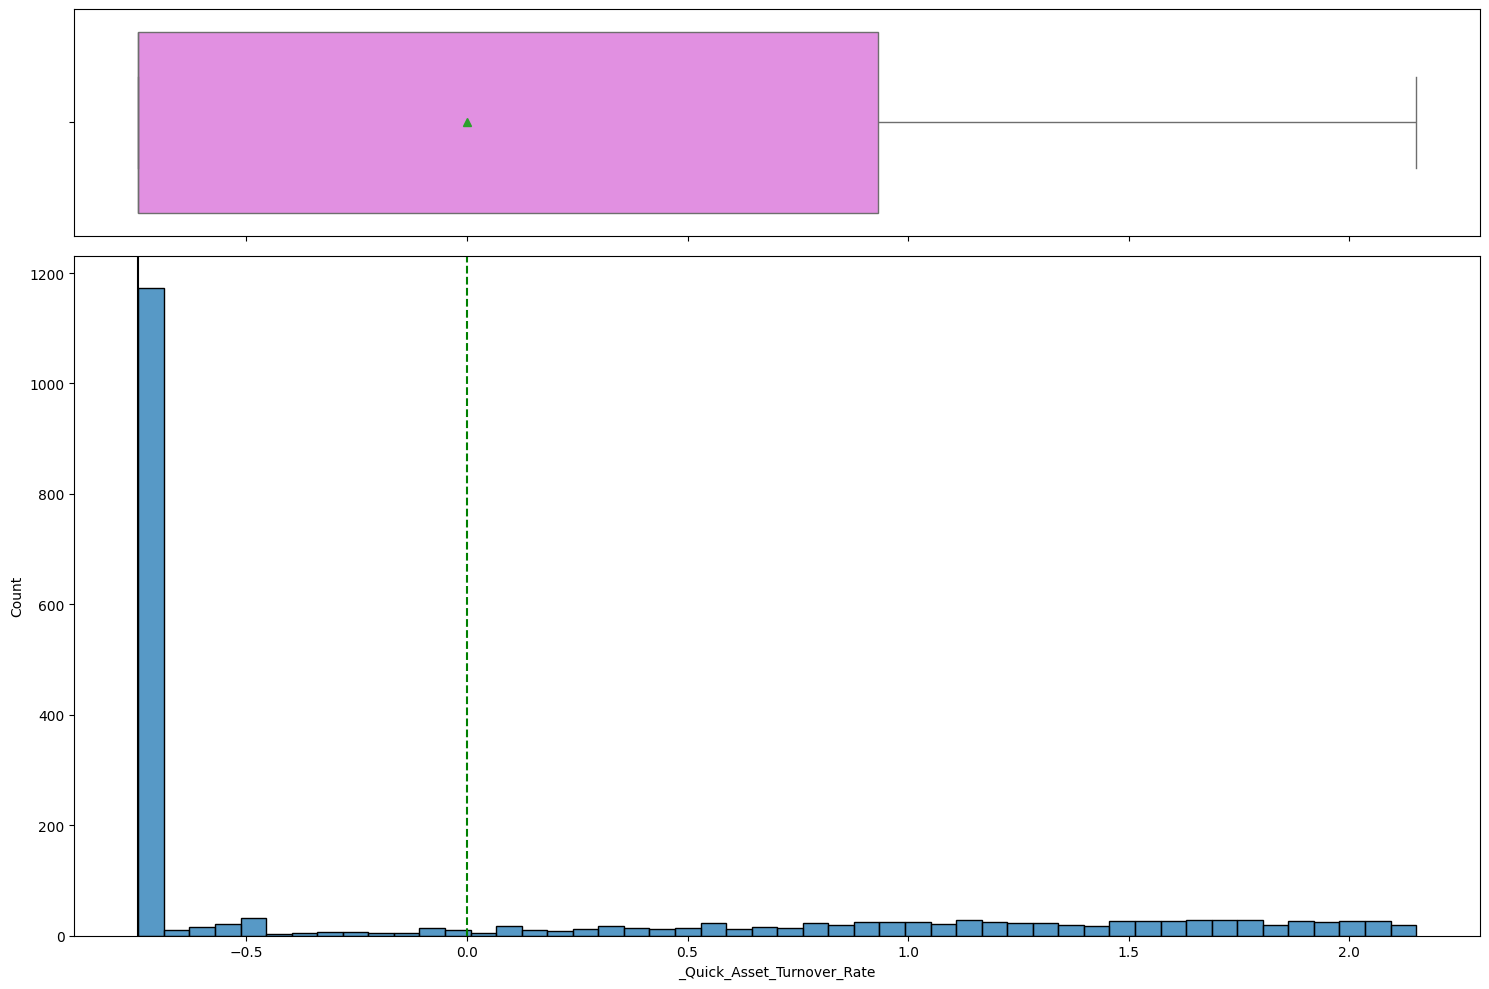

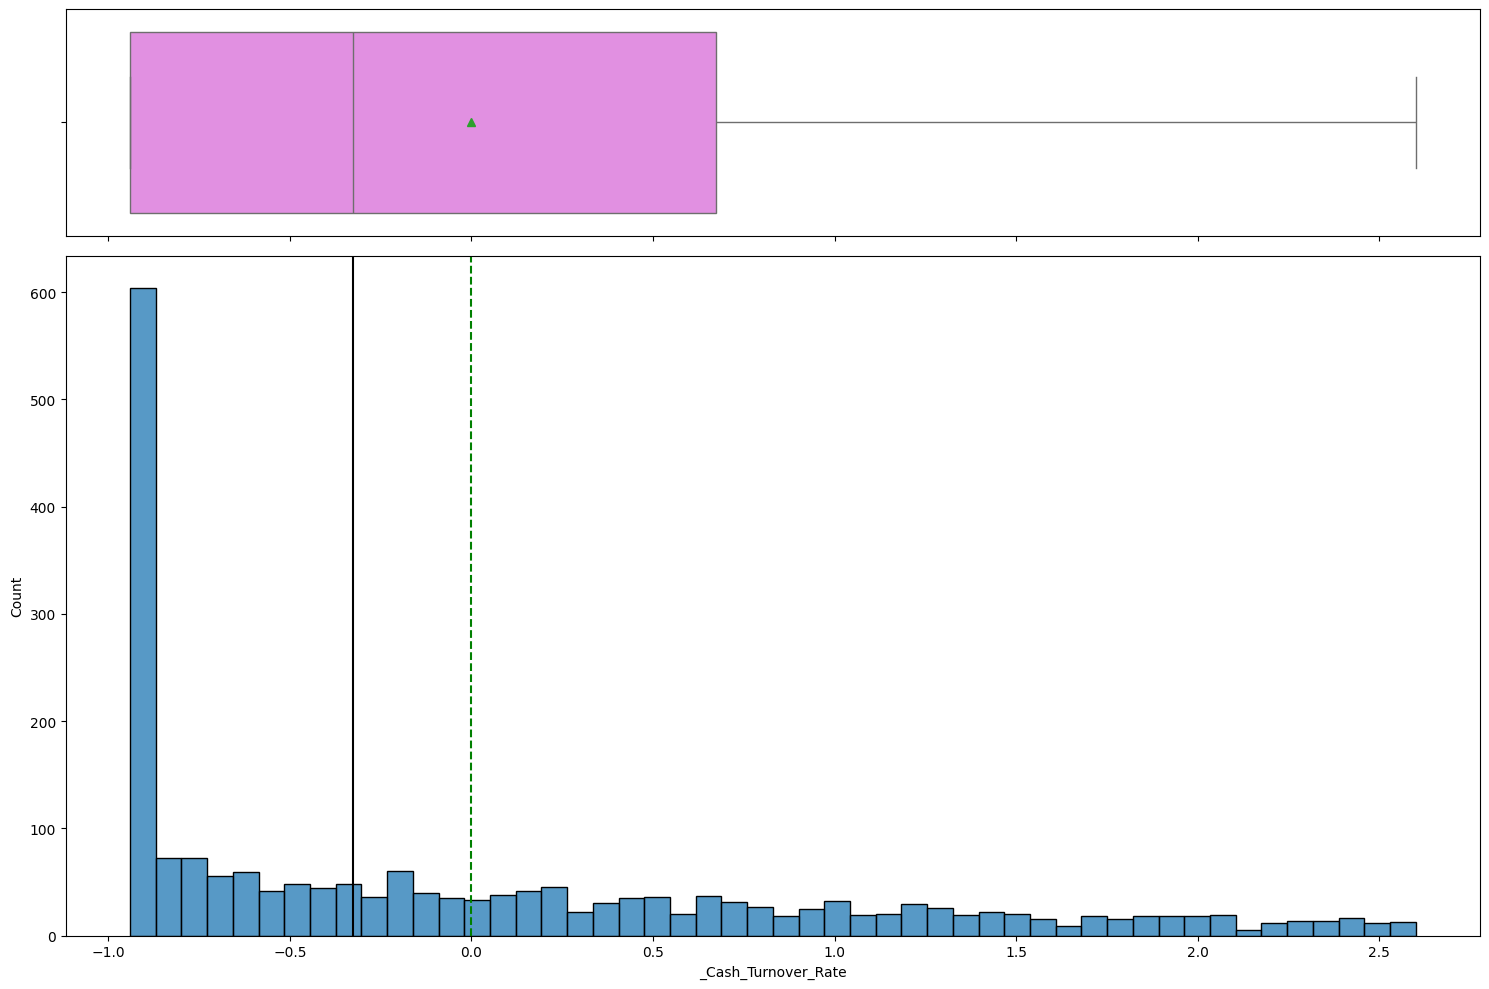

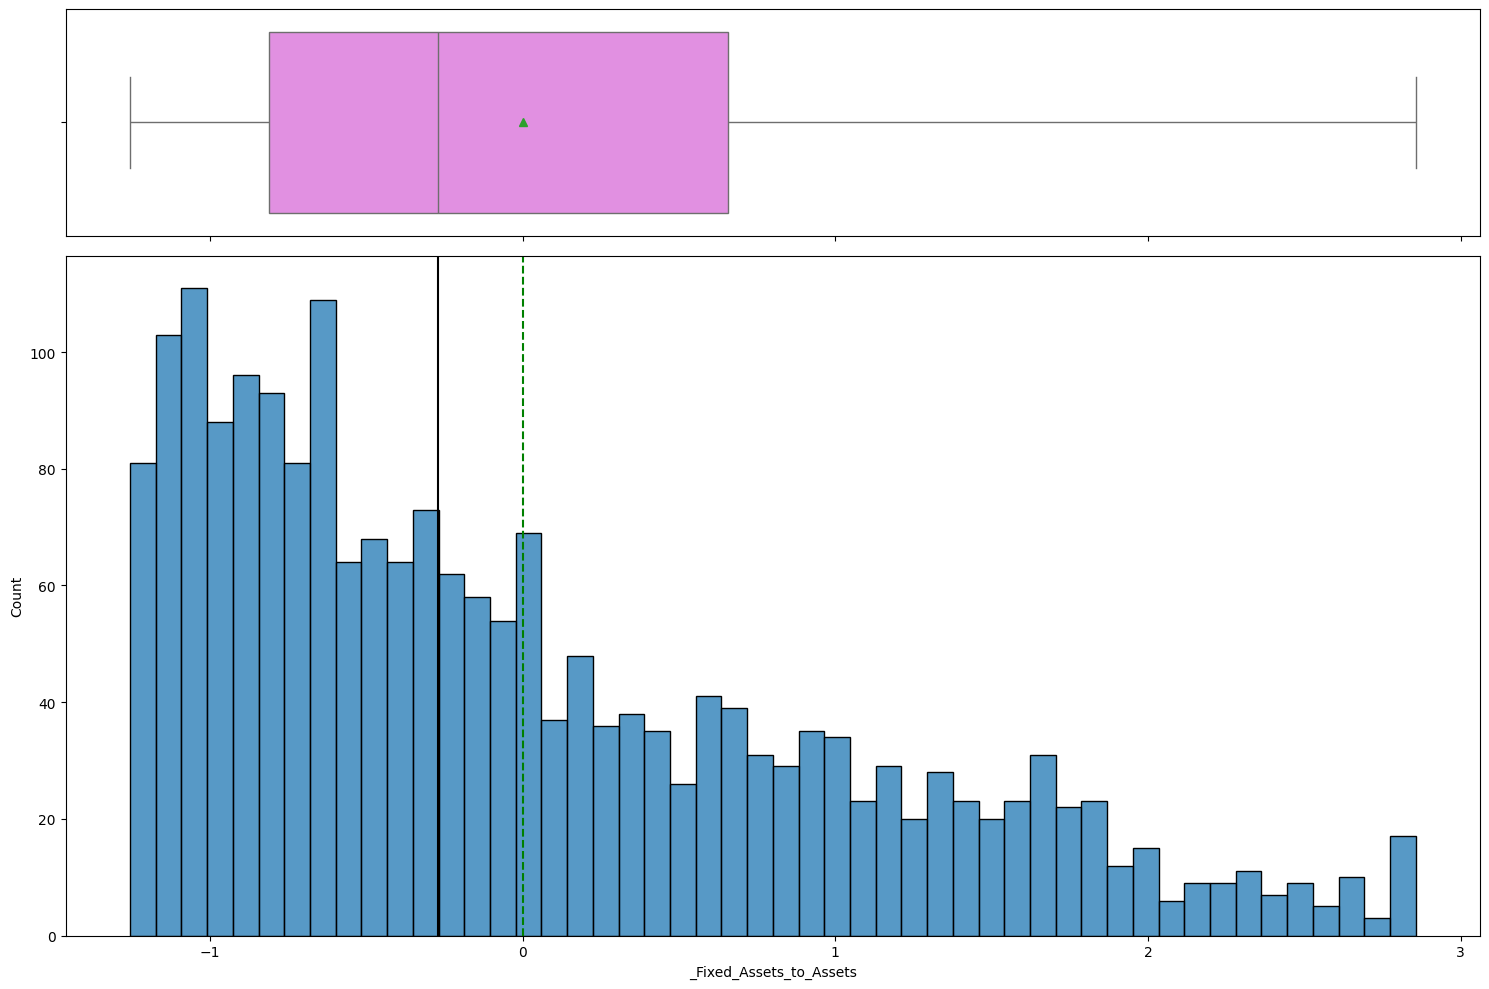

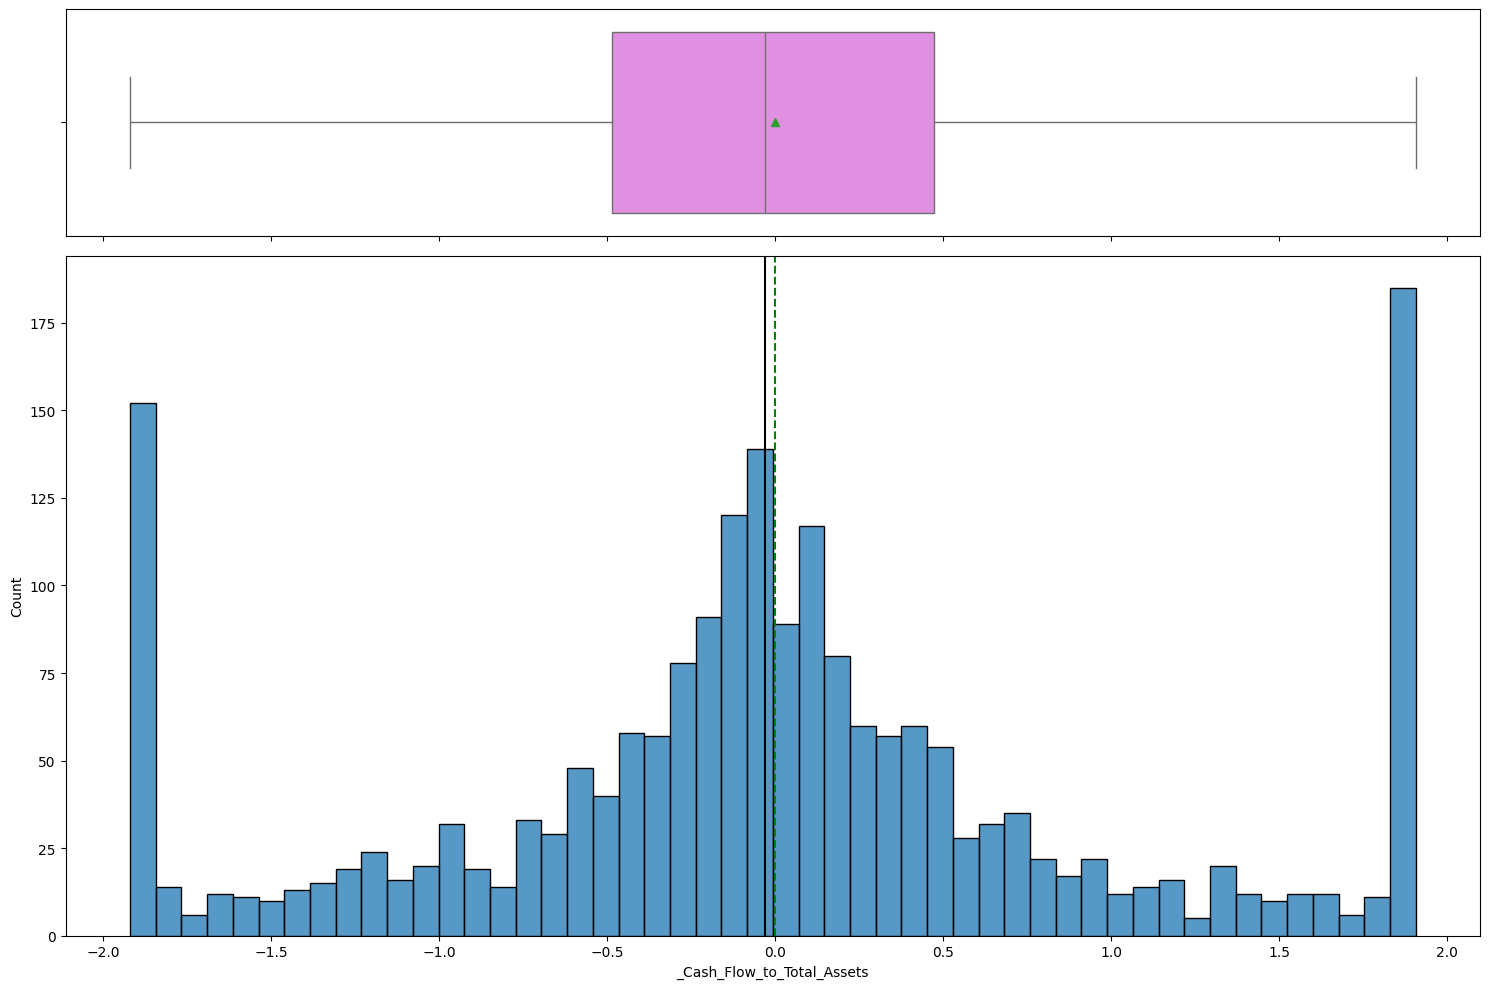

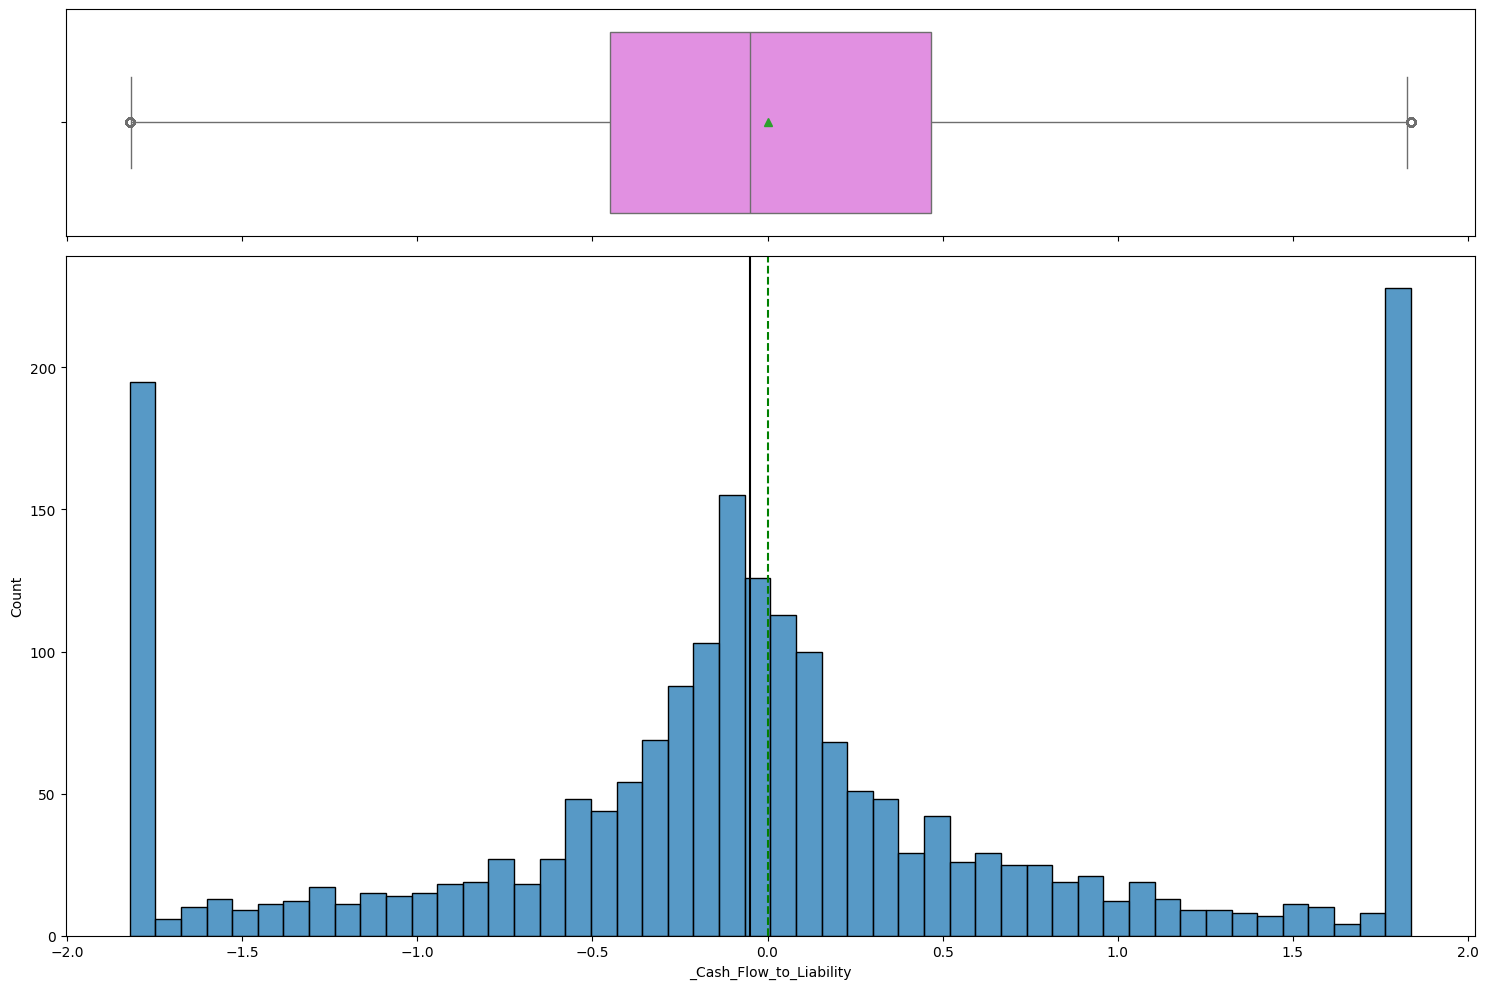

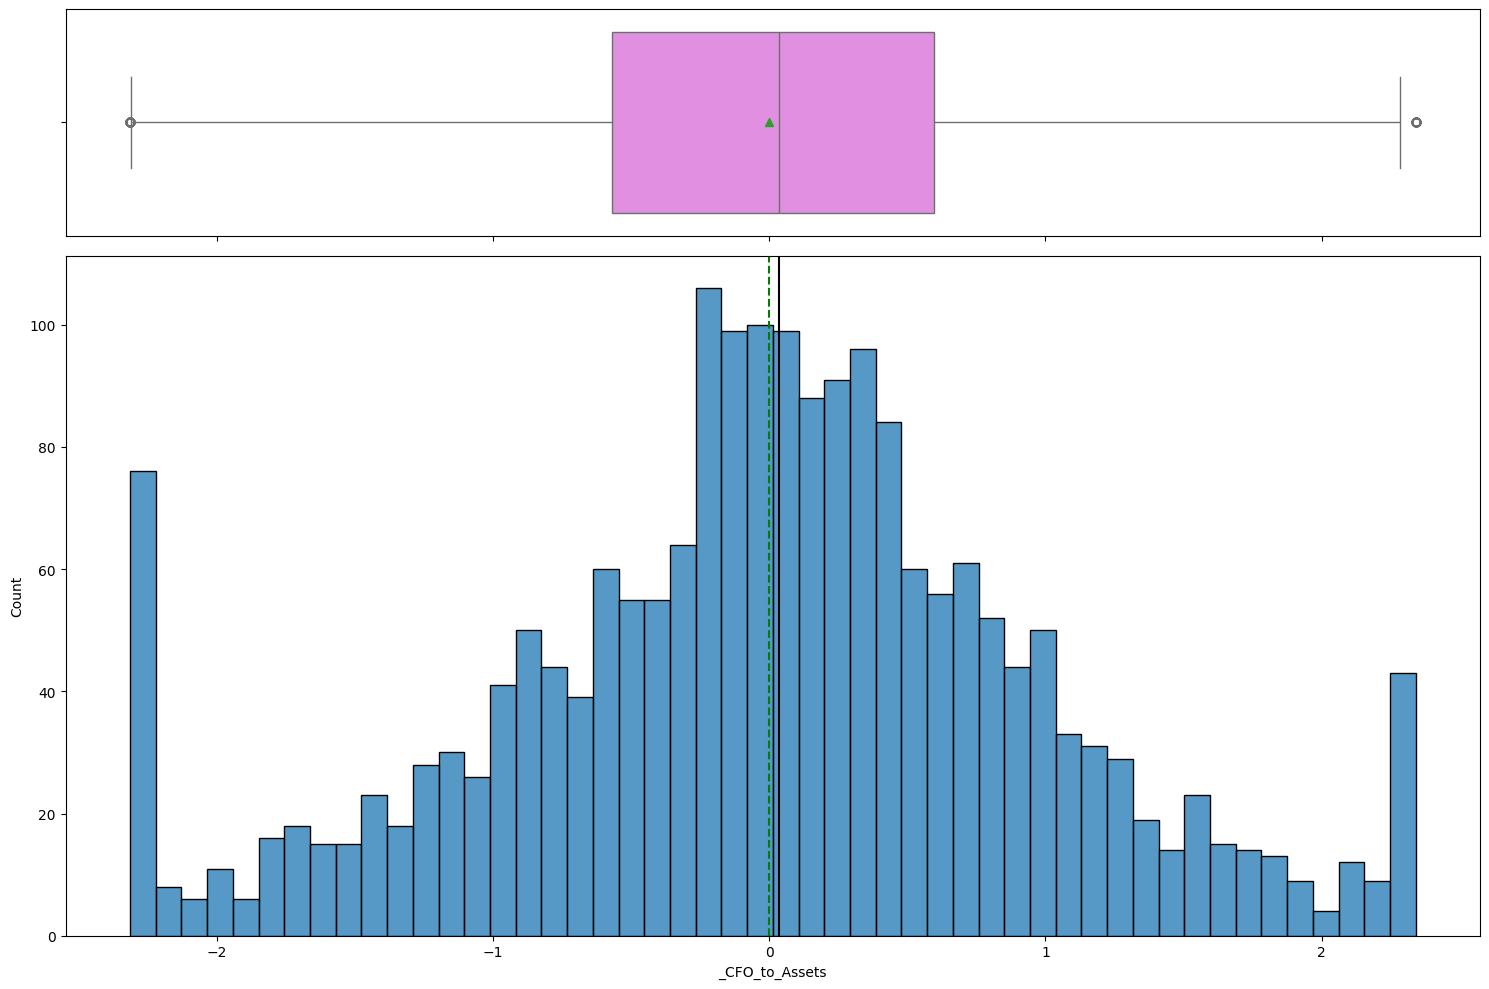

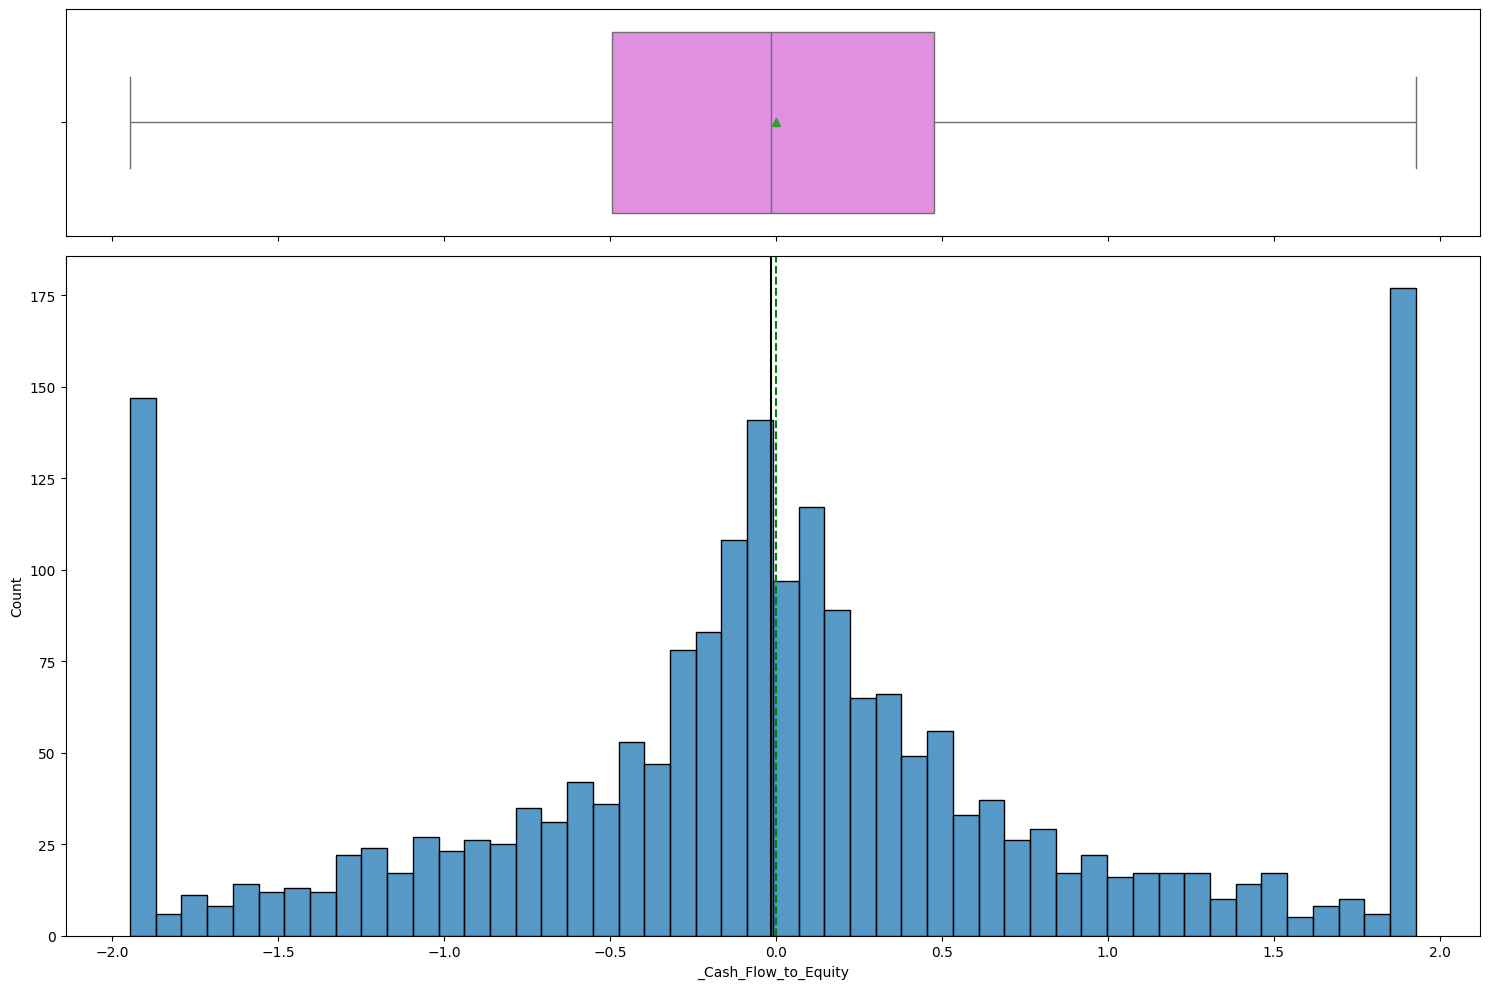

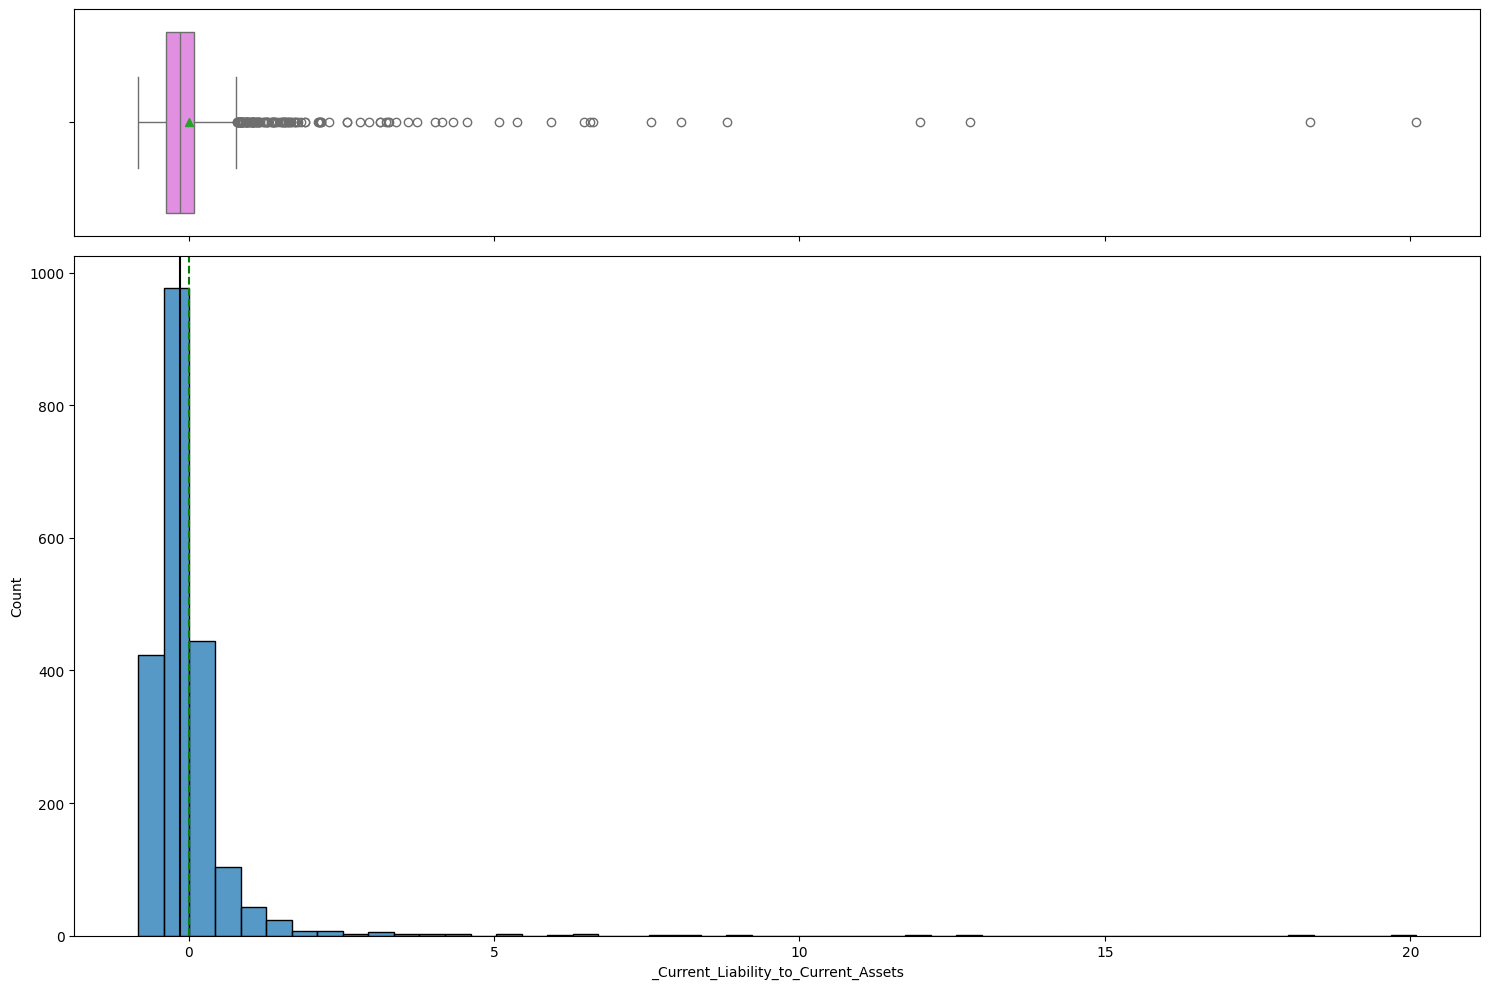

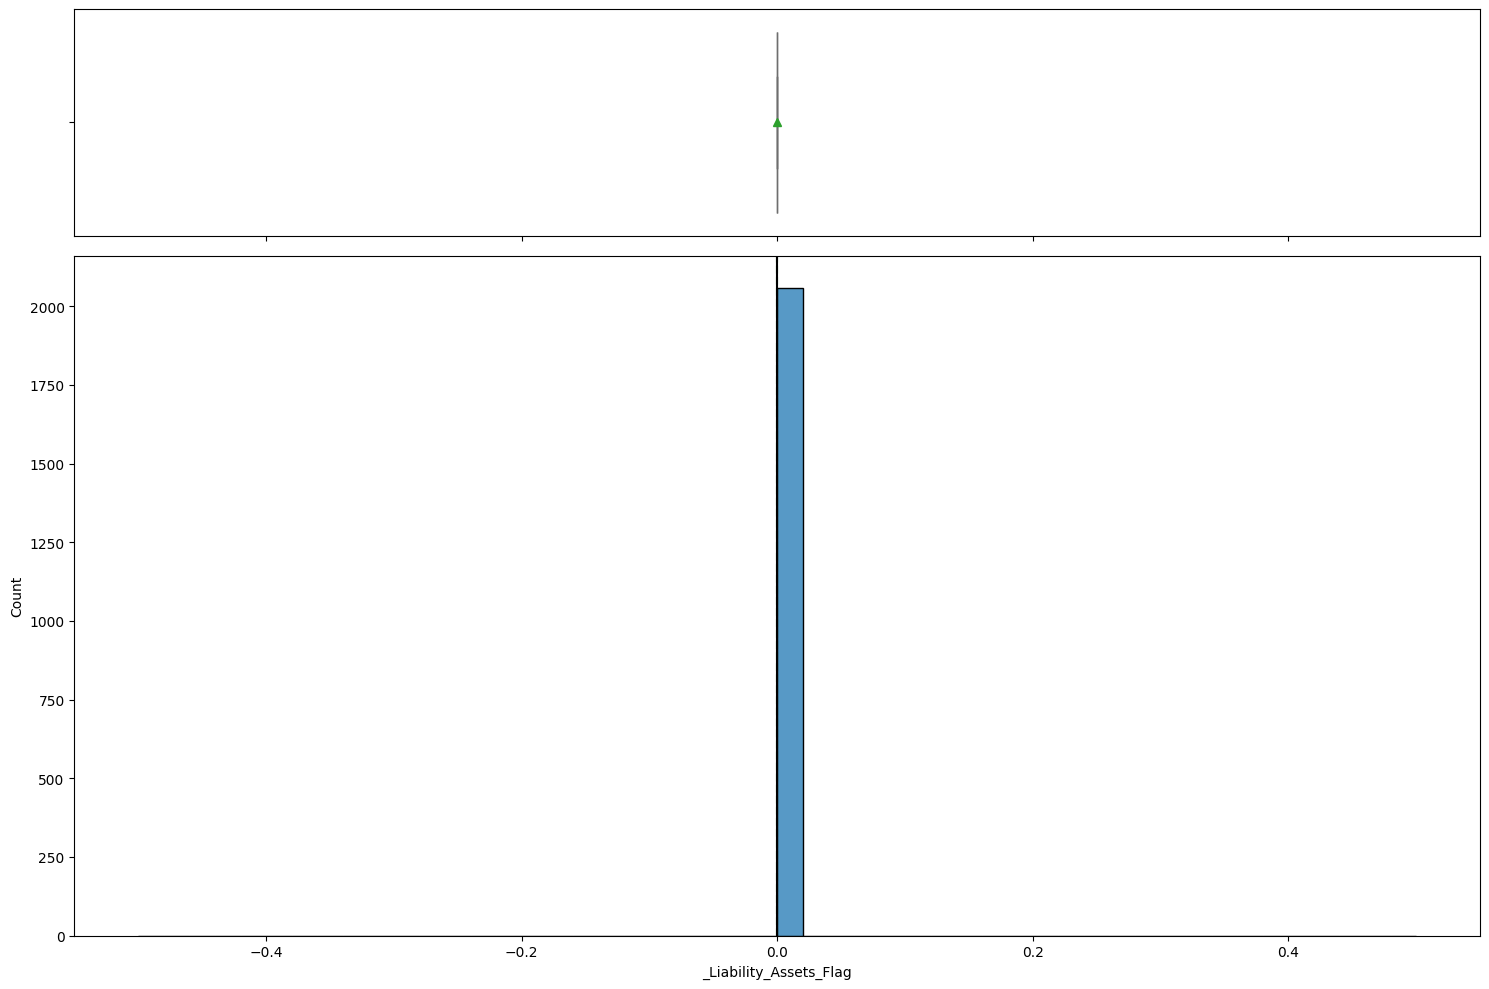

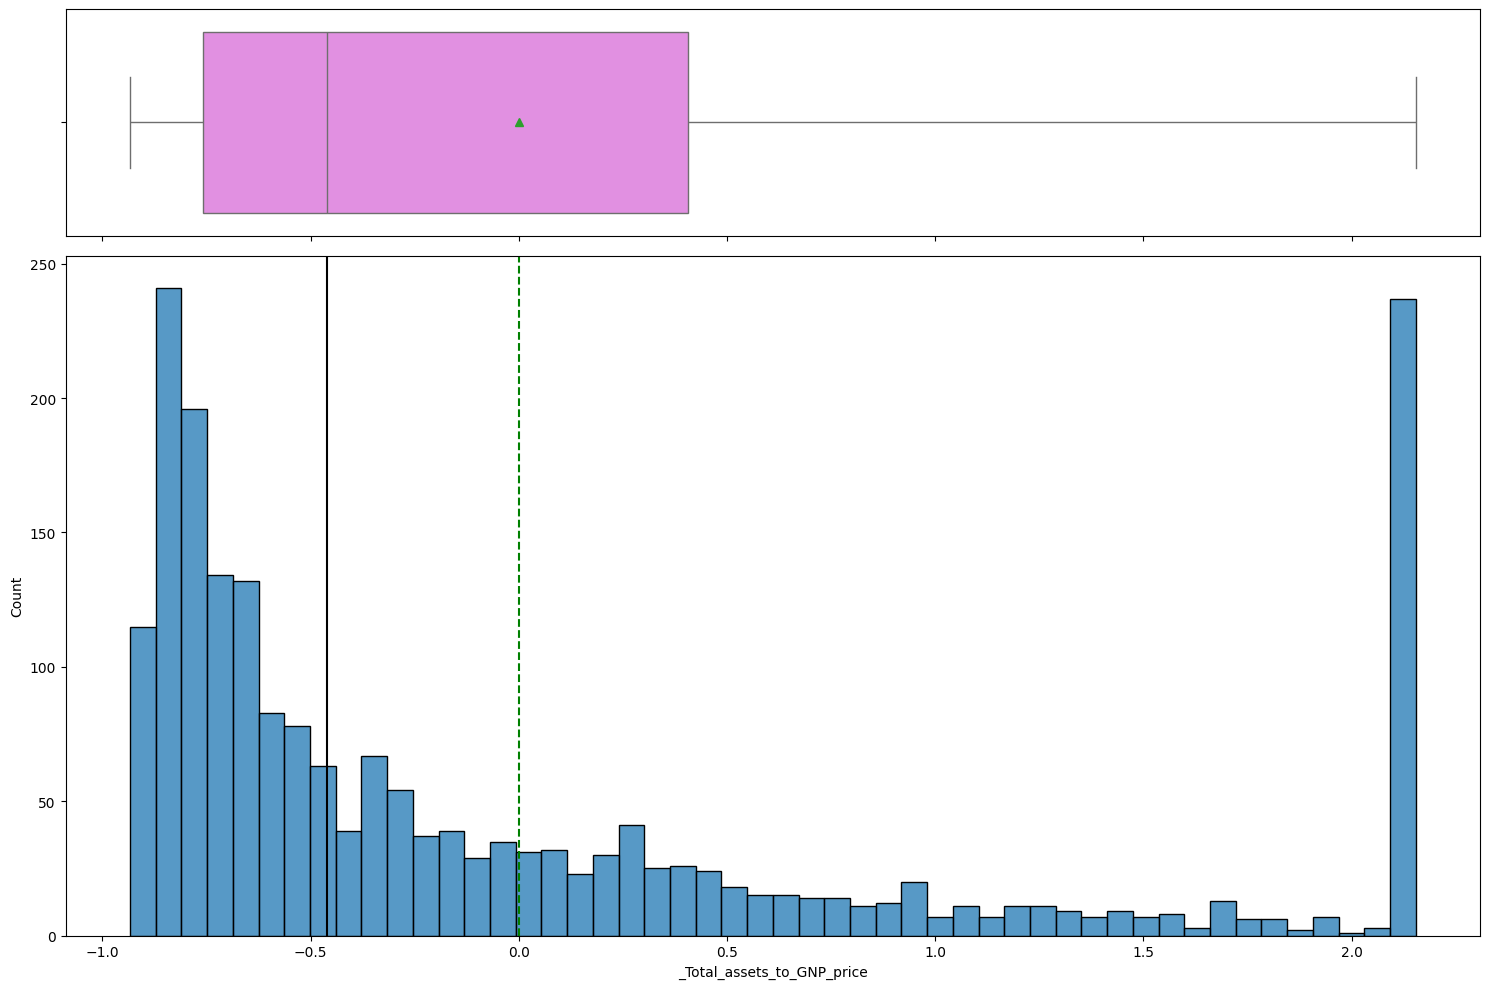

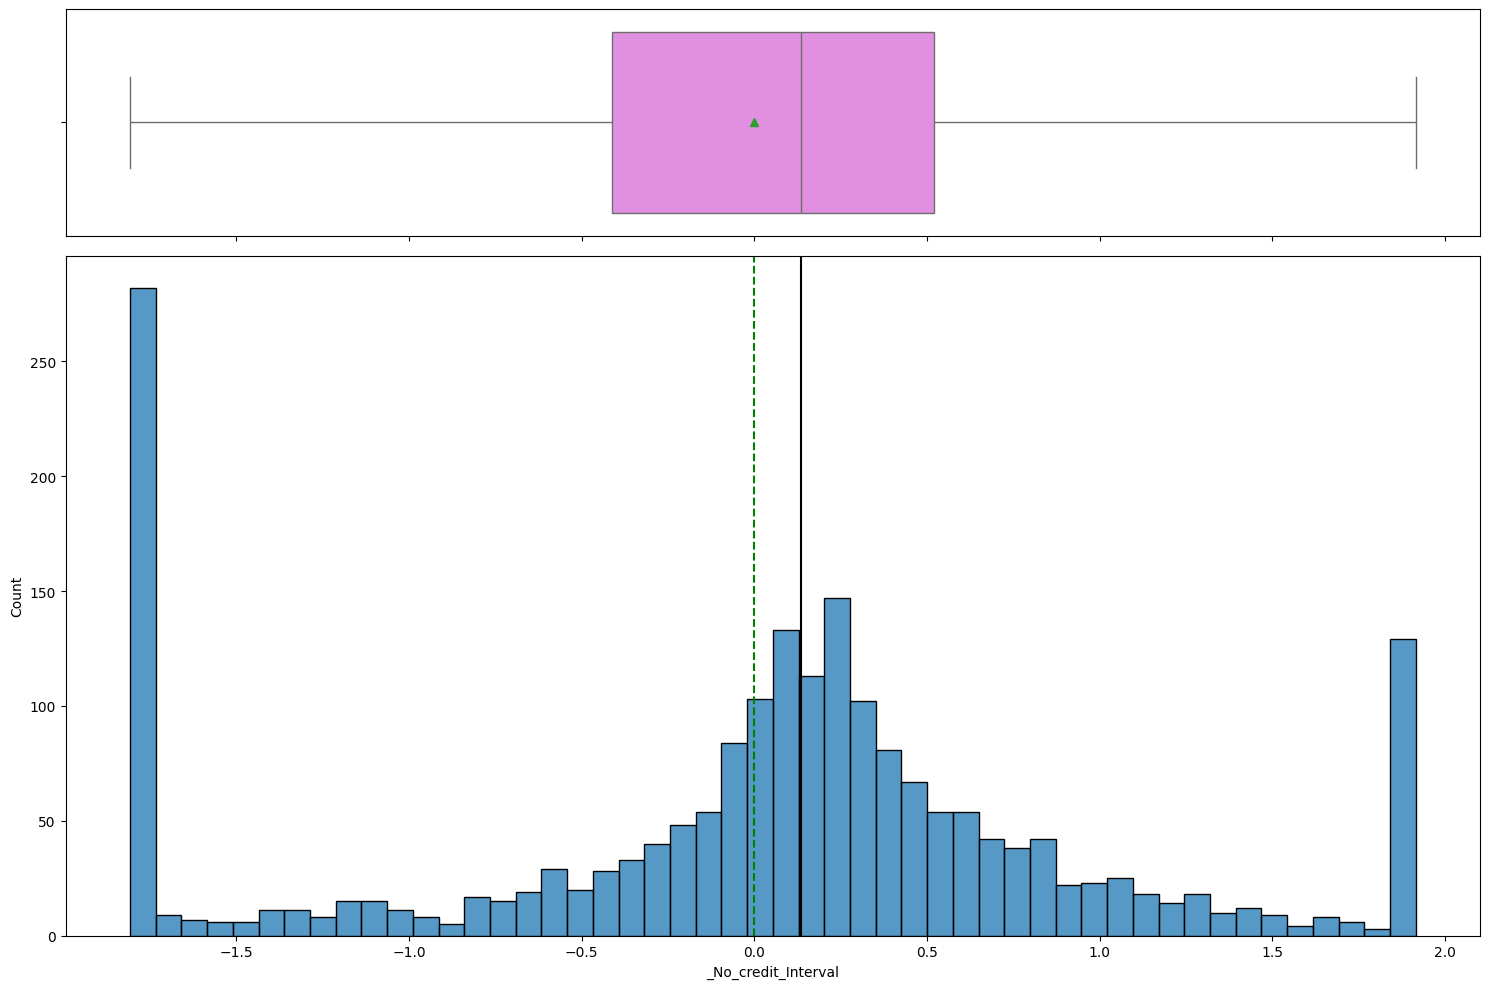

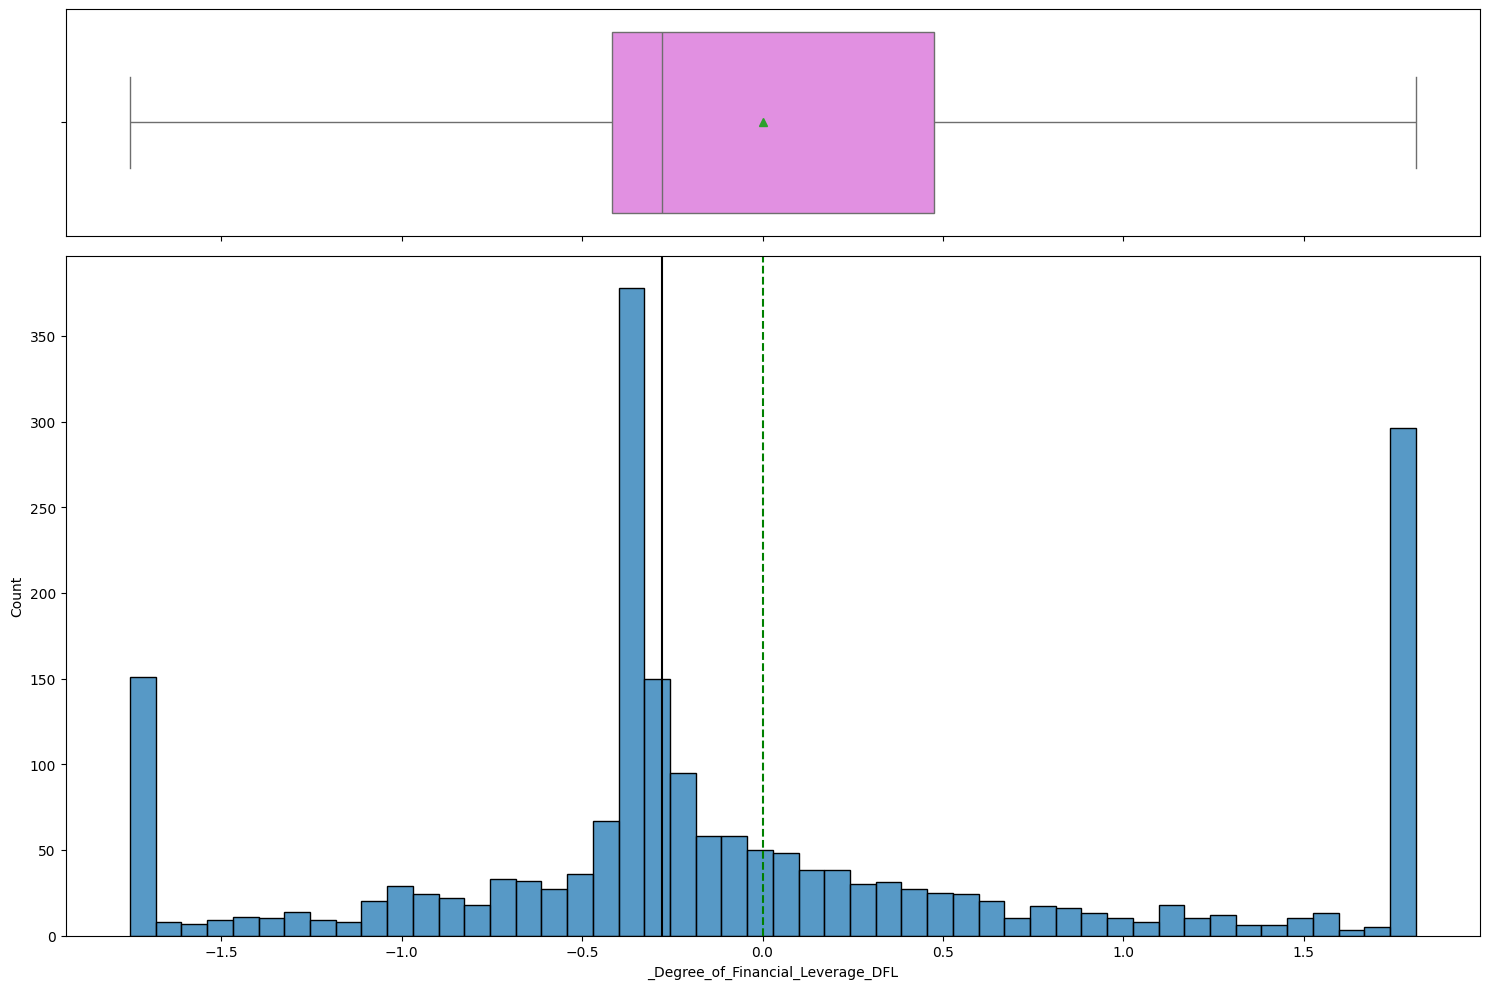

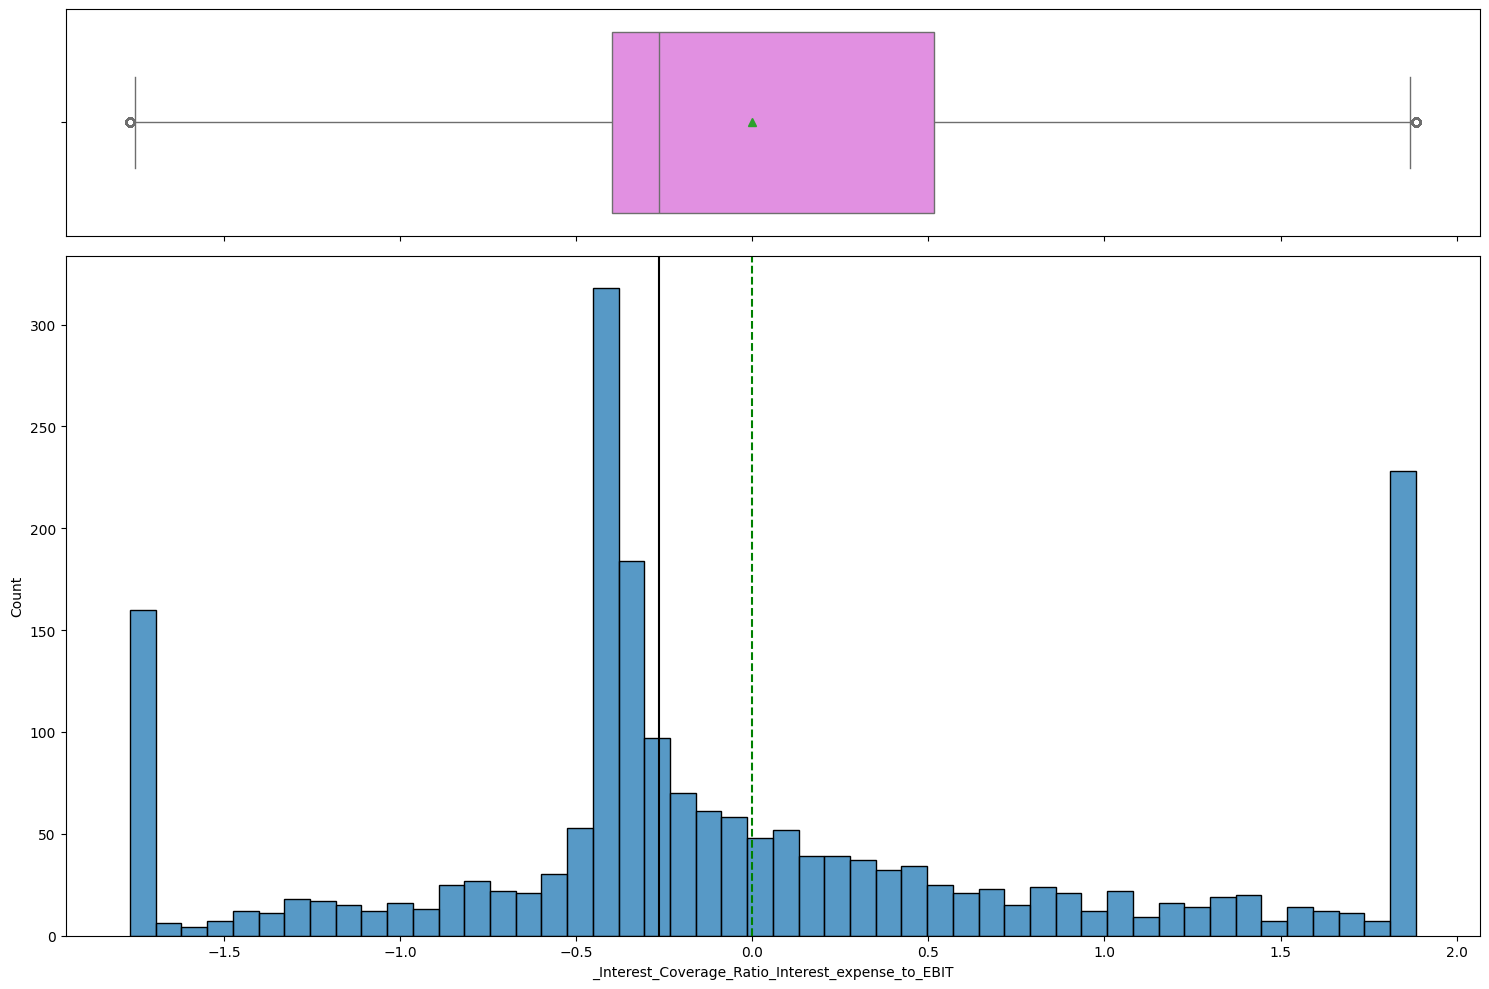

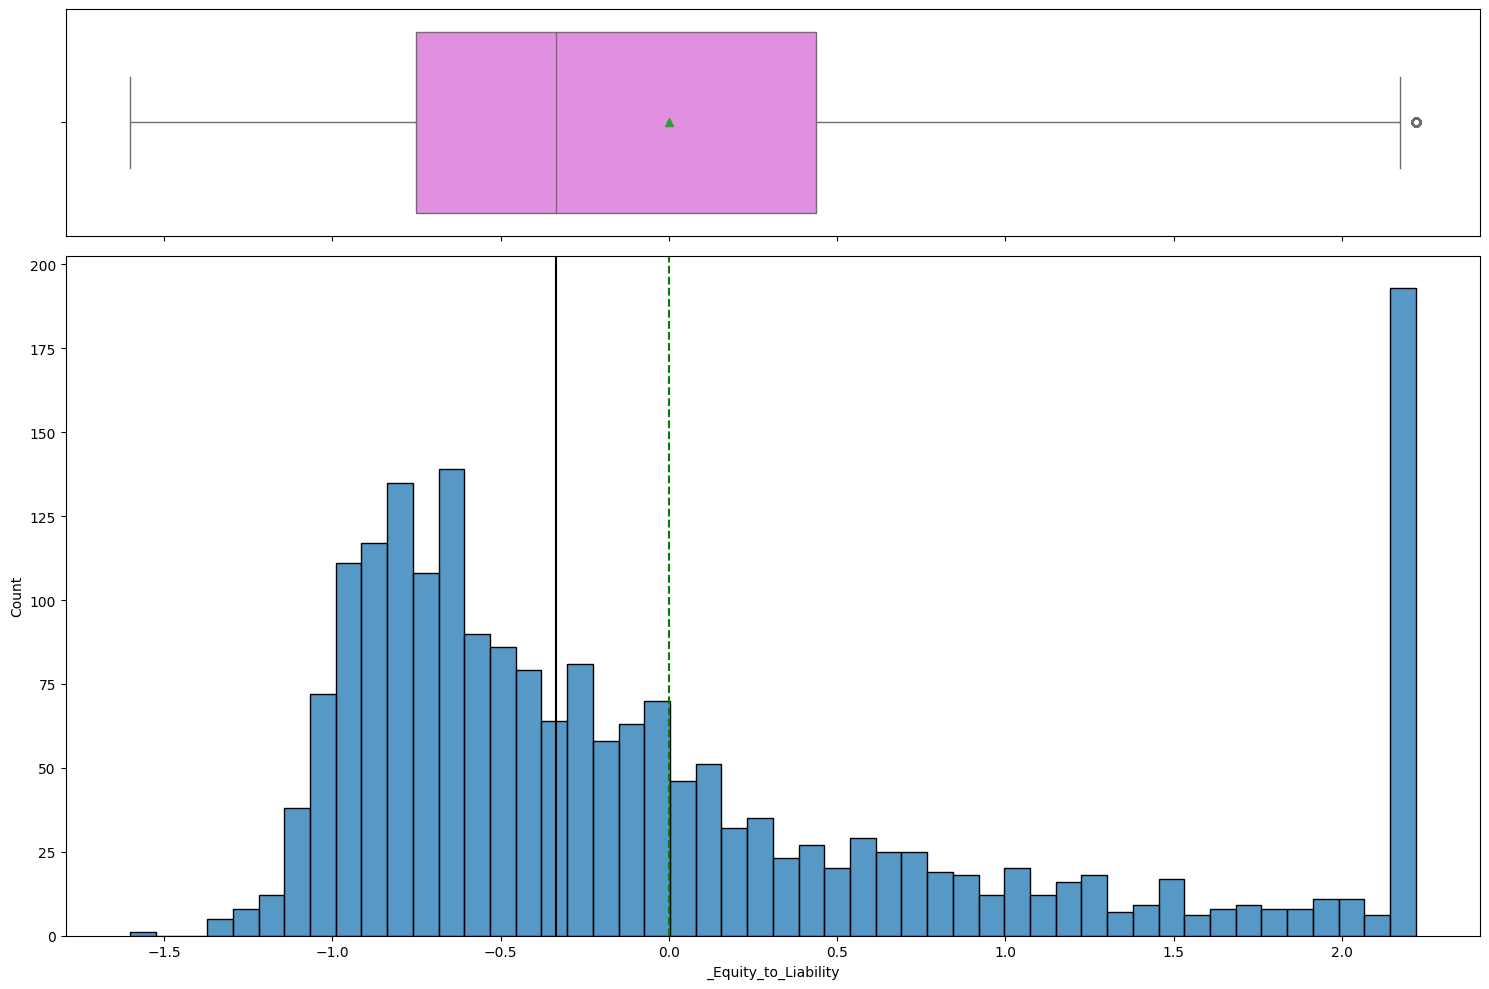

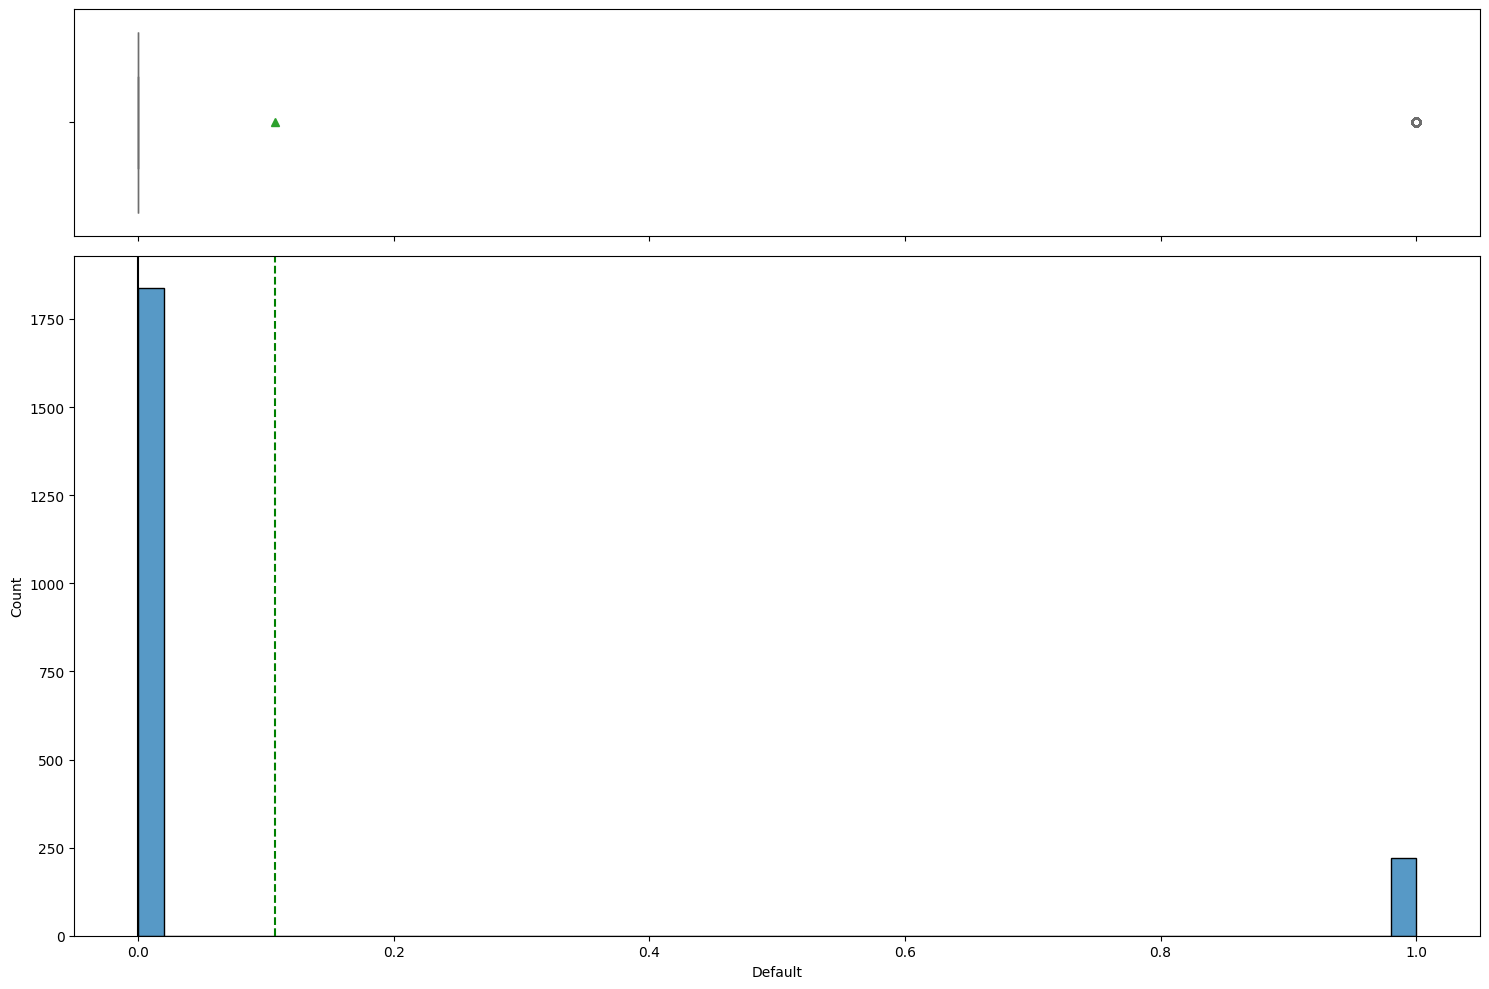

In [36]:
# loop to plot histogram_plot for numeric variables
num_cols = df_scaled.select_dtypes(include = np.number).columns

for col in num_cols:
    histogram_boxplot(df_scaled, col, bins=50)
    plt.tight_layout()
    plt.show()
    plt.close()

Finding from the EDA:
>1.  There are some variables where there is a high concentration of values close to 0 and a long right tail.  This could be an indication that there are outliers or data entry issues with the conversions and calculations.  This pattern happens for the following variables:  `_Operating_Expense_Rate`, `_Research_and_development_expense_rate`, `_Tax_rate_A`,
2.  `_Degree_of_Financial_Leverage_DFL`, `_Interest_Coverage_Ratio_Interest_expense_to_EBIT`, `_No_credit_Interval`, `_CFO_to_Assets`, `_Cash_Flow_to_Equity`, `_Cash_Flow_to_Total_Assets`, `_Cash_Flow_to_Liability`, `_Operating_Funds_to_Liability`, `_Inventory_to_Working_Capital`, `_Inventory_to_Current_Liability`, `_Operating_profit_per_person`, `_Net_profit_before_tax_to_Paid_in_capital`, `_Interest_Expense_Ratio`, `_Cash_Reinvestment_perc`, `_Total_Asset_Return_Growth_Rate_Ratio`, `_Cash_flow_rate`, `_Interest_bearing_debt_interest_rate`, `_Per_Share_Net_profit_before_tax_Yuan_`, `_Retained_Earnings_to_Total_Assets`, `_Total_income_to_Total_expense`, `_Realized_Sales_Gross_Profit_Growth_Rate`, `_Operating_Profit_Growth_Rate`, `_Continuous_Net_Profit_Growth_Rate`, `_Net_Value_Growth_Rate` appears to be normally distributed.  There are peaks at the far righ and left, however this could be due to the capped data.
3.  `_Cash_Flow_Per_Share` is normally distributed.  there are no outliers.
4.  `_Total_Asset_Growth_Rate` is bimodal with a peak to the far left.  This peak could be from the capped values.  There are no outliers.
5.  `_Quick_Assets_to_Current_Liability`, `_Net_Worth_Turnover_Rate_times`, `_Quick_Ratio`, `_Current_Ratio`, `_Total_expense_to_Assets` is normall distributed with a right skew.  There is a peak to the far right which could be due to capped values.
6.  `_Total_debt_to_Total_net_worth` are concentrated to the far left with one peak.  There are few scattered values to the right.  
7.  `_Average_Collection_Days`, `_Accounts_Receivable_Turnover`, `_Total_Asset_Turnover`, `_Long_term_fund_suitability_ratio_A` is right skewed with a peak to the far right, this could be from capped values.
8.  `_Inventory_Turnover_Rate_times`
9.  `_Quick_Asset_Turnover_Rate`, `_Cash_Turnover_Rate`, `_Inventory_Turnover_Rate_times` appears to be uniform distribution with a peak to the far left, this could be due to capped values.
10.  `_Fixed_Assets_Turnover_Frequency`, the data are concentrated to the left, there are peaks on both sides which could be due to capped values.
11. `_Cash_to_Current_Liability`, `_Allocation_rate_per_person` have data concentrated to the left with a peak to the right.  This could be due to capped values.
12. `_Quick_Assets_to_Total_Assets` is right skewed with no outliers.
13.  `_Cash_to_Total_Assets` is right skewed with outliers.
14. `_Long_term_Liability_to_Current_Assets`, appears to have almost uniform data witn peaks on both sides, could be due to capped data.
15. `_Current_Asset_Turnover_Rate` appears to he highly right skewed with a peak to the right.  the peak to the right could be due to capped values.
16.`_Fixed_Assets_to_Assets` is left skewed with no outliers.
17.  `_Current_Liability_to_Current_Assets` has values concentrated to the left.  It is highly right skewed with outliers to the right.
18.  `_Liability_Assets_Flag` values concentrate around 0.  This variable is 1 or 0 category variable but has type float.
19.  `_Total_assets_to_GNP_price` is right skewed with a peak to the right.  appears to have values capped on both sides.
20.  `_Equity_to_Liability` is right skewed with a large peak to the right, this could be from capped values.
21 `Default` are 0 or 1.  There are approx 250 1's and over 1750 0's.


## Bivariate and Multivariate Analysis

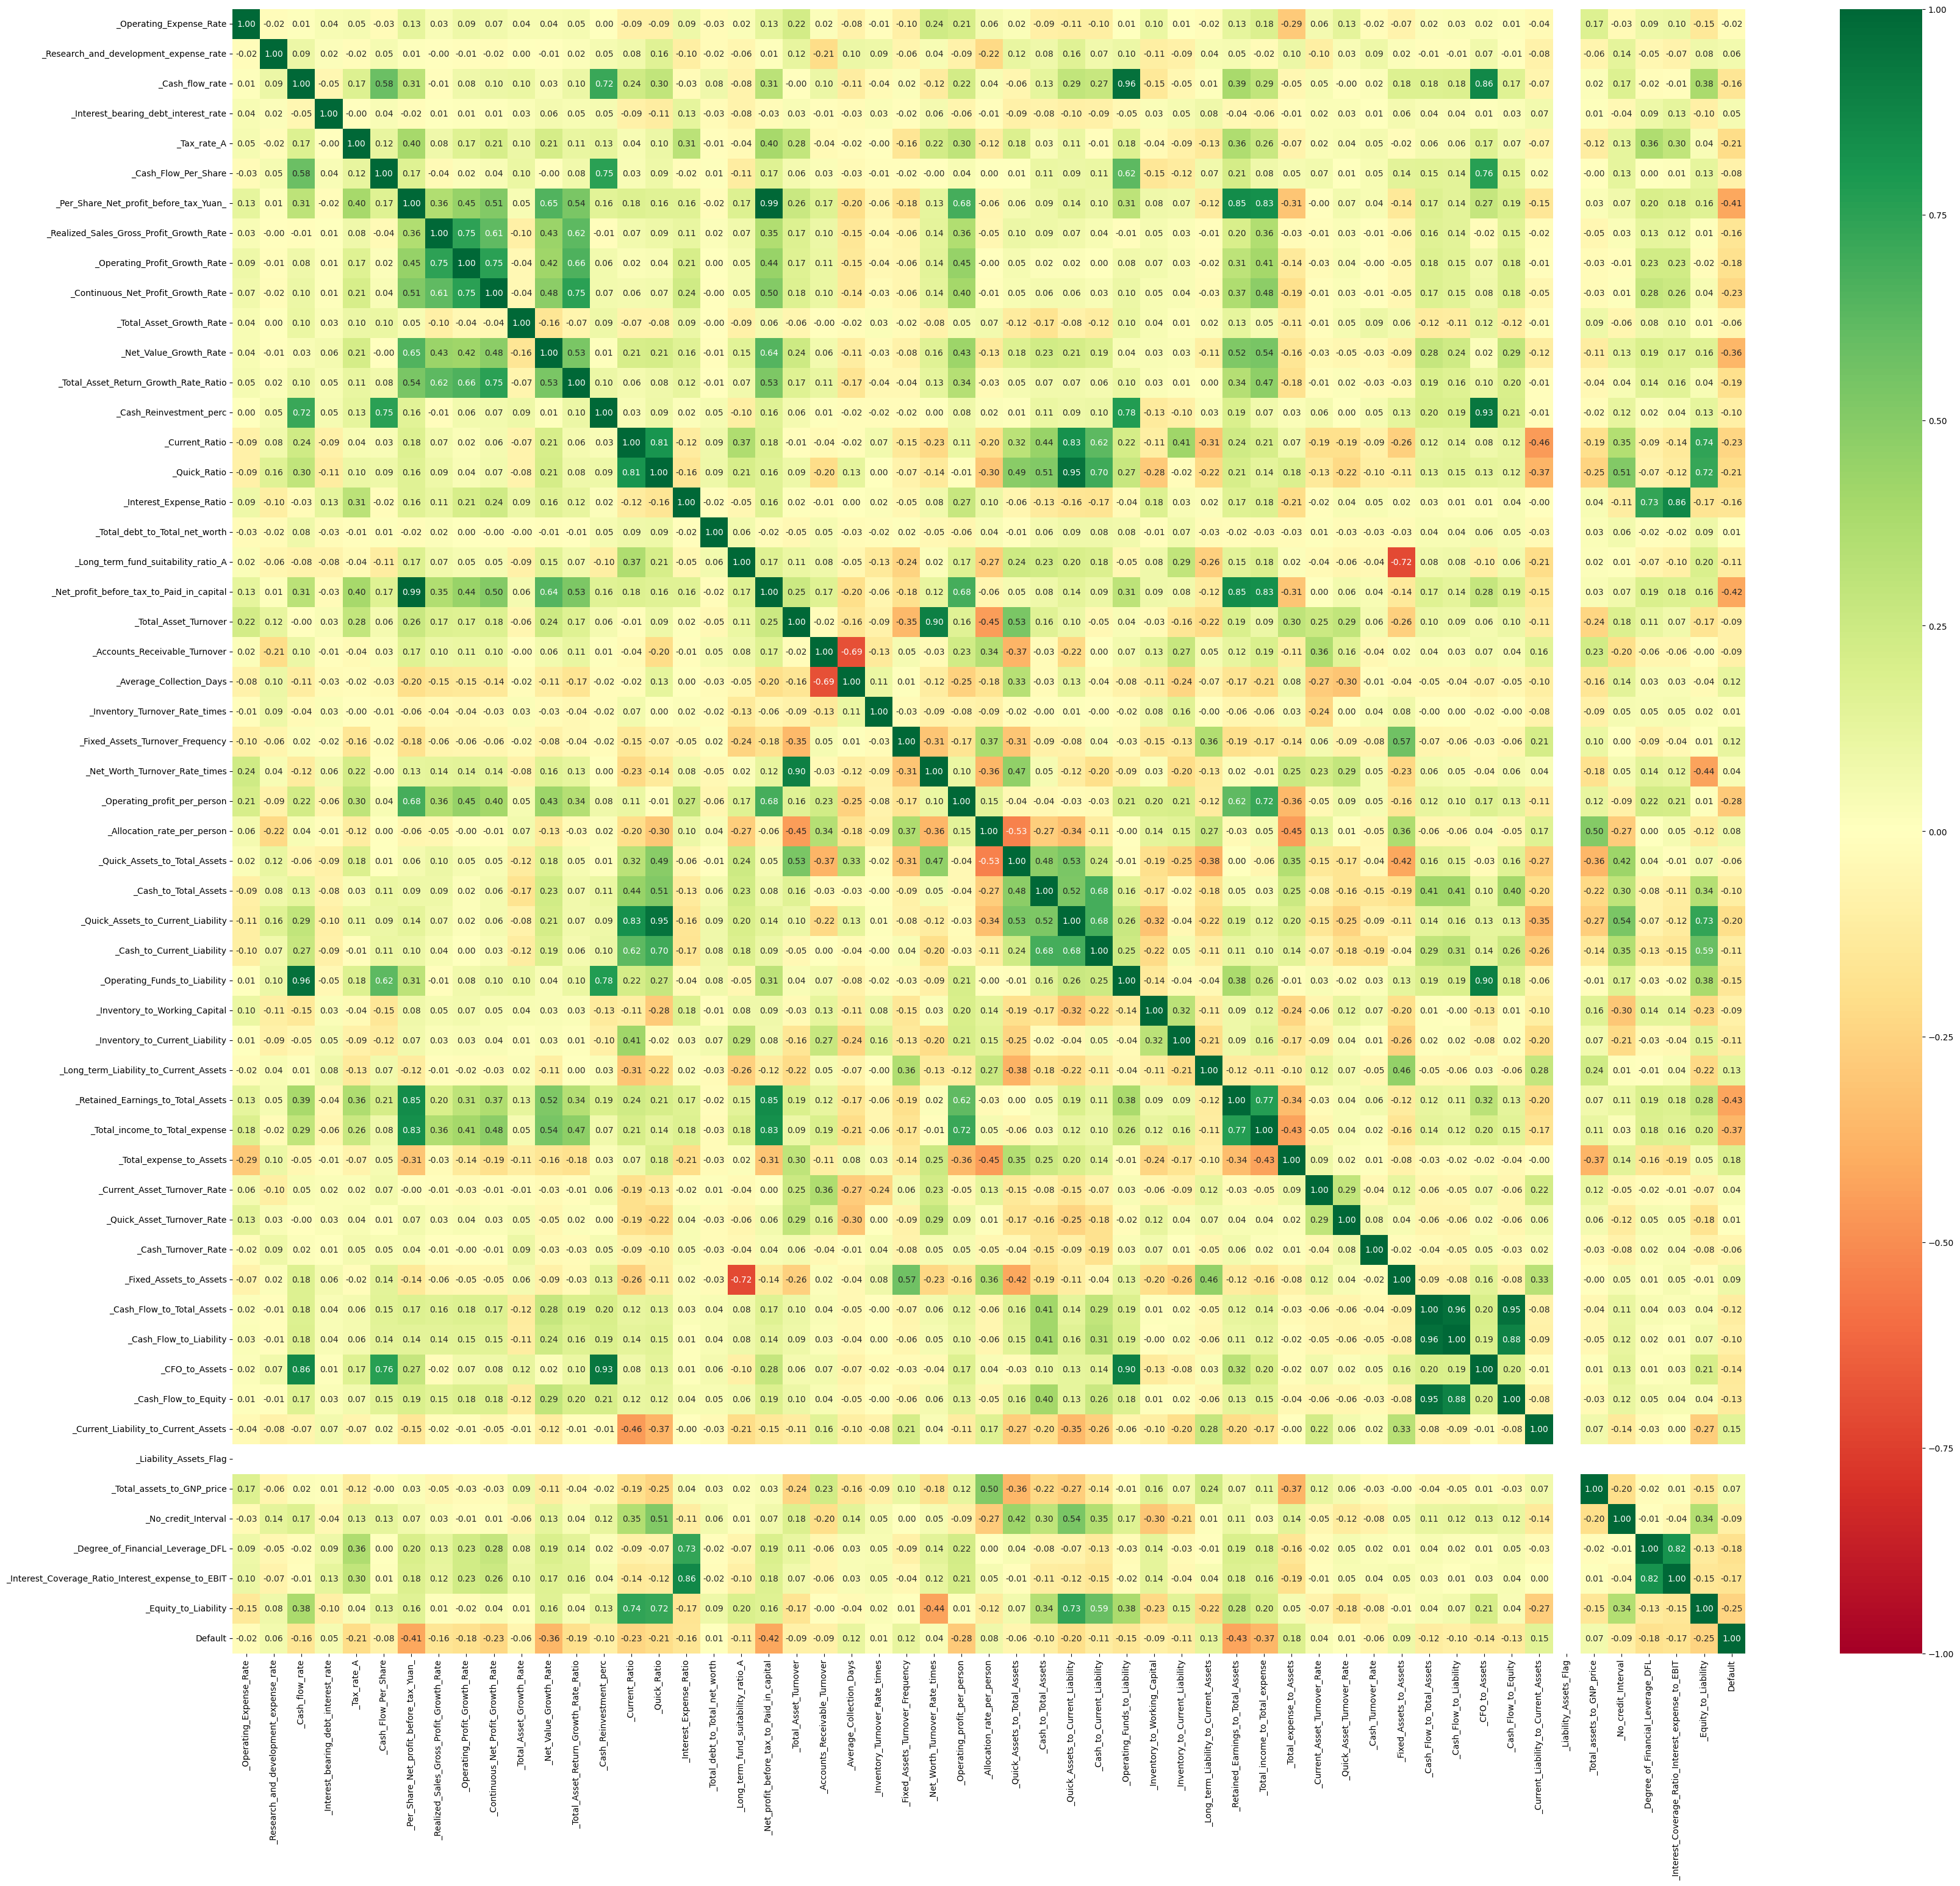

In [37]:
cols_list = df_scaled.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(40, 35))
sns.heatmap(
    df_scaled[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="RdYlGn"
)
plt.show()

> From the correlation matrix we see that there are some medium and high correlation between some variables.  T
>  1.  We see some very high negative correlations in red.  E.g `_Average_Collection_Days` with `_Accounts_Receivable_Turnover` and `_Long_term_fund_suitability_ratio_A` with `_Fixed_Assets_to_Assets`.  
2.  There are also high positive correlation e.g.  `_Interest_Expense_Ratio` with `_Interest_Coverage_Ratio_Interest_expense_to_EBIT`  and `_CFO_to_Assets' with `_Operating_Funds_to_Liability`

We will need to address multicollenarity before building the models

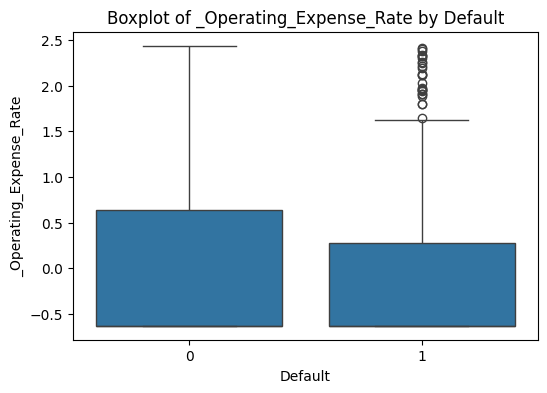

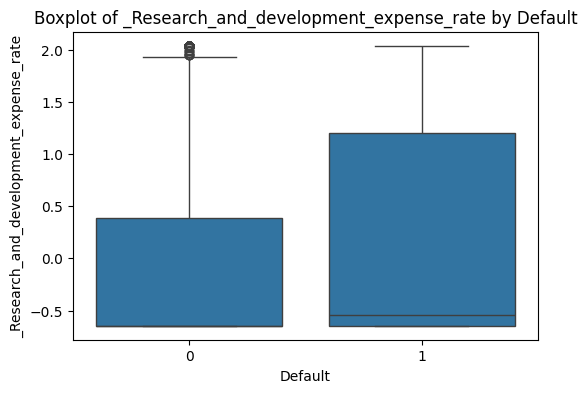

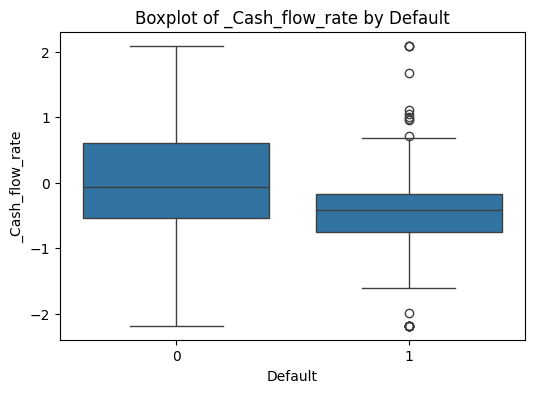

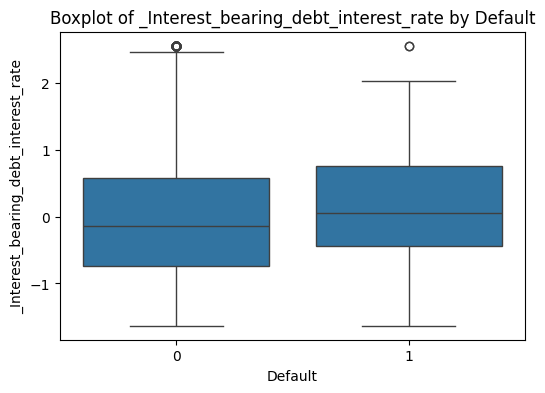

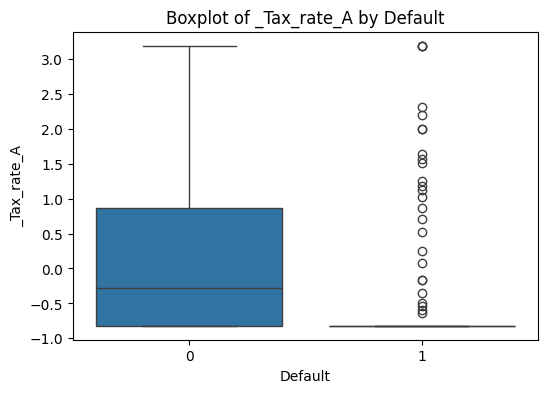

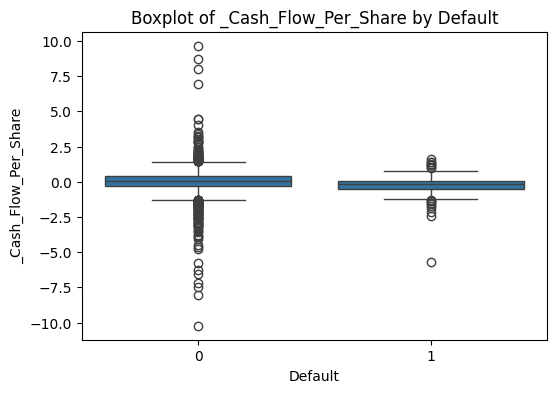

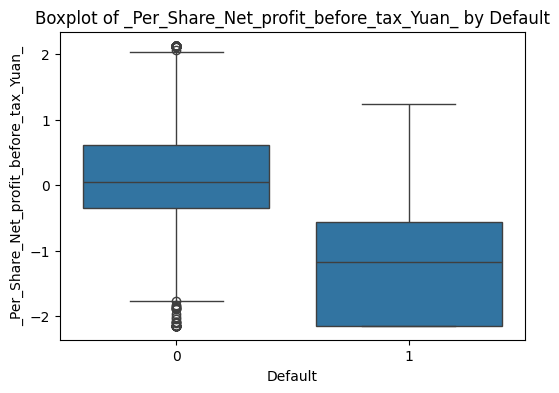

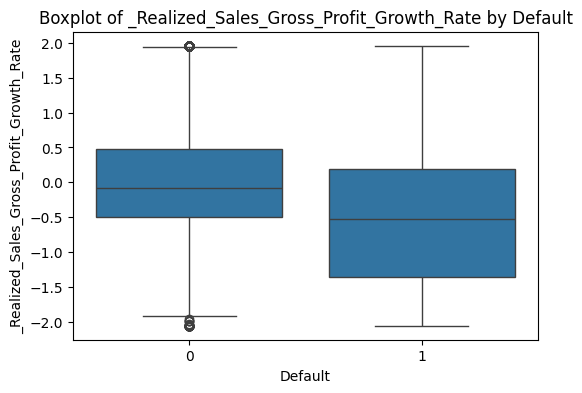

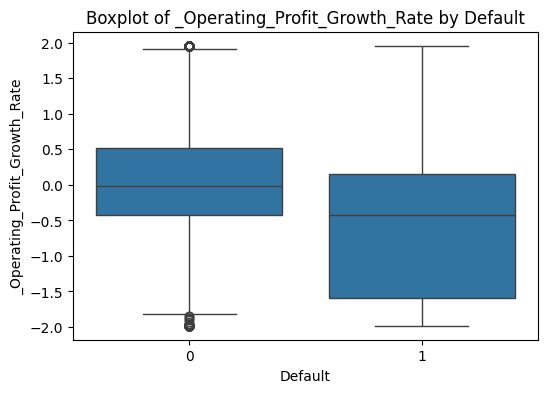

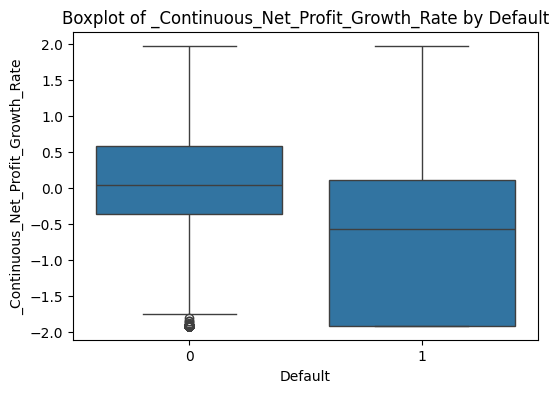

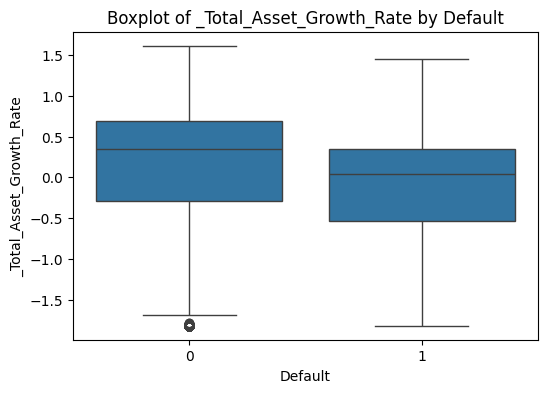

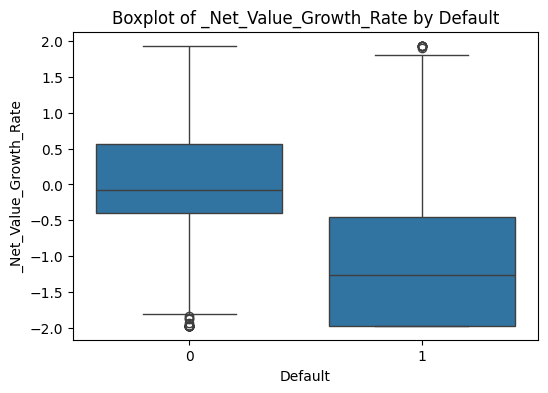

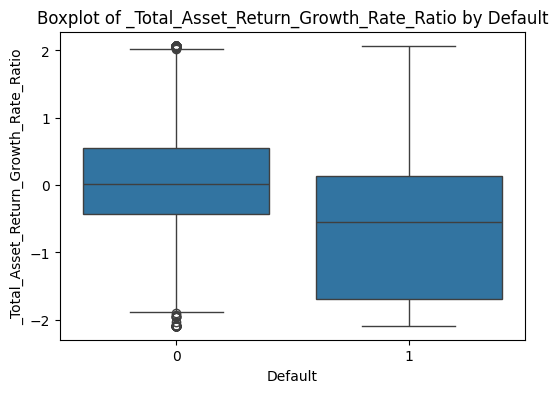

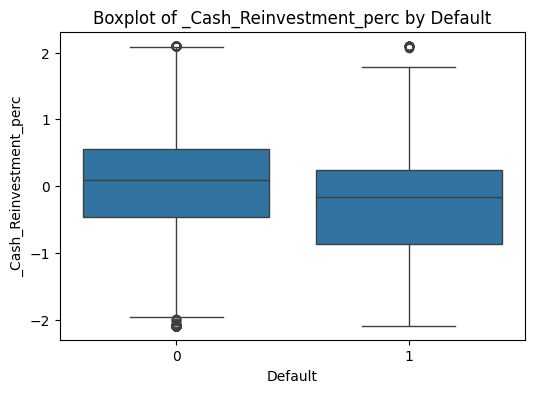

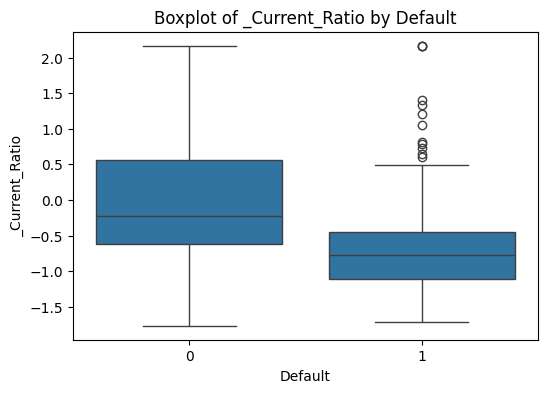

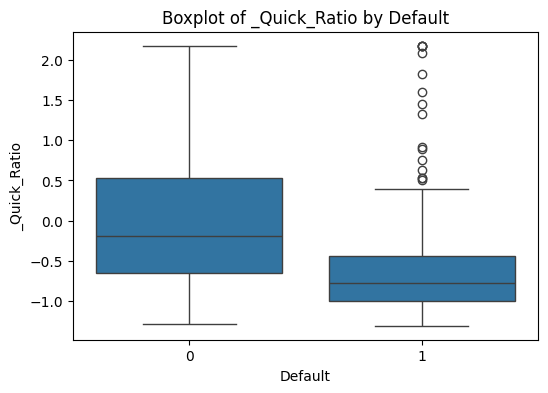

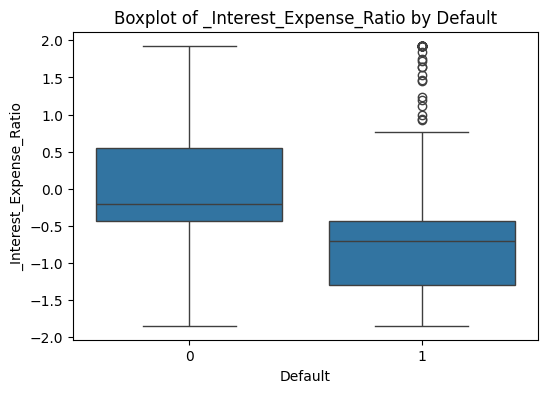

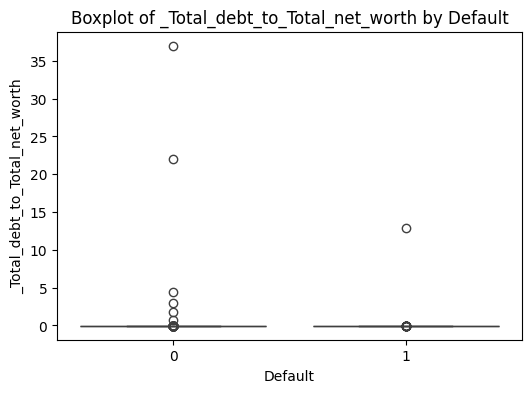

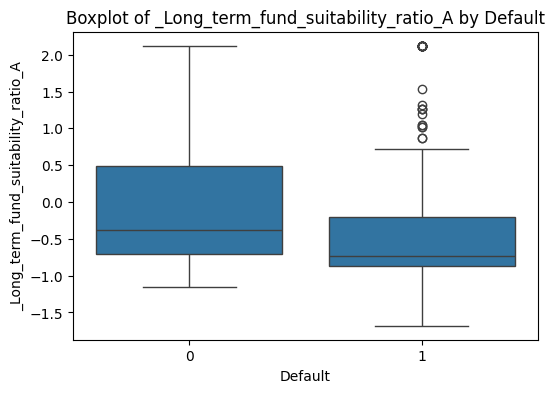

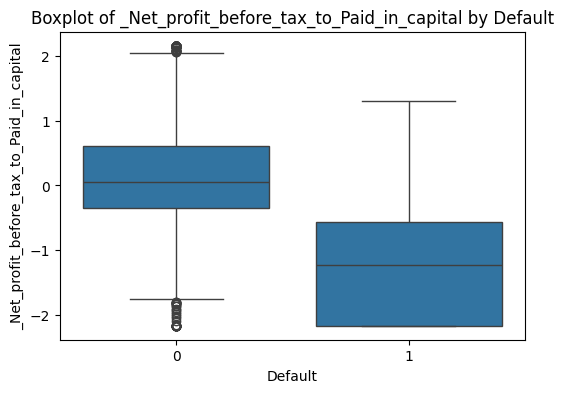

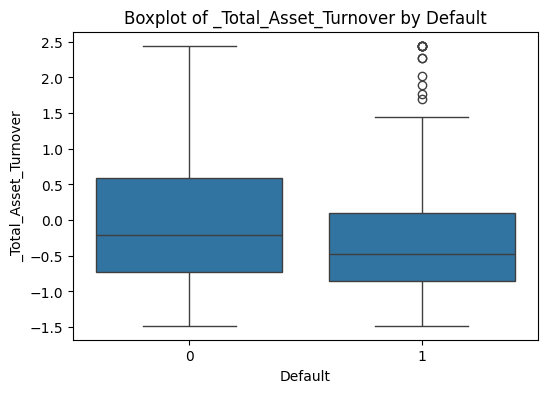

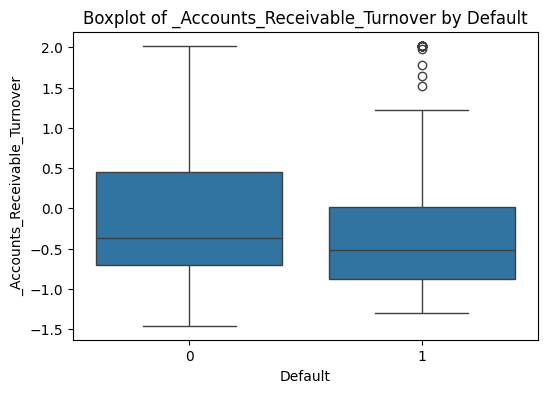

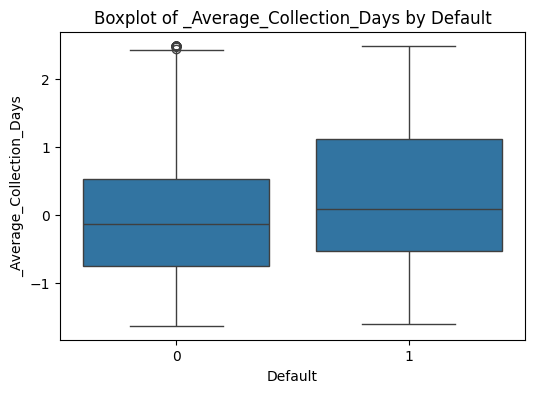

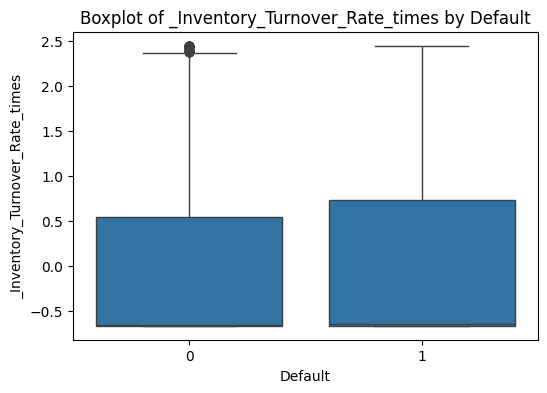

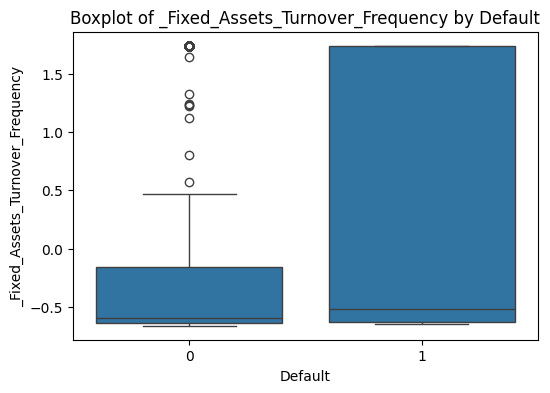

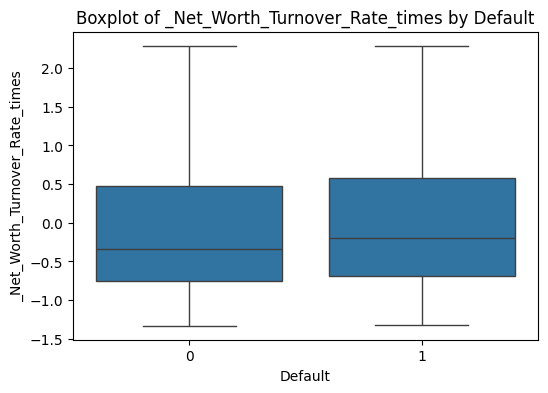

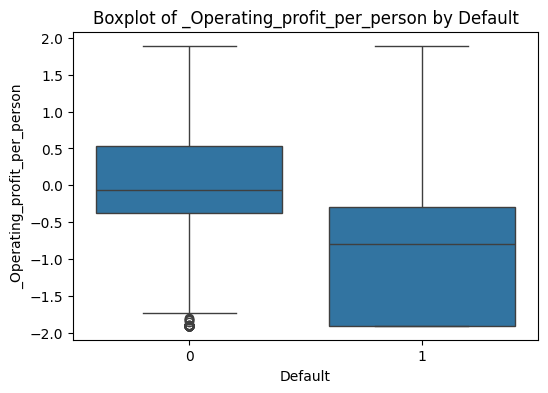

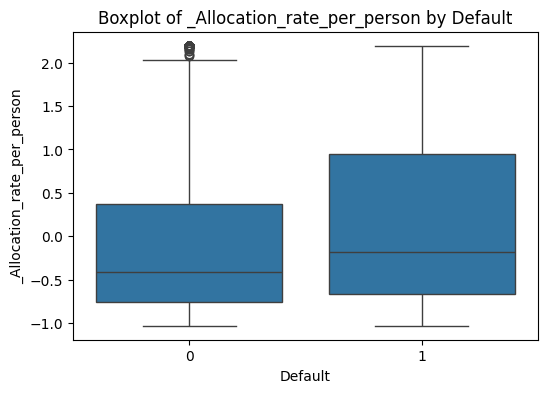

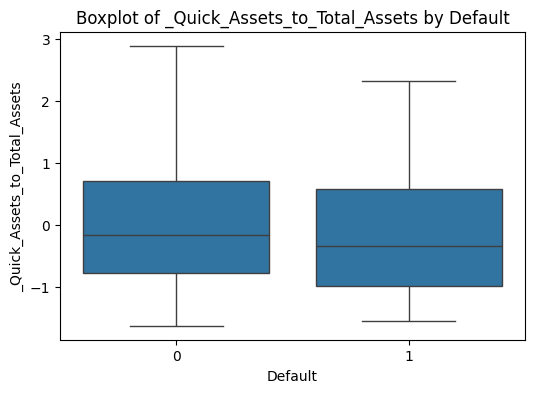

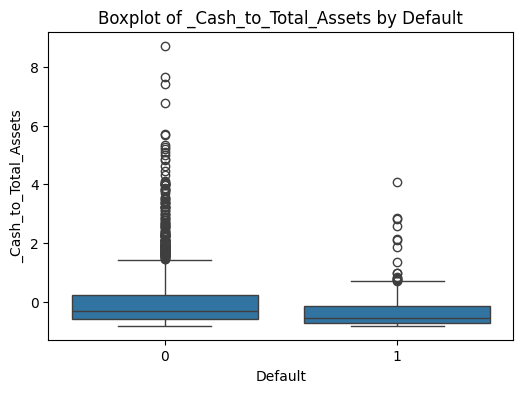

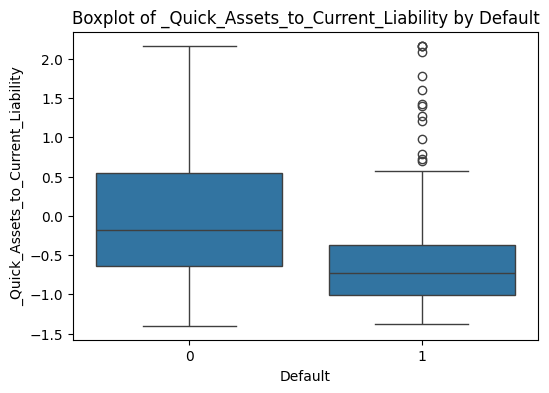

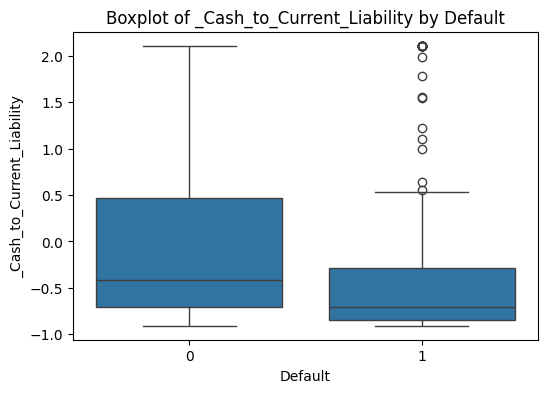

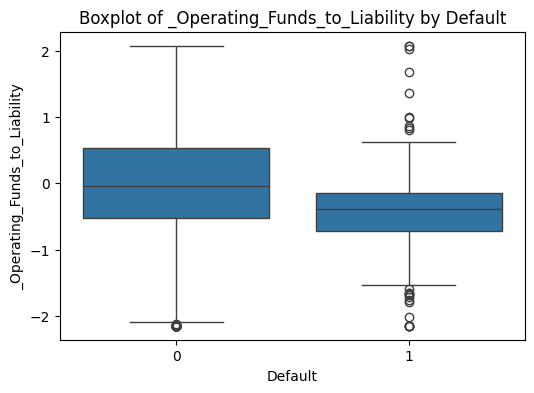

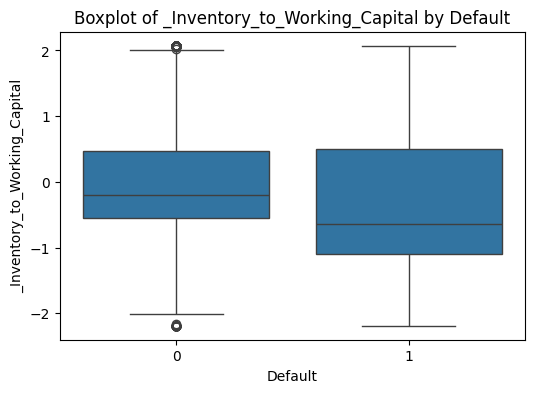

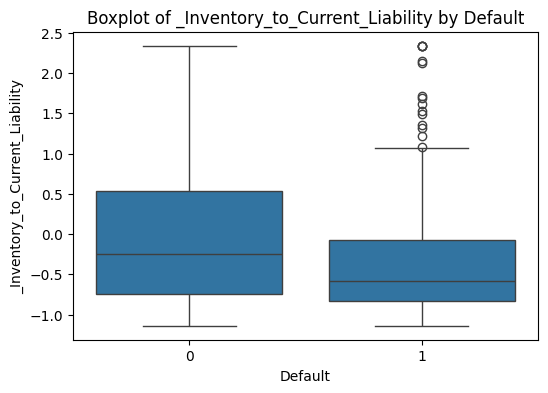

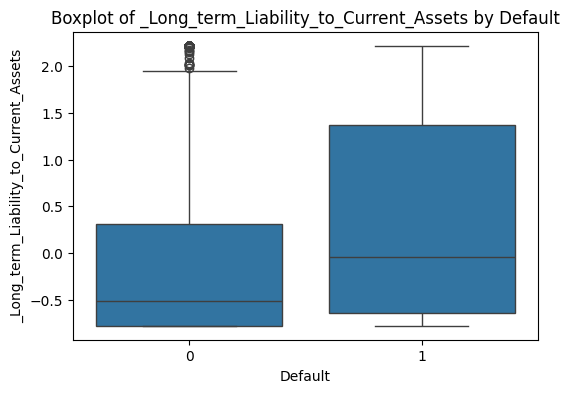

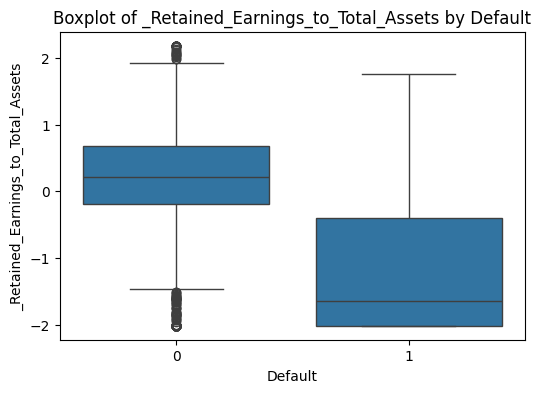

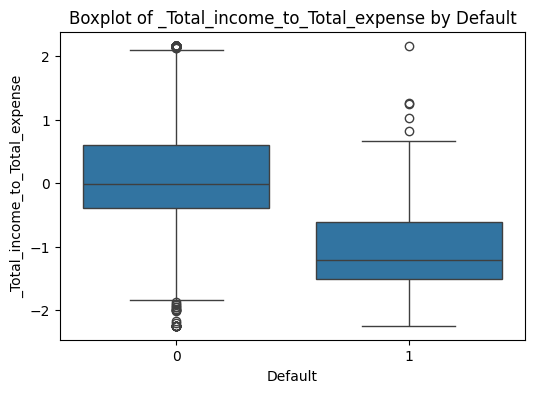

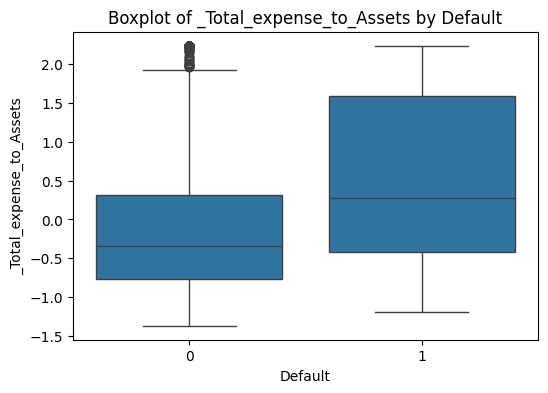

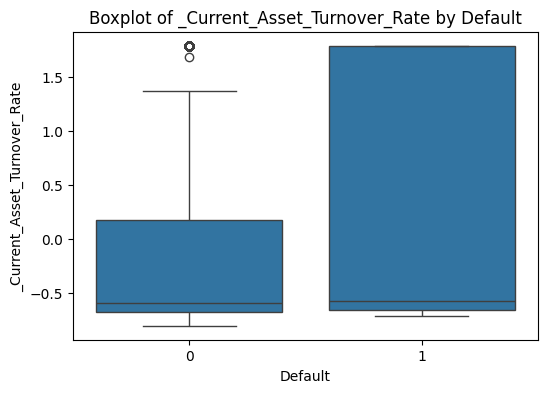

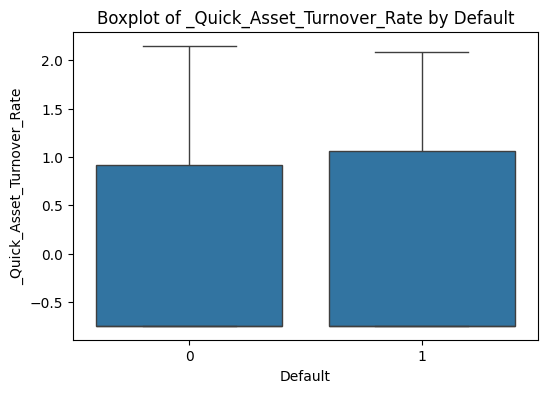

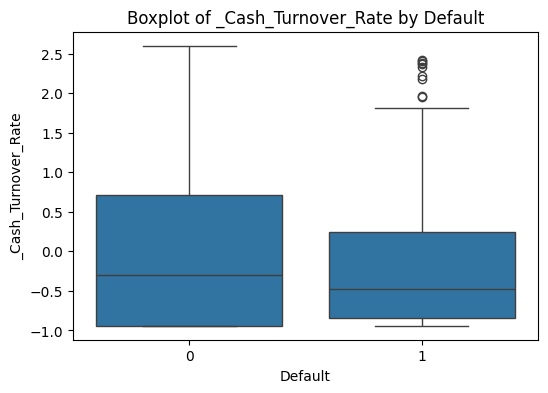

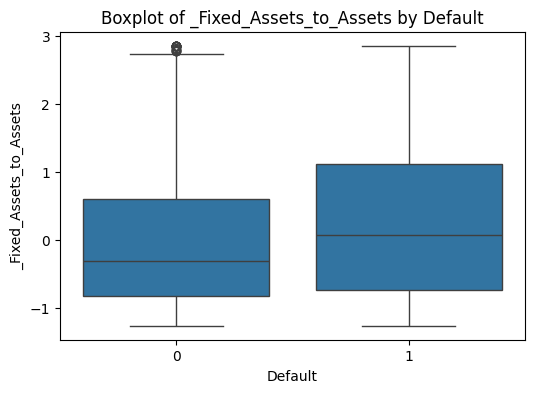

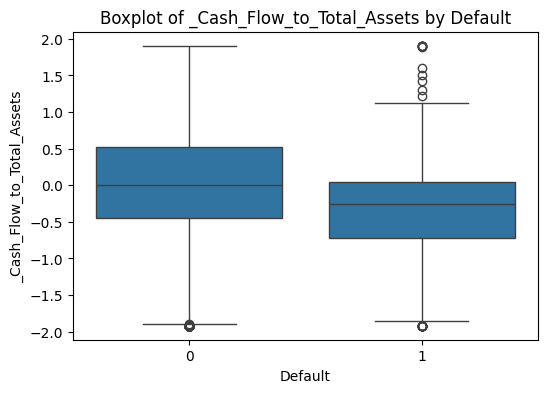

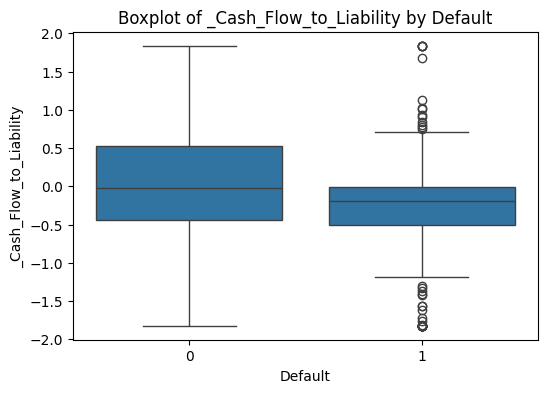

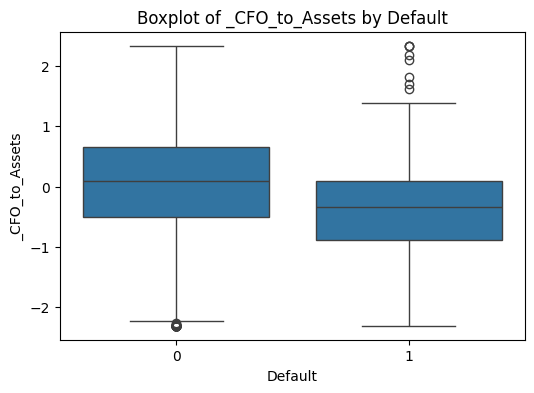

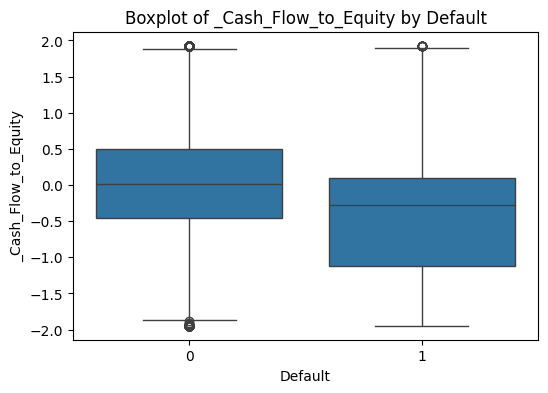

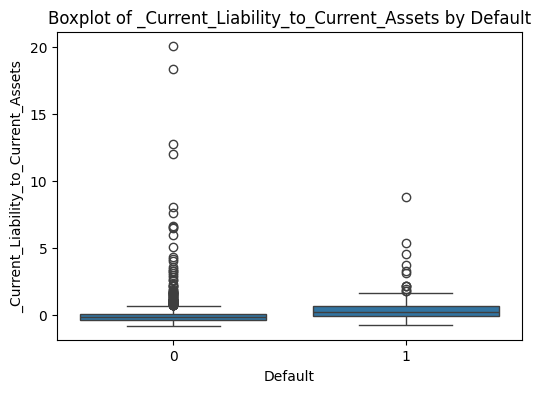

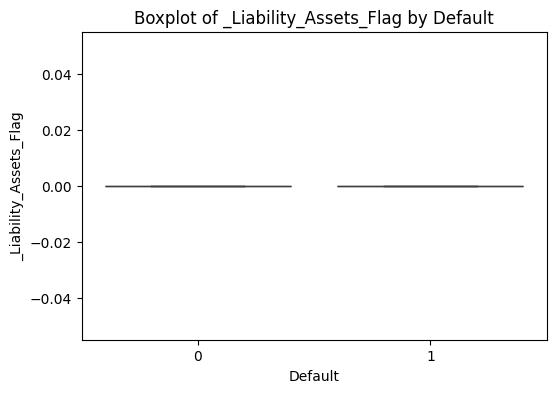

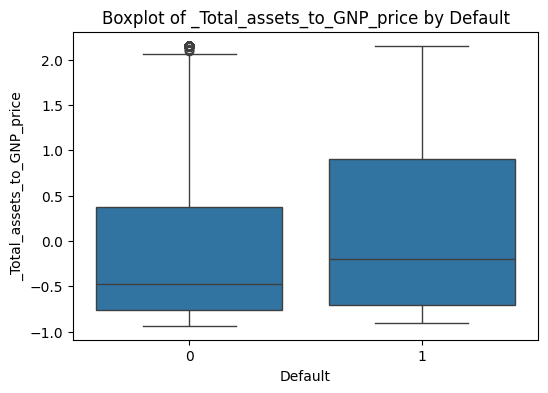

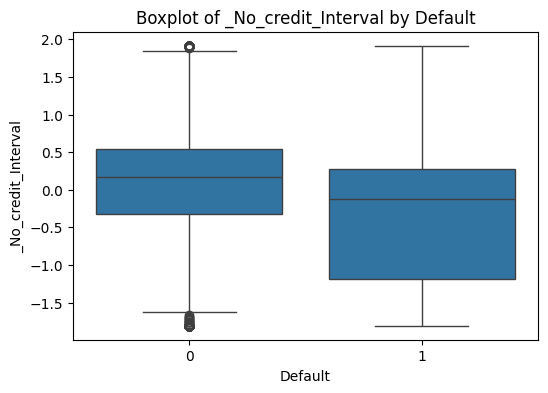

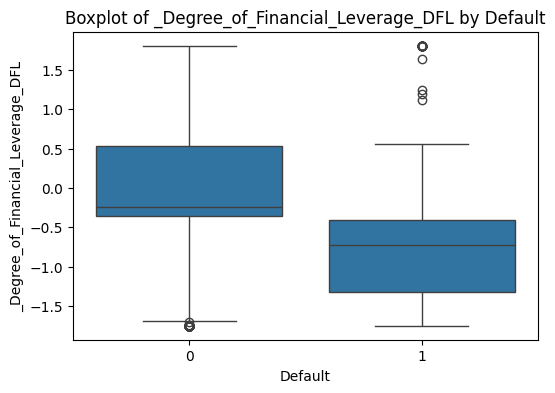

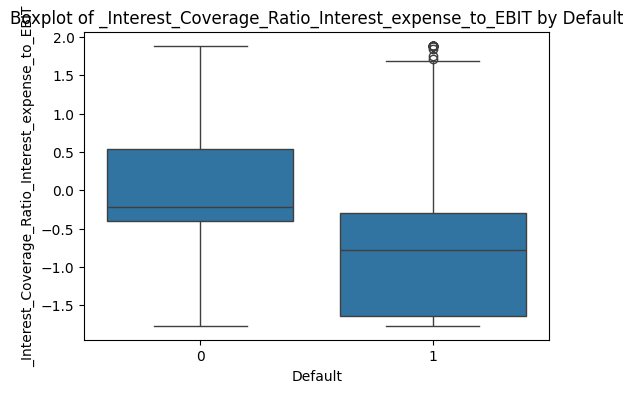

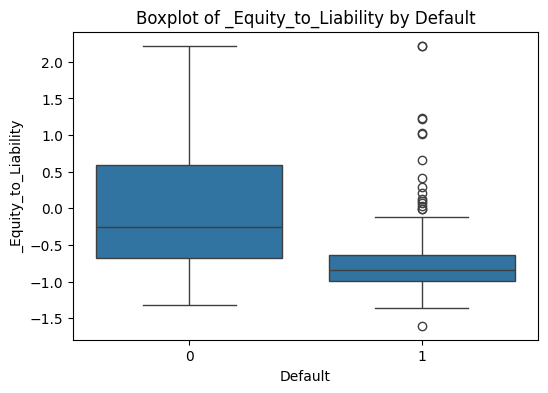

In [38]:
# loop to plot boxplot
num_cols = df_scaled.select_dtypes(include='float').columns

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="Default", y=col, data=df_scaled)
    plt.title(f"Boxplot of {col} by Default")
    plt.show()

By analyzing how each variable relates to the Default (1 or 0), we can uncover valuable insights. To support this analysis, we examined the distributions of each variable using boxplots.  This are some of the more outstanding findings:
>1.  Those who defaulted tend to have higher:  `_Research_and_development_expense_rate`, `_Average_Collection_Days`, `_Fixed_Assets_Turnover_Frequency`, `_Long_term_Liability_to_Current_Assets`, `_Current_Asset_Turnover_Rate`
2.  Those who defaulted tend to have lower: `_Cash_flow_rate`, `_Tax_rate_A`, `_Per_Share_Net_profit_before_tax_Yuan_`, `_Total_expense_to_Assets`, `_Realized_Sales_Gross_Profit_Growth_Rate`, `_Operating_Profit_Growth_Rate`, `_Total_Asset_Growth_Rate`, `_Net_Value_Growth_Rate`, `_Total_Asset_Return_Growth_Rate_Ratio`, `_Current_Ratio`, `_Quick_Ratio`, `_Interest_Expense_Ratio`, `_Net_profit_before_tax_to_Paid_in_capital`, `_Accounts_Receivable_Turnover`, `_Operating_profit_per_person`, `_Operating_profit_per_person`, `_Quick_Assets_to_Current_Liability`, `_Cash_to_Current_Liability`, `_Operating_Funds_to_Liability`, `_Retained_Earnings_to_Total_Assets`, `_Total_income_to_Total_expense`, `_Cash_Flow_to_Equity`, `_No_credit_Interval`, `_Degree_of_Financial_Leverage_DFL`, `_Interest_Coverage_Ratio_Interest_expense_to_EBIT`

# Data Preparation for modelling

> As the Default is already in 1 and 0 we do not need to encode it

>  We will start with splitting into train and test

#### Creating training and test datasets

In [39]:
# specifying the independent  and dependent variables
X = df_scaled.drop(["Default"], axis=1)
Y = df_scaled["Default"]

# adding a constant to the independent variables
X = sm.add_constant(X, has_constant='add')

# creating dummy variables
#X = pd.get_dummies(X, drop_first=True)

# splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.33, random_state=42
)

In [40]:
# Checking that all variables are numeric for the model to run
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2058 entries, 0 to 2057
Data columns (total 55 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   const                                              2058 non-null   float64
 1   _Operating_Expense_Rate                            2058 non-null   float64
 2   _Research_and_development_expense_rate             2058 non-null   float64
 3   _Cash_flow_rate                                    2058 non-null   float64
 4   _Interest_bearing_debt_interest_rate               2058 non-null   float64
 5   _Tax_rate_A                                        2058 non-null   float64
 6   _Cash_Flow_Per_Share                               2058 non-null   float64
 7   _Per_Share_Net_profit_before_tax_Yuan_             2058 non-null   float64
 8   _Realized_Sales_Gross_Profit_Growth_Rate           2058 non-null   float64
 9   _Operati

In [41]:
X.head()

,const,_Operating_Expense_Rate,_Research_and_development_expense_rate,_Cash_flow_rate,_Interest_bearing_debt_interest_rate,_Tax_rate_A,_Cash_Flow_Per_Share,_Per_Share_Net_profit_before_tax_Yuan_,_Realized_Sales_Gross_Profit_Growth_Rate,_Operating_Profit_Growth_Rate,_Continuous_Net_Profit_Growth_Rate,_Total_Asset_Growth_Rate,_Net_Value_Growth_Rate,_Total_Asset_Return_Growth_Rate_Ratio,_Cash_Reinvestment_perc,_Current_Ratio,_Quick_Ratio,_Interest_Expense_Ratio,_Total_debt_to_Total_net_worth,_Long_term_fund_suitability_ratio_A,_Net_profit_before_tax_to_Paid_in_capital,_Total_Asset_Turnover,_Accounts_Receivable_Turnover,_Average_Collection_Days,_Inventory_Turnover_Rate_times,_Fixed_Assets_Turnover_Frequency,_Net_Worth_Turnover_Rate_times,_Operating_profit_per_person,_Allocation_rate_per_person,_Quick_Assets_to_Total_Assets,_Cash_to_Total_Assets,_Quick_Assets_to_Current_Liability,_Cash_to_Current_Liability,_Operating_Funds_to_Liability,_Inventory_to_Working_Capital,_Inventory_to_Current_Liability,_Long_term_Liability_to_Current_Assets,_Retained_Earnings_to_Total_Assets,_Total_income_to_Total_expense,_Total_expense_to_Assets,_Current_Asset_Turnover_Rate,_Quick_Asset_Turnover_Rate,_Cash_Turnover_Rate,_Fixed_Assets_to_Assets,_Cash_Flow_to_Total_Assets,_Cash_Flow_to_Liability,_CFO_to_Assets,_Cash_Flow_to_Equity,_Current_Liability_to_Current_Assets,_Liability_Assets_Flag,_Total_assets_to_GNP_price,_No_credit_Interval,_Degree_of_Financial_Leverage_DFL,_Interest_Coverage_Ratio_Interest_expense_to_EBIT,_Equity_to_Liability
0,1.00000,2.08117,-0.64515,-0.31786,-0.44612,-0.80871,0.17203,1.00242,-0.38084,-0.17483,-0.10799,0.75976,-0.41403,-0.23176,-0.62964,-0.39774,-1.25854,0.32010,-0.03989,-0.18484,1.02512,-0.83412,2.01973,-1.51594,-0.43018,-0.62624,-0.26581,1.89474,2.19495,-0.78831,-0.55454,-1.11051,-0.80699,-0.26171,1.57155,1.12723,-0.42667,0.34179,1.64857,-1.04084,-0.15334,-0.74486,0.99849,-0.82184,-0.51717,-0.32219,-0.07077,-0.97834,-0.09261,0.00000,2.15408,-1.80862,0.12570,0.10024,-1.01338
1,1.00000,2.25338,2.03744,-0.57664,0.78253,-0.81922,-0.30585,-0.81827,-2.05492,-1.98228,-1.91335,0.50219,-1.12565,-0.57390,-0.37953,-0.62568,-0.37293,-1.84491,-0.03989,-0.67437,-0.84470,-0.79820,-1.15635,2.49147,-0.66055,1.73915,-0.84690,-0.95763,0.32100,0.28486,-0.77211,-0.13735,-0.88806,-0.57709,-0.27010,-0.97888,-0.22718,-0.57287,-1.23319,-0.59904,-0.53377,-0.74486,-0.62814,0.36480,-0.04331,-0.06266,-0.54680,-0.03321,0.04836,0.00000,0.25047,-1.46770,-1.75266,-1.76667,-0.28531
2,1.00000,0.53742,-0.08094,-1.94793,0.03994,-0.81922,-1.36969,-0.21276,0.82226,1.05283,-0.47523,1.50841,-0.21974,0.11886,-2.06254,-0.34109,-0.15318,0.46585,-0.03989,-0.75775,-0.21325,0.36945,-0.42626,-0.09478,-0.66055,-0.64430,-0.26581,-0.29397,-0.29800,-0.11053,-0.73383,-0.23209,-0.84550,-2.14442,0.11254,-0.25371,-0.77616,-0.01795,0.02259,-0.89791,-0.68700,-0.47232,-0.70011,0.87784,0.02655,0.02708,-2.20854,0.01941,-0.12091,0.00000,-0.72441,0.13536,1.34017,0.94939,0.34813
3,1.00000,1.34927,-0.64515,-0.22583,0.36398,-0.75017,-0.01288,-0.09166,1.95761,1.95861,1.42589,0.76662,-0.28340,1.34039,0.12926,1.15241,-0.96870,1.21512,-0.03989,2.12213,-0.17775,-0.25928,2.01973,-1.33379,-0.22392,-0.44986,-0.33947,1.89474,-0.49413,-0.97547,-0.26696,-0.93261,-0.43392,-0.19058,0.35117,2.33945,-0.26614,-0.42927,0.06579,-0.69569,-0.44517,0.79307,1.19349,-1.13430,0.59447,0.49061,-0.06433,0.58507,-0.47718,0.00000,-0.21669,-0.88502,0.32843,0.27460,-0.41376
4,1.00000,0.50052,-0.64515,-0.17408,1.00531,2.14830,0.34494,0.00856,-0.40266,-0.41498,-0.13520,0.62926,-0.16496,-0.11441,0.81708,-0.38081,-0.53321,1.29413,-0.03989,-0.13460,0.02207,0.47723,-0.65492,0.34388,-0.66055,-0.56540,0.87181,-0.34372,-0.90770,1.88866,0.03024,-0.00572,-0.50738,-0.04326,-0.24845,-0.71729,-0.77616,0.08383,-0.03967,-0.85987,-0.61571,-0.74486,1.06940,-0.78023,0.58149,0.35703,0.25167,0.77933,-0.10131,0.00000,0.32771,1.00329,1.80972,1.31757,-0.77791


In [42]:
X.shape

(2058, 55)

**Observations**
> All datatypes are numeric

In [43]:
# Checking the shape of the training and test data to ensure that they have the same distribution of 1's and 0's
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (1378, 55)
Shape of test set :  (680, 55)
Percentage of classes in training set:
Default
0   0.88897
1   0.11103
Name: proportion, dtype: float64
Percentage of classes in test set:
Default
0   0.90147
1   0.09853
Name: proportion, dtype: float64


**Observations**
>1.  We see that in the training dataset 89% belongs to 0 and 11% to 1
2.  In the test set 90% belong to 0 and 10% to 1

This is an equal distribution for the train and test sets

## Building a Logistic Regression model

- We will now perform logistic regression using statsmodels, a Python module that provides functions for the estimation of many statistical models, as well as for conducting statistical tests, and statistical data exploration.

- Using statsmodels, we will be able to check the statistical validity of our model - identify the significant predictors from p-values that we get for each predictor variable.

In [44]:
# Remove constant columns
X_train = X_train.loc[:, X_train.nunique() > 1]

# Remove duplicated columns
X_train = X_train.loc[:, ~X_train.T.duplicated()]

# Re-add constant if needed
X_train = sm.add_constant(X_train, has_constant='add')

# Fit logistic regression
logit = sm.Logit(y_train, X_train)
lg = logit.fit(disp=False)
print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:                Default   No. Observations:                 1378
Model:                          Logit   Df Residuals:                     1324
Method:                           MLE   Df Model:                           53
Date:                Sun, 03 Aug 2025   Pseudo R-squ.:                  0.4809
Time:                        14:05:51   Log-Likelihood:                -249.41
converged:                       True   LL-Null:                       -480.46
Covariance Type:            nonrobust   LLR p-value:                 1.214e-66
                                                        coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------
const                                                -4.2893      0.315    -13.618      0.000      -4.907      -3.672
_Operating_Exp

**Observations**

- Negative values of the coefficient show that the probability of a Default decreases with the increase of the corresponding attribute value.

- Positive values of the coefficient show that the probability of a Default increases with the increase of the corresponding attribute value.

- p-value of a variable indicates if the variable is significant or not. If we consider the significance level to be 0.05 (5%), then any variable with a p-value less than 0.05 would be considered significant.  We see that 35 variables with high p values.

## Model performance evaluation

**Model can make wrong predictions as**:

1. Predicting a Default would be happen but in reality the company did not Default (False Positive).

2. Predicting a company would not default but in reality the company did default (False Negative).

**Which case is more important?**

* Both the cases are important as:

  * False Positive - In this case a company who was flagged as they would default but infact they did not would have a negative impact on the company as it may deny them the chance of getting a loan and it would be a missed business opportunity for investments

  * False Negative - In this case when we predict a company would not default but they did can be very dangerous as it would lead to loss of financial resources and exposure to risk.  


**How to reduce this loss?**

* We need to reduce  False Negatives.

* `recall_score` should be maximized as the greater the recall_score, the higher the chances of reducing False Negatives

$$
\text{Recall} = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Negatives (FN)}}
$$
  

**First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.**

* The model_performance_classification_statsmodels function will be used to check the model performance of models.
* The confusion_matrix_statsmodels function will be used to plot confusion matrix.

In [45]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification_statsmodels(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred_temp = model.predict(predictors) > threshold
    # rounding off the above values to get classes
    pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [46]:
# defining a function to plot the confusion_matrix of a classification model


def confusion_matrix_statsmodels(model, predictors, target, threshold=0.5):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """
    y_pred = model.predict(predictors) > threshold
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

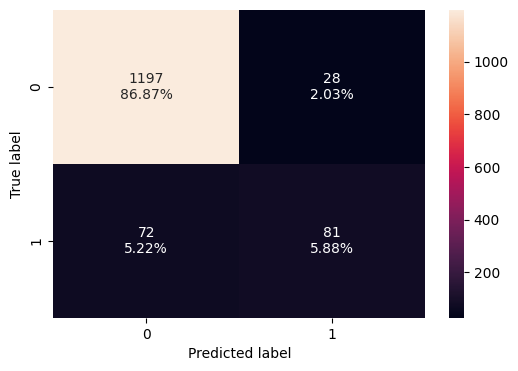

In [47]:
confusion_matrix_statsmodels(lg, X_train, y_train)

In [48]:
print("Training performance:")
model_performance_classification_statsmodels(lg, X_train, y_train)

Training performance:


,Accuracy,Recall,Precision,F1
0,0.92743,0.52941,0.74312,0.61832


> 1. This model was able to predict 81 defaults and 28 non defaults correctly.  
2. The lg model predicted that 72 companies would not default but they did.  This is very high.  
3.  We will perform multiucollenarity checks.

## Checking Multicollinearity

- In order to make statistical inferences from a logistic regression model, it is important to ensure that there is no multicollinearity present in the data.
- There are different ways of detecting (or testing for) multicollinearity. One such way is using the Variation Inflation Factor (VIF).

* **Variance  Inflation  factor**:  Variance  inflation  factors  measure  the  inflation  in  the variances of the regression coefficients estimates due to collinearities that exist among the  predictors.  It  is  a  measure  of  how  much  the  variance  of  the  estimated  regression coefficient $\beta_k$ is "inflated" by  the  existence  of  correlation  among  the  predictor variables in the model.

* **General Rule of thumb**:
  - If VIF is 1 then there is no correlation among the $k$th predictor and the remaining predictor variables, and  hence  the variance of $\beta_k$ is not inflated at all
  - If VIF exceeds 5, we say there is moderate multicollinearity
  - If VIF is equal or exceeding 10, it shows signs of high multi-collinearity

* The purpose of the analysis should dictate which threshold to use

In [49]:
vif_series = pd.Series(
    [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])],
    index=X_train.columns,
    dtype=float,
)

# Sort and print in descending order
print("Series before feature selection (sorted): \n\n{}\n".format(vif_series.sort_values(ascending=False)))


Series before feature selection (sorted): 

_Per_Share_Net_profit_before_tax_Yuan_              105.01349
_Net_profit_before_tax_to_Paid_in_capital           104.39997
_Cash_Flow_to_Total_Assets                           56.33701
_Quick_Assets_to_Current_Liability                   32.38538
_CFO_to_Assets                                       25.72637
_Operating_Funds_to_Liability                        21.84459
_Cash_Flow_to_Liability                              19.91640
_Cash_Flow_to_Equity                                 19.84787
_Cash_flow_rate                                      16.26167
_Current_Ratio                                       14.89374
_Quick_Ratio                                         13.37269
_Cash_Reinvestment_perc                              11.55496
_Total_Asset_Turnover                                11.20000
_Net_Worth_Turnover_Rate_times                       10.97967
_Interest_Coverage_Ratio_Interest_expense_to_EBIT     6.98553
_Quick_Assets_to_Total_Ass

> There are 17 variables with high VIF (above 5).  We will remove the largest VIF (_Per_Share_Net_profit_before_tax_Yuan_) first and run again.

In [50]:
X_train1 = X_train.drop("_Per_Share_Net_profit_before_tax_Yuan_", axis=1)

vif_series2 = pd.Series(
    [variance_inflation_factor(X_train1.values, i) for i in range(X_train1.shape[1])],
    index=X_train1.columns,
)
print("Series before feature selection (sorted): \n\n{}\n".format(vif_series2.sort_values(ascending=False)))


Series before feature selection (sorted): 

_Cash_Flow_to_Total_Assets                          56.23561
_Quick_Assets_to_Current_Liability                  32.30968
_CFO_to_Assets                                      25.68173
_Operating_Funds_to_Liability                       21.82686
_Cash_Flow_to_Liability                             19.91619
_Cash_Flow_to_Equity                                19.76041
_Cash_flow_rate                                     16.26114
_Current_Ratio                                      14.81552
_Quick_Ratio                                        13.37059
_Cash_Reinvestment_perc                             11.53222
_Total_Asset_Turnover                               11.17307
_Net_Worth_Turnover_Rate_times                      10.97587
_Net_profit_before_tax_to_Paid_in_capital            8.16988
_Interest_Coverage_Ratio_Interest_expense_to_EBIT    6.98072
_Quick_Assets_to_Total_Assets                        6.78662
_Equity_to_Liability                     

>  Now there are 16 variables with a VIF above 5.  We will drop the highest and run VIF again.  

In [51]:
X_train2 = X_train1.drop("_Cash_Flow_to_Total_Assets", axis=1)
vif_series3 = pd.Series(
    [variance_inflation_factor(X_train2.values, i) for i in range(X_train2.shape[1])],
    index=X_train2.columns,
)
print("Series before feature selection (sorted): \n\n{}\n".format(vif_series3.sort_values(ascending=False)))


Series before feature selection (sorted): 

_Quick_Assets_to_Current_Liability                  32.30968
_CFO_to_Assets                                      25.61221
_Operating_Funds_to_Liability                       21.68104
_Cash_flow_rate                                     16.21298
_Current_Ratio                                      14.81207
_Quick_Ratio                                        13.36982
_Cash_Reinvestment_perc                             11.36514
_Total_Asset_Turnover                               11.17198
_Net_Worth_Turnover_Rate_times                      10.97547
_Net_profit_before_tax_to_Paid_in_capital            8.16788
_Interest_Coverage_Ratio_Interest_expense_to_EBIT    6.97422
_Quick_Assets_to_Total_Assets                        6.78468
_Equity_to_Liability                                 5.70560
_Cash_Flow_to_Equity                                 5.49532
_Cash_Flow_to_Liability                              5.24686
_Total_income_to_Total_expense           

  >There are now 15 variables with  VIF higher than 5.  We will drop the largest and run the VIF again.

In [52]:
X_train3 = X_train2.drop("_Quick_Assets_to_Current_Liability", axis=1)
vif_series4 = pd.Series(
    [variance_inflation_factor(X_train3.values, i) for i in range(X_train3.shape[1])],
    index=X_train3.columns,
)
print("Series before feature selection (sorted): \n\n{}\n".format(vif_series4.sort_values(ascending=False)))


Series before feature selection (sorted): 

_CFO_to_Assets                                      25.58944
_Operating_Funds_to_Liability                       21.29943
_Cash_flow_rate                                     15.74953
_Cash_Reinvestment_perc                             11.33021
_Total_Asset_Turnover                               11.16376
_Net_Worth_Turnover_Rate_times                      10.97191
_Current_Ratio                                       9.62472
_Net_profit_before_tax_to_Paid_in_capital            8.14735
_Quick_Ratio                                         7.74325
_Interest_Coverage_Ratio_Interest_expense_to_EBIT    6.97324
_Cash_Flow_to_Equity                                 5.49286
_Quick_Assets_to_Total_Assets                        5.44065
_Cash_Flow_to_Liability                              5.24268
_Equity_to_Liability                                 5.21996
_Total_income_to_Total_expense                       5.02421
_Retained_Earnings_to_Total_Assets       

> 14 Variables will high VIF values.  Dropping the variable with the largest VIF

In [53]:
X_train4 = X_train3.drop("_CFO_to_Assets", axis=1)
vif_series5 = pd.Series(
    [variance_inflation_factor(X_train4.values, i) for i in range(X_train4.shape[1])],
    index=X_train4.columns,
)
print("Series before feature selection (sorted): \n\n{}\n".format(vif_series5.sort_values(ascending=False)))

Series before feature selection (sorted): 

_Operating_Funds_to_Liability                       18.66420
_Cash_flow_rate                                     15.42557
_Total_Asset_Turnover                               11.14577
_Net_Worth_Turnover_Rate_times                      10.93074
_Current_Ratio                                       9.62395
_Net_profit_before_tax_to_Paid_in_capital            7.85062
_Quick_Ratio                                         7.73031
_Interest_Coverage_Ratio_Interest_expense_to_EBIT    6.97188
_Cash_Flow_to_Equity                                 5.47789
_Quick_Assets_to_Total_Assets                        5.43726
_Cash_Flow_to_Liability                              5.22121
_Equity_to_Liability                                 5.20080
_Total_income_to_Total_expense                       5.02096
_Retained_Earnings_to_Total_Assets                   4.95494
_Interest_Expense_Ratio                              4.90193
_Fixed_Assets_to_Assets                  

>Dropping _Operating_Funds_to_Liability

In [54]:
X_train5 = X_train4.drop("_Operating_Funds_to_Liability", axis=1)
vif_series6 = pd.Series(
    [variance_inflation_factor(X_train5.values, i) for i in range(X_train5.shape[1])],
    index=X_train5.columns,
)
print("Series before feature selection (sorted): \n\n{}\n".format(vif_series6.sort_values(ascending=False)))

Series before feature selection (sorted): 

_Total_Asset_Turnover                               11.10122
_Net_Worth_Turnover_Rate_times                      10.91297
_Current_Ratio                                       9.42448
_Net_profit_before_tax_to_Paid_in_capital            7.82358
_Quick_Ratio                                         7.65554
_Interest_Coverage_Ratio_Interest_expense_to_EBIT    6.95583
_Cash_Flow_to_Equity                                 5.45654
_Quick_Assets_to_Total_Assets                        5.36649
_Cash_Flow_to_Liability                              5.20990
_Total_income_to_Total_expense                       4.95926
_Retained_Earnings_to_Total_Assets                   4.94518
_Interest_Expense_Ratio                              4.89743
_Equity_to_Liability                                 4.82293
_Fixed_Assets_to_Assets                              4.69267
_Operating_Profit_Growth_Rate                        3.78881
_Degree_of_Financial_Leverage_DFL        

dropping _Total_Asset_Turnover

In [55]:
X_train6 = X_train5.drop("_Total_Asset_Turnover", axis=1)
vif_series7 = pd.Series(
    [variance_inflation_factor(X_train6.values, i) for i in range(X_train6.shape[1])],
    index=X_train6.columns,
)
print("Series before feature selection (sorted): \n\n{}\n".format(vif_series7.sort_values(ascending=False)))

Series before feature selection (sorted): 

_Current_Ratio                                      9.40884
_Net_profit_before_tax_to_Paid_in_capital           7.81835
_Quick_Ratio                                        7.61756
_Interest_Coverage_Ratio_Interest_expense_to_EBIT   6.95492
_Cash_Flow_to_Equity                                5.45637
_Quick_Assets_to_Total_Assets                       5.31806
_Cash_Flow_to_Liability                             5.20658
_Total_income_to_Total_expense                      4.94462
_Interest_Expense_Ratio                             4.86968
_Retained_Earnings_to_Total_Assets                  4.79203
_Fixed_Assets_to_Assets                             4.63957
_Equity_to_Liability                                4.63549
_Operating_Profit_Growth_Rate                       3.78251
_Degree_of_Financial_Leverage_DFL                   3.68206
_Cash_Reinvestment_perc                             3.58224
_Continuous_Net_Profit_Growth_Rate                  3.51

> Dropping _Current_Ratio

In [56]:
X_train7 = X_train6.drop("_Current_Ratio", axis=1)
vif_series8 = pd.Series(
    [variance_inflation_factor(X_train7.values, i) for i in range(X_train7.shape[1])],
    index=X_train7.columns,
)
print("Series before feature selection (sorted): \n\n{}\n".format(vif_series8.sort_values(ascending=False)))

Series before feature selection (sorted): 

_Net_profit_before_tax_to_Paid_in_capital           7.81807
_Interest_Coverage_Ratio_Interest_expense_to_EBIT   6.93891
_Cash_Flow_to_Equity                                5.45434
_Cash_Flow_to_Liability                             5.20399
_Quick_Assets_to_Total_Assets                       5.20203
_Quick_Ratio                                        5.04915
_Total_income_to_Total_expense                      4.94348
_Interest_Expense_Ratio                             4.84728
_Retained_Earnings_to_Total_Assets                  4.78774
_Fixed_Assets_to_Assets                             4.63196
_Equity_to_Liability                                4.22915
_Operating_Profit_Growth_Rate                       3.78160
_Degree_of_Financial_Leverage_DFL                   3.68173
_Cash_Reinvestment_perc                             3.57713
_Continuous_Net_Profit_Growth_Rate                  3.51163
_Cash_to_Current_Liability                          3.43

> Drop _Net_profit_before_tax_to_Paid_in_capital

In [57]:
X_train8 = X_train7.drop("_Net_profit_before_tax_to_Paid_in_capital", axis=1)
vif_series9 = pd.Series(
    [variance_inflation_factor(X_train8.values, i) for i in range(X_train8.shape[1])],
    index=X_train8.columns,
)
print("Series before feature selection (sorted): \n\n{}\n".format(vif_series9.sort_values(ascending=False)))

Series before feature selection (sorted): 

_Interest_Coverage_Ratio_Interest_expense_to_EBIT   6.92293
_Cash_Flow_to_Equity                                5.43745
_Quick_Assets_to_Total_Assets                       5.19992
_Cash_Flow_to_Liability                             5.17459
_Quick_Ratio                                        5.03735
_Interest_Expense_Ratio                             4.77931
_Fixed_Assets_to_Assets                             4.62017
_Total_income_to_Total_expense                      4.15285
_Equity_to_Liability                                4.13221
_Operating_Profit_Growth_Rate                       3.77334
_Degree_of_Financial_Leverage_DFL                   3.67774
_Cash_Reinvestment_perc                             3.57651
_Continuous_Net_Profit_Growth_Rate                  3.51120
_Retained_Earnings_to_Total_Assets                  3.48512
_Cash_to_Current_Liability                          3.43041
_Net_Worth_Turnover_Rate_times                      3.40

> Drop _Interest_Coverage_Ratio_Interest_expense_to_EBIT

In [58]:
X_train9 = X_train8.drop("_Interest_Coverage_Ratio_Interest_expense_to_EBIT", axis=1)
vif_series10 = pd.Series(
    [variance_inflation_factor(X_train9.values, i) for i in range(X_train9.shape[1])],
    index=X_train9.columns,
)
print("Series before feature selection (sorted): \n\n{}\n".format(vif_series10.sort_values(ascending=False)))

Series before feature selection (sorted): 

_Cash_Flow_to_Equity                       5.43740
_Quick_Assets_to_Total_Assets              5.19035
_Cash_Flow_to_Liability                    5.17278
_Quick_Ratio                               5.03275
_Fixed_Assets_to_Assets                    4.62005
_Total_income_to_Total_expense             4.15240
_Equity_to_Liability                       4.12571
_Operating_Profit_Growth_Rate              3.75302
_Cash_Reinvestment_perc                    3.57642
_Continuous_Net_Profit_Growth_Rate         3.50883
_Retained_Earnings_to_Total_Assets         3.47537
_Cash_to_Current_Liability                 3.42982
_Net_Worth_Turnover_Rate_times             3.39384
_Cash_flow_rate                            3.33981
_Total_Asset_Return_Growth_Rate_Ratio      3.10469
_Realized_Sales_Gross_Profit_Growth_Rate   2.92717
_Operating_profit_per_person               2.91165
_Cash_to_Total_Assets                      2.88469
_Long_term_fund_suitability_ratio_A   

> Drop `_Cash_Flow_to_Equity`

In [59]:
X_train10 = X_train9.drop("_Cash_Flow_to_Equity", axis=1)
vif_series11 = pd.Series(
    [variance_inflation_factor(X_train10.values, i) for i in range(X_train10.shape[1])],
    index=X_train10.columns,
)
print("Series before feature selection (sorted): \n\n{}\n".format(vif_series11.sort_values(ascending=False)))

Series before feature selection (sorted): 

_Quick_Assets_to_Total_Assets              5.18718
_Quick_Ratio                               5.03051
_Fixed_Assets_to_Assets                    4.61788
_Total_income_to_Total_expense             4.14748
_Equity_to_Liability                       4.11170
_Operating_Profit_Growth_Rate              3.75183
_Cash_Reinvestment_perc                    3.55434
_Continuous_Net_Profit_Growth_Rate         3.50724
_Retained_Earnings_to_Total_Assets         3.47472
_Cash_to_Current_Liability                 3.40685
_Net_Worth_Turnover_Rate_times             3.38294
_Cash_flow_rate                            3.33175
_Total_Asset_Return_Growth_Rate_Ratio      3.10462
_Realized_Sales_Gross_Profit_Growth_Rate   2.92523
_Operating_profit_per_person               2.90896
_Long_term_fund_suitability_ratio_A        2.83028
_Cash_to_Total_Assets                      2.82629
_Allocation_rate_per_person                2.78573
_Net_Value_Growth_Rate                

> Drop `_Quick_Assets_to_Total_Assets`

In [60]:
X_train11 = X_train10.drop("_Quick_Assets_to_Total_Assets", axis=1)
vif_series12 = pd.Series(
    [variance_inflation_factor(X_train11.values, i) for i in range(X_train11.shape[1])],
    index=X_train11.columns,
)
print("Series before feature selection (sorted): \n\n{}\n".format(vif_series12.sort_values(ascending=False)))

Series before feature selection (sorted): 

_Fixed_Assets_to_Assets                    4.38453
_Total_income_to_Total_expense             4.12200
_Quick_Ratio                               4.05389
_Equity_to_Liability                       3.99518
_Operating_Profit_Growth_Rate              3.75129
_Cash_Reinvestment_perc                    3.55254
_Continuous_Net_Profit_Growth_Rate         3.50053
_Retained_Earnings_to_Total_Assets         3.47187
_Cash_flow_rate                            3.31711
_Cash_to_Current_Liability                 3.25282
_Total_Asset_Return_Growth_Rate_Ratio      3.10141
_Realized_Sales_Gross_Profit_Growth_Rate   2.92232
_Operating_profit_per_person               2.90472
_Long_term_fund_suitability_ratio_A        2.82981
_Allocation_rate_per_person                2.78459
_Net_Worth_Turnover_Rate_times             2.75721
_Net_Value_Growth_Rate                     2.53672
_Cash_Flow_Per_Share                       2.52424
_Interest_Expense_Ratio               

> The are no more multicollenarity.  Let us check the P-Values

In [61]:
#Running the logistic regression with the varaibles with low VIF values only
logit2 = sm.Logit(y_train, X_train11.astype(float))
lg2 = logit2.fit(disp=False)

print("Training performance:")
model_performance_classification_statsmodels(lg2, X_train11, y_train)

Training performance:


,Accuracy,Recall,Precision,F1
0,0.92598,0.53595,0.72566,0.61654


In [62]:
print(lg2.summary())

                           Logit Regression Results                           
Dep. Variable:                Default   No. Observations:                 1378
Model:                          Logit   Df Residuals:                     1335
Method:                           MLE   Df Model:                           42
Date:                Sun, 03 Aug 2025   Pseudo R-squ.:                  0.4666
Time:                        14:05:56   Log-Likelihood:                -256.28
converged:                       True   LL-Null:                       -480.46
Covariance Type:            nonrobust   LLR p-value:                 2.025e-69
                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
const                                       -4.3370      0.306    -14.174      0.000      -4.937      -3.737
_Operating_Expense_Rate                  

### Removing high p-value variables

>We will do the following repeatedly using a loop:
  - Build a model, check the p-values of the variables, and drop the column with the highest p-value.
  - Create a new model without the dropped feature, check the p-values of the variables, and drop the column with the highest p-value.
  - Repeat the above two steps till there are no columns with p-value > 0.05.


Note: The above process can also be done manually by picking one variable at a time that has a high p-value, dropping it, and building a model again. But that might be a little tedious and using a loop will be more efficient.

In [63]:
# initial list of columns
cols = X_train11.columns.tolist()

# setting an initial max p-value
max_p_value = 1

while len(cols) > 0:
    # defining the train set
    X_train_aux = X_train11[cols]

    # fitting the model
    model = sm.Logit(y_train, X_train_aux).fit(disp=False)

    # getting the p-values and the maximum p-value
    p_values = model.pvalues
    max_p_value = max(p_values)

    # name of the variable with maximum p-value
    feature_with_p_max = p_values.idxmax()

    if max_p_value > 0.05:
        cols.remove(feature_with_p_max)
    else:
        break

selected_features = cols
print(selected_features)

['const', '_Research_and_development_expense_rate', '_Interest_bearing_debt_interest_rate', '_Cash_Reinvestment_perc', '_Quick_Ratio', '_Total_debt_to_Total_net_worth', '_Accounts_Receivable_Turnover', '_Operating_profit_per_person', '_Allocation_rate_per_person', '_Retained_Earnings_to_Total_Assets', '_Total_income_to_Total_expense', '_Total_expense_to_Assets', '_Equity_to_Liability']


In [64]:
X_train12 = X_train11[selected_features]

In [65]:
logit3 = sm.Logit(y_train, X_train12.astype(float))
lg3 = logit3.fit(disp=False)

print(lg3.summary())

                           Logit Regression Results                           
Dep. Variable:                Default   No. Observations:                 1378
Model:                          Logit   Df Residuals:                     1365
Method:                           MLE   Df Model:                           12
Date:                Sun, 03 Aug 2025   Pseudo R-squ.:                  0.4363
Time:                        14:05:57   Log-Likelihood:                -270.84
converged:                       True   LL-Null:                       -480.46
Covariance Type:            nonrobust   LLR p-value:                 3.177e-82
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
const                                     -4.2619      0.273    -15.593      0.000      -4.798      -3.726
_Research_and_development_expense_rate     0.39

**Now no feature has p-value greater than 0.05, so we'll consider the features in *X_train8* as the final ones and *lg3* as final model.**

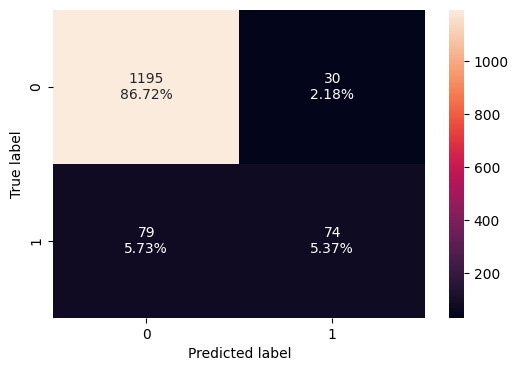

In [66]:
# creating confusion matrix
confusion_matrix_statsmodels(lg3, X_train12, y_train)

In [67]:
log_reg_model_train_perf = model_performance_classification_statsmodels(
    lg3, X_train12, y_train
)

print("Training performance:")
log_reg_model_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.92090,0.48366,0.71154,0.57588


**Test set performance**

- We have to first drop the columns from the test set that were dropped from the training set.

In [68]:
X_test2 = X_test[list(X_train12.columns)]

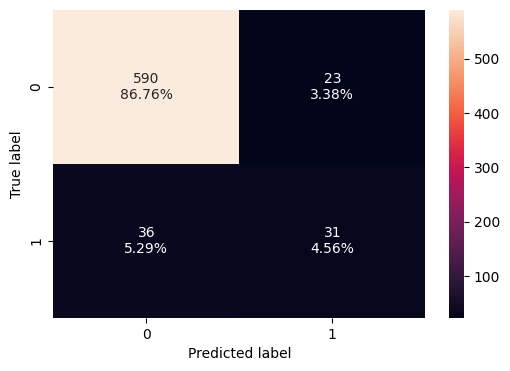

In [69]:
# creating confusion matrix
confusion_matrix_statsmodels(lg3, X_test2, y_test)

In [70]:
log_reg_model_test_perf = model_performance_classification_statsmodels(
    lg3, X_test2, y_test
)

print("Test performance:")
log_reg_model_test_perf

Test performance:


,Accuracy,Recall,Precision,F1
0,0.91324,0.46269,0.57407,0.51240


We get a recall of 0.46 on the test data and 0.48 on the train data.  This model is not performing well. The model is not overfitting. Let us use AUC-ROC curve to change the threshold.

**Observations**

> 1.  The recall of the model is ~0.46 and we will try to maximize it further.
2.  The model is predicted 36 companies would not default but they did default.
3.  The model predicted 23 companies will default but they did not.
4.  This model uses a default threshold of 50%.  Let us use the AUC-ROC curve and the Precision_Recall curve to find more optimum thresholds.

## Model Performance Improvement


* Let's see if the recall can be improved further by changing the model threshold
* First, we will check the ROC curve, compute the area under the ROC curve (ROC-AUC), and then use it to find the optimal threshold
* Next, we will check the Precision-Recall curve to find the right balance between precision and recall as our metric of choice is f1_score

### ROC Curve and ROC-AUC

* ROC-AUC on training set

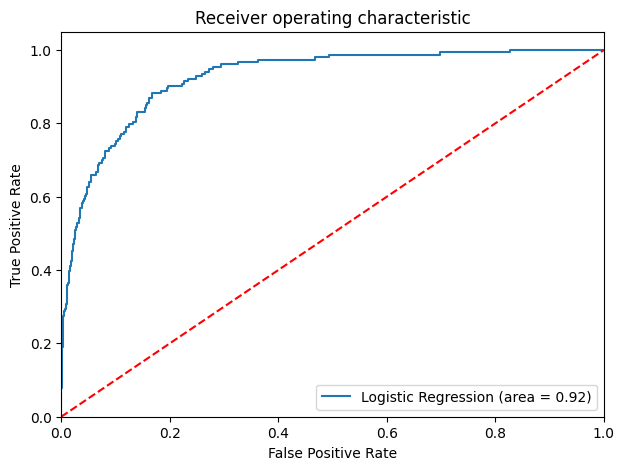

In [71]:
logit_roc_auc_train = roc_auc_score(y_train, lg3.predict(X_train12))
fpr, tpr, thresholds = roc_curve(y_train, lg3.predict(X_train12))
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_train)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

> The area under the curve is good.  

In [72]:
# Optimal threshold as per AUC-ROC curve
# The optimal cut off would be where tpr is high and fpr is low
fpr, tpr, thresholds = roc_curve(y_train, lg3.predict(X_train12))

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold_auc_roc = thresholds[optimal_idx]
print(optimal_threshold_auc_roc)

0.1074512311100577


The optimal threshold is 0.11

Let us check the model performance with this threshold

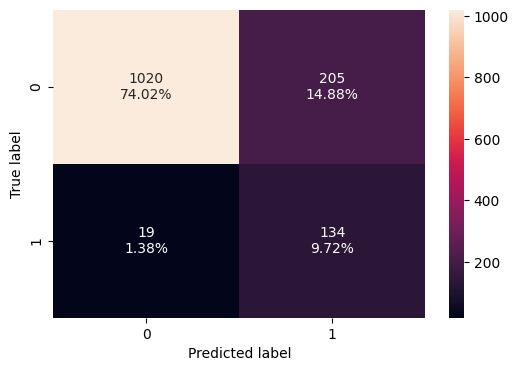

In [73]:
# creating confusion matrix
confusion_matrix_statsmodels(
    lg3, X_train12, y_train, threshold=optimal_threshold_auc_roc
)

In [74]:
# checking model performance for this model
log_reg_model_train_perf_threshold_auc_roc = model_performance_classification_statsmodels(
    lg3, X_train12, y_train, threshold=optimal_threshold_auc_roc
)
print("Training performance:")
log_reg_model_train_perf_threshold_auc_roc

Training performance:


,Accuracy,Recall,Precision,F1
0,0.83745,0.87582,0.39528,0.54472


> Recall has improved alot.  From 0.53 on trining data to 0.87.  Howerve the precisionhas decreased, from 0.71 to 0.40.

Let us continue to see if we can get a model which generalizes well of the perfomrance metrics.

**Checking model performance on test set**

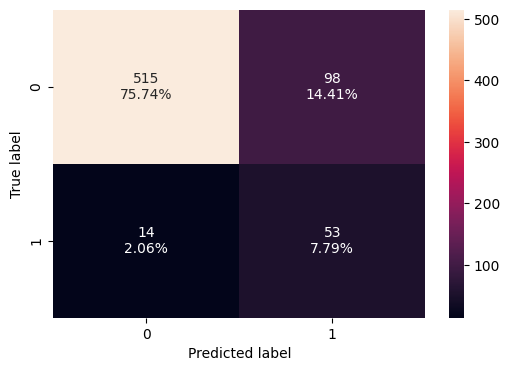

In [75]:
# creating confusion matrix
confusion_matrix_statsmodels(lg3, X_test2, y_test, threshold=optimal_threshold_auc_roc)

In [76]:
# checking model performance for this model
log_reg_model_test_perf_threshold_auc_roc = model_performance_classification_statsmodels(
    lg3, X_test2, y_test, threshold=optimal_threshold_auc_roc
)
print("Test performance:")
log_reg_model_test_perf_threshold_auc_roc

Test performance:


,Accuracy,Recall,Precision,F1
0,0.83529,0.79104,0.35099,0.48624


> 1.  Recall increased in the test set, from 0.46 to 0.79, however the precision dropped from 0.57 to 0.35.  F1 dropped slightly from 0.51 to 0.49.
2.  This model  had 14 false negatives.  I.e predicted 14 companies would not default but they did.
3.. The model predicted 98 people would default but they did not.  This is lost businedd opportunities.

Let us have a look at the precision recall curve to see if we can get better results with that treshold.

### Precision-Recall Curve

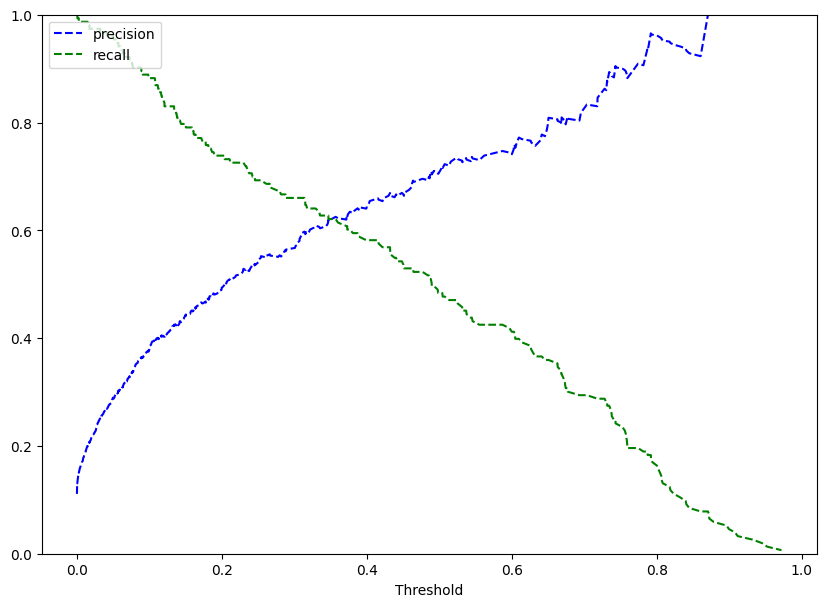

In [77]:
y_scores = lg3.predict(X_train12)
prec, rec, tre = precision_recall_curve(y_train, y_scores,)


def plot_prec_recall_vs_tresh(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="precision")
    plt.plot(thresholds, recalls[:-1], "g--", label="recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.ylim([0, 1])


plt.figure(figsize=(10, 7))
plot_prec_recall_vs_tresh(prec, rec, tre)
plt.show()

> We see that threshold is about 0.38.  This is where there is a balance between the precision and recall

In [78]:
# setting the threshold
optimal_threshold_curve = 0.38

**Checking model performance on training set**

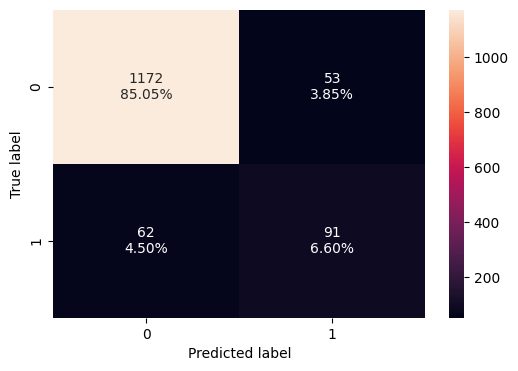

In [79]:
# creating confusion matrix
confusion_matrix_statsmodels(lg3, X_train12, y_train, threshold=optimal_threshold_curve)

In [80]:
log_reg_model_train_perf_threshold_curve = model_performance_classification_statsmodels(
    lg3, X_train12, y_train, threshold=optimal_threshold_curve
)
print("Training performance:")
log_reg_model_train_perf_threshold_curve

Training performance:


,Accuracy,Recall,Precision,F1
0,0.91655,0.59477,0.63194,0.61279


> 1.  The recall dropped from 0.88 to 0.59, however the precision increased from 0.40 to 0.63.
2.  Both the AUC-ROC and the Precision Recall are giving better recall values on the training set than the default threshold of 0.5.
3.  Using Precision Recall 62 companies was predicted to not default but they did.  The was 19 for the AUC-ROC threshold.
4.  Let us check the perfomrance on the test set.

**Checking model performance on test set**

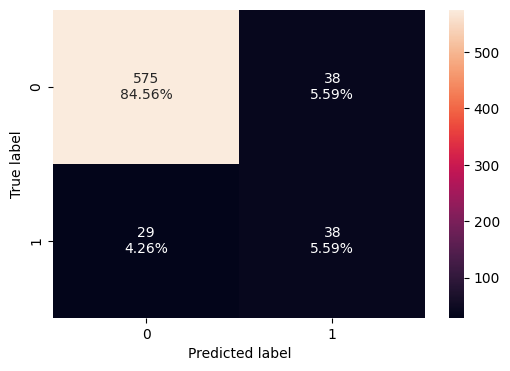

In [81]:
# creating confusion matrix
confusion_matrix_statsmodels(lg3, X_test2, y_test, threshold=optimal_threshold_curve)

In [82]:
log_reg_model_test_perf_threshold_curve = model_performance_classification_statsmodels(
    lg3, X_test2, y_test, threshold=optimal_threshold_curve
)
print("Test performance:")
log_reg_model_test_perf_threshold_curve

Test performance:


,Accuracy,Recall,Precision,F1
0,0.90147,0.56716,0.50000,0.53147


> The performance on Recall decreased but increased on Precision.  This model is not overfitting.  Let us try Random Forest Modelling

## Model Performance Comparison and Final Model Selection

In [83]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        log_reg_model_train_perf.T,
        log_reg_model_train_perf_threshold_auc_roc.T,
        log_reg_model_train_perf_threshold_curve.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic Regression-default Threshold (0.5)",
    "Logistic Regression-0.11 Threshold",
    "Logistic Regression-0.38 Threshold",
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Logistic Regression-default Threshold (0.5),Logistic Regression-0.11 Threshold,Logistic Regression-0.38 Threshold
Accuracy,0.92090,0.83745,0.91655
Recall,0.48366,0.87582,0.59477
Precision,0.71154,0.39528,0.63194
F1,0.57588,0.54472,0.61279


In [84]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
        log_reg_model_test_perf.T,
        log_reg_model_test_perf_threshold_auc_roc.T,
        log_reg_model_test_perf_threshold_curve.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Logistic Regression-default Threshold (0.5)",
    "Logistic Regression-0.11 Threshold",
    "Logistic Regression-0.38 Threshold",
]

print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Logistic Regression-default Threshold (0.5),Logistic Regression-0.11 Threshold,Logistic Regression-0.38 Threshold
Accuracy,0.91324,0.83529,0.90147
Recall,0.46269,0.79104,0.56716
Precision,0.57407,0.35099,0.50000
F1,0.51240,0.48624,0.53147


>  From the Logistic Regression we see that:
1.  The AUC-ROC threshold is giving the best performing threshold on the recall and is not overfitting.  However this not perfomriong well on the precision.
2.  The AUC-ROC is also giving the least false negatives (14).

**Final Model Summary**

* We have been able to build a predictive model that can be used by the investors to predict company default with a recall score of 0.79 on the test set.

* The following coefficients if increased will increase the chances of a company defaults
> `_Research_and_development_expense_rate`, `_Interest_bearing_debt_interest_rate`, `_Total_debt_to_Total_net_worth`, `_Operating_profit_per_person`, `_Allocation_rate_per_person`, `_Total_expense_to_Assets`



* The following coefficients if increased will decrease the chances of company default
> `_Cash_Reinvestment_perc`, `_Quick_Ratio`, `_Accounts_Receivable_Turnover`, `_Retained_Earnings_to_Total_Assets`, `_Total_income_to_Total_expense`, `_Equity_to_Liability`

## Building a Random Forest model

> We established above that we are interested in reducing both false negatives.
 We are interested in the model which gives us the largest Recall score, while still performing well onthe other metrics.


In [85]:
# specifying the independent  and dependent variables
X = df_scaled.drop(["Default"], axis=1)
Y = df_scaled["Default"]

# adding a constant to the independent variables
X = sm.add_constant(X, has_constant='add')

# creating dummy variables
#X = pd.get_dummies(X, drop_first=True)

# splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.33, random_state=42
)

In [86]:
param_grid = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}

rfcl = RandomForestClassifier()

grid_search = GridSearchCV(estimator = rfcl, param_grid = param_grid)

In [87]:
grid_search.fit(X_train, y_train)

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'max_features': [array([0.3, 0.4, 0.5]), 'sqrt'],
                         'max_samples': array([0.4, 0.5, 0.6]),
                         'min_samples_leaf': array([1, 2, 3]),
                         'n_estimators': [50, 110, 25]})

In [88]:
grid_search.best_params_

{'max_features': 'sqrt',
 'max_samples': np.float64(0.5),
 'min_samples_leaf': np.int64(2),
 'n_estimators': 110}

In [89]:
best_grid = grid_search.best_estimator_

In [90]:
pred_train_rf = best_grid.predict(X_train)
pred_test_rf = best_grid.predict(X_test)

In [91]:
from sklearn import metrics
print(metrics.classification_report(y_train, pred_train_rf))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1225
           1       0.98      0.67      0.80       153

    accuracy                           0.96      1378
   macro avg       0.97      0.84      0.89      1378
weighted avg       0.96      0.96      0.96      1378



In [92]:
from sklearn import metrics
print(metrics.classification_report(y_test, pred_test_rf))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95       613
           1       0.60      0.40      0.48        67

    accuracy                           0.91       680
   macro avg       0.77      0.69      0.72       680
weighted avg       0.90      0.91      0.91       680



## Hypertuned Random Forest Grid Search with class weights

In [93]:
param_grid = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}

rfcl_weighted = RandomForestClassifier(class_weight={0:0.67,1:0.33},random_state=1,oob_score=True,bootstrap=True)

grid_search_weighted = GridSearchCV(estimator = rfcl_weighted, param_grid = param_grid)

In [94]:
grid_search_weighted.fit(X_train, y_train)

GridSearchCV(estimator=RandomForestClassifier(class_weight={0: 0.67, 1: 0.33},
                                              oob_score=True, random_state=1),
             param_grid={'max_features': [array([0.3, 0.4, 0.5]), 'sqrt'],
                         'max_samples': array([0.4, 0.5, 0.6]),
                         'min_samples_leaf': array([1, 2, 3]),
                         'n_estimators': [50, 110, 25]})

In [95]:
grid_search_weighted.best_params_

{'max_features': 'sqrt',
 'max_samples': np.float64(0.4),
 'min_samples_leaf': np.int64(1),
 'n_estimators': 110}

In [96]:
best_grid = grid_search_weighted.best_estimator_

In [97]:
pred_train_rf = best_grid.predict(X_train)
pred_test_rf = best_grid.predict(X_test)

In [98]:
print(metrics.classification_report(y_train, pred_train_rf))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1225
           1       0.99      0.67      0.80       153

    accuracy                           0.96      1378
   macro avg       0.98      0.84      0.89      1378
weighted avg       0.96      0.96      0.96      1378



In [99]:
print(metrics.classification_report(y_test, pred_test_rf))

              precision    recall  f1-score   support

           0       0.94      0.97      0.96       613
           1       0.63      0.40      0.49        67

    accuracy                           0.92       680
   macro avg       0.78      0.69      0.72       680
weighted avg       0.91      0.92      0.91       680



> 1.  From the Random Forest Classifier we performed a hyper parameter.  The best parameters was max_features': 'sqrt, max_samples': 0.4,
 'min_samples_leaf': 3,and 'n_estimators': 25.
2.  We found that in the training data the model had a high recall and precision score in predicting those who did not  defaulted.  However this was not the case for those who defaulted.  We got better results with the logistic regression.
3.  The test data is not performing as good as the logistic regression.
4.  We then built a random forest classifier using class weights.  This was to balance the 0's and 1's in the data before modelling.  We found that the predition of defaulters in the test set slightly improved, but was now overfitting


## Building a Linear Discriminant Analysis

In [100]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

In [101]:
LDA = LinearDiscriminantAnalysis()

In [102]:
lda_model = LDA.fit(X_train, y_train)

In [103]:
pred_train_lda = lda_model.predict(X_train)
pred_test_lda = lda_model.predict(X_test)

In [104]:
print(metrics.classification_report(y_train, pred_train_lda))

              precision    recall  f1-score   support

           0       0.95      0.96      0.95      1225
           1       0.63      0.58      0.60       153

    accuracy                           0.92      1378
   macro avg       0.79      0.77      0.78      1378
weighted avg       0.91      0.92      0.91      1378



In [105]:
print(metrics.classification_report(y_test, pred_test_lda))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95       613
           1       0.54      0.61      0.57        67

    accuracy                           0.91       680
   macro avg       0.75      0.78      0.76       680
weighted avg       0.92      0.91      0.91       680



In [106]:
pred_train_lda_prob = lda_model.predict_proba(X_train)[:,1]
pred_test_lda_prob = lda_model.predict_proba(X_test)[:,1]

In [107]:
fpr, tpr, thresholds = roc_curve(y_train,pred_train_lda_prob)

In [108]:
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
optimal_threshold

np.float64(0.03834943232366125)

In [109]:
y_class_pred=[]
for i in range(0,len(pred_train_lda_prob)):
    if np.array(pred_train_lda_prob)[i]>0.28:
        a=1
    else:
        a=0
    y_class_pred.append(a)

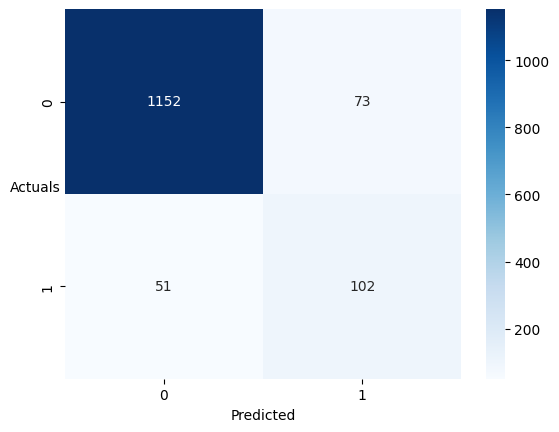

In [110]:
sns.heatmap((metrics.confusion_matrix(y_train,y_class_pred)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [111]:
print(metrics.classification_report(y_train, y_class_pred,digits=3))

              precision    recall  f1-score   support

           0      0.958     0.940     0.949      1225
           1      0.583     0.667     0.622       153

    accuracy                          0.910      1378
   macro avg      0.770     0.804     0.785      1378
weighted avg      0.916     0.910     0.913      1378



In [112]:
y_class_pred=[]
for i in range(0,len(pred_test_lda_prob)):
    if np.array(pred_test_lda_prob)[i]>0.28:
        a=1
    else:
        a=0
    y_class_pred.append(a)

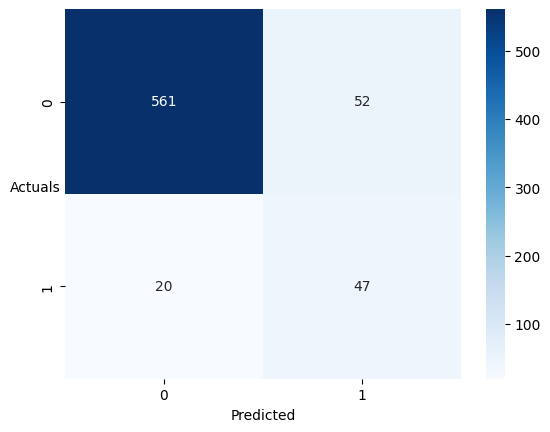

In [113]:
sns.heatmap((metrics.confusion_matrix(y_test, y_class_pred)),annot=True,fmt='.5g'
            ,cmap='Blues');
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [114]:
print(metrics.classification_report(y_test, y_class_pred,digits=3))

              precision    recall  f1-score   support

           0      0.966     0.915     0.940       613
           1      0.475     0.701     0.566        67

    accuracy                          0.894       680
   macro avg      0.720     0.808     0.753       680
weighted avg      0.917     0.894     0.903       680



> 1.  For the Linear Discriminant analysis, we see that the model performs well on the training and test data.  In predicting the non defaulters, we got a 0.915 on recall and 0.966 on precision.  This means that the model is good at reducing the false negatives and false positives.
2.  This model has a 0.70 in predicitng defaulters which is good.
2.  The model also have a high high accuracy score.  
3.  This model is performing similarly in the training data and is not over fitting.

# Comapring the model performances

### Logistic Regression
> In this analysis we built 3 logistic regression models:
>1.  **0.5 Threshold** - this was the default threshold.  We found that the model did not perform well on the recall and precision.  The model was overfitting on the precision.  We got Recall: 0.46 on the test data.
2.  ** 0.11 Threshold** - By using the AUC-ROC curve we were able to get an optimal threshold of 0.11.  The Recall: 0.79104 on test data was an improvement on the training data and an improvement on the 0.5 threshold.
3.  **0.38 Threshold** - By using Precision-Recall curve we were able to get a optimal threshold of 0.38 which balance the number of false negatives and false positives.  The Recall perfomrnace dropped compared to the ROC curve, however the precision performance increased.  

Summary for Logistic Regression:  As we are interested in minimizing the number of companies who defaulted, For the logistic Regression the ROC curve is performing best.


### Random Forest
In this analysis we built 2 models
>1.  **Hyperparameter tuning with Grid Search CV** - In building the Random Forest we did hyperparameter grid search for the  best parameters.  We foud that the best parameters were: max_features': 'sqrt, max_samples': 0.4, 'min_samples_leaf': 3,and 'n_estimators': 25.  The model performed well in predicitng the non defaulters, but was over fitting when predicting the defaultes.  The model however, was over fitting when predicitng the defaulters.  
2.  **Hyperparameter tuning with Grid Search CV using class weights and OOB** - In this model we used class weights to address class imbalance.  The model performed well on the non defaulters.  The prediction on defaulters improved slightly but was overfitting.

Summary for the Random Forest:  Comparing both models the Hypertuned GridSearch CV performed better.  Althought this model is generalizing well for predicitng the non defaulters, we are more interested in a high performing model in predicitng those who defaulted, as this is a mojor loos for investors.
 At this stage, the Logistic Regression ROC is the best performing model.


 ### Linear Discriminant Analysis
 In this analysis we built 1 model
 >  The Linear Discriminant Analysis model has a Recall: 0.701 in test data.  Although this is good, the Logistic regression ROC is giving better performance metrics.


 In Final, the best performing model for predicting company defaults when trying to minimize the false negative predictions is the Logistic Regression model ROC model.  This model uses a threshold of 0.11.

# Insights and Recommendations

##**Summary of the Problem**

We were tasked with developing a predictive model to assist investors in identifying companies that are at risk of defaulting on their loans. A default can significantly damage a company’s credit rating, making it more difficult and costly to access future financing. It can also lead to higher interest rates on both existing and new obligations. For investors, it is crucial to invest in companies that are financially stable, capable of meeting their obligations, and positioned for sustainable growth.

To support this analysis, we used financial data sourced from the companies’ balance sheets for the prior year. A balance sheet provides a snapshot of a company's financial position and is a key indicator of financial health. This data serves as the foundation for assessing creditworthiness and informing investment decisions.

##**Summary of the Approach used**

The following steps were taken to prepare, analyze, and model the dataset to predict company loan defaults:

1. **Initial Data Sanity Checks:**
   We began with basic exploratory steps, including inspecting the shape of the data, identifying missing values, checking for outliers, and using `.describe()` and `.info()` to understand the structure and basic statistics of the dataset.

2. **Outlier Treatment:**
   Outliers were identified using the interquartile range (IQR) method, and values were capped at upper and lower bounds to mitigate their impact on model performance. These steps were performed after separating the predictors (X) and target variable (y).

3. **Missing Value Imputation:**
   A **K-Nearest Neighbors (KNN) imputer** was applied to handle missing values in the predictor variables, ensuring that imputation was based on similar patterns across the dataset.  These steps were performed after separating the predictors (X) and target variable (y).

4. **Feature Scaling:**
   To normalize the range of the predictors, a **StandardScaler** was applied. Scaling was performed after imputation and only on the feature set (X).

5. **Univariate Analysis:**
   Each variable was analyzed individually to understand its distribution, detect skewness, and observe the presence of any anomalies or patterns.

6. **Bivariate Analysis:**
   We explored relationships between the predictors and the target variable (Default) to identify potential predictors of default.

7. **Train-Test Split:**
   The dataset was split into training and testing sets in a 67:33 ratio, with `random_state=42` used for reproducibility.

8. **Logistic Regression Modeling:**
   A logistic regression model was built using the training data. We iteratively removed features with high **Variance Inflation Factor (VIF > 5)** to reduce multicollinearity, and excluded variables with high **p-values** to improve statistical significance.
   Model performance was evaluated on both training and test data. Optimal classification thresholds were determined using **ROC-AUC** (optimal threshold: **0.11**) and **Precision-Recall curve** (optimal threshold: **0.38**).

9. **Random Forest Modeling:**
   Two Random Forest models were developed:

   * One using hyperparameter tuning via **GridSearchCV**
   * Another using **GridSearchCV** with class balancing (`class_weight={0:0.67, 1:0.33}`), along with `oob_score=True` and `bootstrap=True`, to better handle imbalanced classes and assess model performance using out-of-bag error estimates.

10. **Linear Discriminant Analysis (LDA):**
  As a final model, LDA was applied to examine its classification performance under the assumption of normally distributed features and equal class covariances.

## **Insights**

1.  **From Sanity Checks and EDA**

  * Skewed Distributions and Outliers: Several financial variables are heavily skewed (e.g., Operating Expense Rate), which may be due to incorrectly entered or calculated data.  It appears that there were different currencies in the data set and in cases where the variable was a rate or ratio the calculation was not done.
  * Higher R&D, Fixed Asstet Turnover and Collection Delays: Defaulting companies tended to spend more on R&D (Research_and_development_expense_rate), used their fixed assets for a longer time and took longer to collect receivables (Average_Collection_Days). While R&D investment can support long-term growth, excessive spending without profitability signals risk. Long collection periods hurt cash flow and taking longer to replace fixed assets indicates financial problems to buy new assets and can lead to health and safety issues.

  *  Lower Profitability and Liquidity: Key indicators like Cash Flow Rate, Quick Ratio, and Operating Profit Per Person were lower in defaulting companies. These suggest a reduced ability to cover short-term obligations and generate profit, which are red flags for investors evaluating financial health.

Business Implication: Investors should pay particular attention to operational efficiency, liquidity, and profit margins. Companies with weak metrics in these areas carry a higher risk of default and are less likely to sustain growth or attract future credit.
2.  **From Models**
  * Logistic Regression yielded the best performance, offering high recall while remaining interpretable and flexible through threshold tuning.

  * Random Forest helped uncover important variables but was more prone to overfitting, especially without proper class weighting.

  * LDA provided a stable and balanced alternative, with strong performance and low variance, especially useful in cleaner datasets.

  * At the end we chose the Random Forest Model with AUC-ROC.

  ## **Recommendations**
Companies that defaulted showed:
  * Higher than average in: `_Research_and_development_expense_rate`, `_Average_Collection_Days`, `_Fixed_Assets_Turnover_Frequency` `_Long_term_Liability_to_Current_Assets`, `_Current_Asset_Turnover_Rate`
  * Lower than average in: `_Cash_flow_rate`,  `_Per_Share_Net_profit_before_tax_Yuan_`,`_Realized_Sales_Gross_Profit_Growth_Rate`, `_Operating_profit_per_person` etc.


Investors can incorporate the following to reduce risk when investing in companies:
**Incorporate key risk indicators**
Use the above variables as part of a scoring system or risk filter when evaluating potential investments.

**Portfolio construction using model outputs**
Investors can build and adjust portfolios based on the likelihood of default, prioritizing companies that demonstrate strong financial efficiency and conservative spending behaviors.

**Establish data cleaning protocols**
Ensure robust handling of missing values and outliers. Collaborate with financial experts to determine whether missing values reflect reporting issues or strategic withholding.

**Implement monitoring dashboards**
Create automated dashboards that visualize and flag risk indicators in real-time, enabling quick reactions to financial red flags in portfolio companies.

**Regularly retrain and update models**
Financial dynamics change frequently. It’s essential to refresh models with new data periodically to maintain predictive performance and adjust for evolving market behavior.

**Validate assumptions with domain experts**
Work closely with financial analysts and credit risk professionals to interpret model outputs in context and avoid misclassification due to industry-specific nuances.  Also work with them to perform correct transformations to outliers and missing data.

